# importing the required packages

In [2]:
#modules import 

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import Subset, DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torchvision.datasets import ImageFolder

import timm 
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

from PIL import Image
import numpy as np
import cv2
import json
import os
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

from enum import Enum
import shutil

import warnings
warnings.filterwarnings('ignore')

import random

2026-05-20 14:24:58.916536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779287099.123709      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779287099.182092      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# banana dataset processing: merging and spliting

In [3]:
#banana

# Source datasets
src_dirs = [
    "/kaggle/input/banana-disease-recognition-dataset/Banana Disease Recognition Dataset/Augmented images/Augmented images"
]

# Destination directories

train_dir = "/kaggle/working/plant_fusion/train_data"
valid_dir = "/kaggle/working/plant_fusion/valid_data"
test_dir  = "/kaggle/working/plant_fusion/test_data"

if os.path.exists(train_dir):
    shutil.rmtree(train_dir)  
    print(f"Dossier supprimé : {train_dir}")
else:
    print(f"Dossier introuvable : {train_dir}")
    
if os.path.exists(valid_dir):
    shutil.rmtree(valid_dir)  
    print(f"Dossier supprimé : {valid_dir}")
else:
    print(f"Dossier introuvable : {valid_dir}")
    
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)  
    print(f"Dossier supprimé : {test_dir}")
else:
    print(f"Dossier introuvable : {test_dir}")

# Split ratios
train_ratio = 0.7
valid_ratio = 0.2
test_ratio  = 0.1


def make_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

for d in [train_dir, valid_dir, test_dir]:
    make_dir(d)

for src in src_dirs:
    classes = [c for c in os.listdir(src) if os.path.isdir(os.path.join(src, c))]
    
    for cls in classes:
        cls_path = os.path.join(src, cls)
        images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
        random.shuffle(images)
        
        n = len(images)
        n_train = int(n * train_ratio)
        n_valid = int(n * valid_ratio)
        n_test  = n - n_train - n_valid
        
        train_cls_dir = os.path.join(train_dir, cls)
        valid_cls_dir = os.path.join(valid_dir, cls)
        test_cls_dir  = os.path.join(test_dir, cls)
        
        make_dir(train_cls_dir)
        make_dir(valid_cls_dir)
        make_dir(test_cls_dir)
        
        for i, img in enumerate(images):
            src_img_path = os.path.join(cls_path, img)
            
            if i < n_train:
                dst_path = os.path.join(train_cls_dir, img)
            elif i < n_train + n_valid:
                dst_path = os.path.join(valid_cls_dir, img)
            else:
                dst_path = os.path.join(test_cls_dir, img)
                
            shutil.copy(src_img_path, dst_path)

print("End for banana dataset !")

Dossier introuvable : /kaggle/working/plant_fusion/train_data
Dossier introuvable : /kaggle/working/plant_fusion/valid_data
Dossier introuvable : /kaggle/working/plant_fusion/test_data
End for banana dataset !


# New plant diseases dataset processing : merging and splitting

In [4]:
# New Plant

train_dir = "/kaggle/working/plant_fusion/train_data"
valid_dir = "/kaggle/working/plant_fusion/valid_data"
test_dir  = "/kaggle/working/plant_fusion/test_data"

# Dossier source (train déjà existant)
src_train_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

# Nouveaux dossiers destination
new_train_dir = "/kaggle/working/plant_fusion/train_data"
test_dir      = "/kaggle/working/plant_fusion/test_data"

# Pourcentage à prélever pour test
test_ratio = 0.1

# Crée les dossiers de destination
os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in os.listdir(src_train_dir):
    cls_src_dir = os.path.join(src_train_dir, cls)
    if not os.path.isdir(cls_src_dir):
        continue

    cls_train_dir = os.path.join(new_train_dir, cls)
    cls_test_dir = os.path.join(test_dir, cls)

    os.makedirs(cls_train_dir, exist_ok=True)
    os.makedirs(cls_test_dir, exist_ok=True)
   
    images = [f for f in os.listdir(cls_src_dir) if os.path.isfile(os.path.join(cls_src_dir, f))]
    random.shuffle(images)

    n = len(images)
    n_test = max(1, int(n * test_ratio))

    # Split
    test_images = images[:n_test]
    train_images = images[n_test:]

    # Copier les test
    for img in test_images:
        shutil.copy2(os.path.join(cls_src_dir, img), os.path.join(cls_test_dir, img))

    # Copier les train
    for img in train_images:
        shutil.copy2(os.path.join(cls_src_dir, img), os.path.join(cls_train_dir, img))

print("✅ Split terminé : 90% dans train_data et 10% dans test_data.")

src_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
dst_dir = "/kaggle/working/plant_fusion/valid_data"

# Crée le dossier de destination s'il n'existe pas
os.makedirs(dst_dir, exist_ok=True)
# Copier tous les fichiers du dossier source vers le dossier destination
for item in os.listdir(src_dir):
    src_path = os.path.join(src_dir, item)
    dst_path = os.path.join(dst_dir, item)
    
    if os.path.isdir(src_path):
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)

print("✅ Données de validation copiées !")


✅ Split terminé : 90% dans train_data et 10% dans test_data.
✅ Données de validation copiées !


# some general parameters

In [5]:
# =======================PARAMÈTRES GÉNÉRAUX==============================
BATCH_SIZE = 32

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 50
IMG_SIZE = 224
LR = 3e-5
NUM_SAMPLES = 500  # nombre d'images pour visualisation
DATA_PATH = "/kaggle/working/plant_fusion"

# =====================================================
# TRANSFORMATIONS
# =====================================================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =====================================================
# DATASET / DATALOADERS
# =====================================================

train_path = f"{DATA_PATH}/train_data"
valid_path = f"{DATA_PATH}/valid_data"
test_path = f"{DATA_PATH}/test_data"

print(train_path)
print(valid_path)
print(test_path)

train_dataset = ImageFolder(f"{train_path}", transform=train_transform)
val_dataset = ImageFolder(f"{valid_path}", transform=val_transform)
test_dataset = ImageFolder(f"{test_path}", transform=val_transform)

print("Train Classes:", train_dataset.classes)
print("Val Classes:", val_dataset.classes)
print("Test Classes:", test_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_classes =  test_dataset.classes
print(f"{len(test_classes)} classes pour les tests")
valid_classes = val_dataset.classes
print(f"{len(valid_classes)} classes pour la validation")
train_classes = train_dataset.classes
print(f"{len(train_classes)} classes pour l'entrainement")

count = 0
for root, dirs, files in os.walk(train_path):
    count += len(files)

print(f"Nombre total de fichiers pour train: {count}")

count = 0
for root, dirs, files in os.walk(valid_path):
    count += len(files)

print(f"Nombre total de fichiers pour validation: {count}")

count = 0
for root, dirs, files in os.walk(test_path):
    count += len(files)

print(f"Nombre total de fichiers pour test: {count}")

NUM_CLASSES = len(train_classes)

/kaggle/working/plant_fusion/train_data
/kaggle/working/plant_fusion/valid_data
/kaggle/working/plant_fusion/test_data
Train Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Augmented Banana Black Sigatoka Disease', 'Augmented Banana Bract Mosaic Virus Disease', 'Augmented Banana Healthy Leaf', 'Augmented Banana Insect Pest Disease', 'Augmented Banana Moko Disease', 'Augmented Banana Panama Disease', 'Augmented Banana Yellow Sigatoka Disease', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Peppe

# Train and Test methods 

In [6]:
# Train and Test methods 

mixup_fn = Mixup(
    mixup_alpha=0.2,
    cutmix_alpha=1.0,
    prob=1.0,
    switch_prob=0.5,
    mode='batch',
    label_smoothing=0.1,
    num_classes=NUM_CLASSES
)

def train_model_2(model, train_loader, val_loader, num_epochs=50, lr=3e-5, device="cuda",
                patience=15, smoothing=0.1, use_mixup=True, weight_decay=1e-3):
  
    model.to(device)

    # === Criterion ===
    use_soft_labels = smoothing > 0.0 or use_mixup

    if use_soft_labels:
        criterion = SoftTargetCrossEntropy()
    else:
        criterion = nn.CrossEntropyLoss()


    # === Optimizer & Scheduler ===
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # === Mixed Precision ===
    scaler = GradScaler()

    # Tracking
    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    best_val_acc = 0.0
    best_model_path = "best_model.pth"
    patience_counter = 0

    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            labels_int = labels.clone()
            optimizer.zero_grad()

            with autocast():  # Mixed precision
                outputs = model(images)

                if isinstance(criterion, nn.CrossEntropyLoss):
                    loss = criterion(outputs, labels)
                else:
                    if labels.dim() == 1:
        
                        labels = torch.nn.functional.one_hot(labels, num_classes=outputs.size(1)).float()
                    loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_int).sum().item()
            total += labels_int.size(0)

        train_losses.append(running_loss / total)
        train_acc.append(correct / total)

        # Scheduler step à la fin de chaque epoch
        scheduler.step()

        # --- VALIDATION ---
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                labels_int = labels.clone()

                if use_mixup:
                    images, labels = mixup_fn(images, labels)

                with autocast():
                    outputs = model(images)

                    if isinstance(criterion, nn.CrossEntropyLoss):
                        loss = criterion(outputs, labels)
                    else:
                        if labels.dim() == 1:
                            labels = torch.nn.functional.one_hot(labels, num_classes=outputs.size(1)).float()
                        loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels_int).sum().item()
                total += labels_int.size(0)

        val_losses.append(running_loss / total)
        val_acc.append(correct / total)

        # --- LOGGING ---
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"LR: {current_lr:.2e} | "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc[-1]*100:.2f}% "
              f"| Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc[-1]*100:.2f}%")

        # --- Save best model ---
        if val_acc[-1] > best_val_acc:
            best_val_acc = val_acc[-1]
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Nouveau meilleur modèle sauvegardé avec Val Acc: {best_val_acc*100:.2f}%")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("⏹️ Early stopping déclenché")
                break

    # --- Courbes ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title("Courbes de Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.title("Courbes d'Accuracy")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
    plt.show()

    # Charger le meilleur modèle avant de le retourner
    model.load_state_dict(torch.load(best_model_path))
    return model

def test_model_2(model, test_loader, class_names, device="cuda", show_misclassified=True, max_images=12):

    model.to(device)
    model.eval()

    all_preds, all_labels = [], []
    misclassified_images, misclassified_true, misclassified_pred = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Top-1
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-5
            top5_probs, top5_preds = torch.topk(outputs, 5, dim=1)

            # Collecter les erreurs
            for i in range(len(labels)):
                if predicted[i] != labels[i]:
                    if len(misclassified_images) < max_images:
                        misclassified_images.append(images[i].cpu())
                        misclassified_true.append(labels[i].item())
                        misclassified_pred.append(predicted[i].item())

    # Rapport de classification
    print(classification_report(all_labels, all_preds, target_names=class_names))
    #from collections import Counter
    #print(Counter(all_labels))

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="viridis", xticks_rotation=90)
    plt.title("Matrice de Confusion")
    plt.show()

    """ 
    # Exemples mal classés
    if show_misclassified and len(misclassified_images) > 0:
        plt.figure(figsize=(15, 8))
        for i in range(len(misclassified_images)):
            plt.subplot(3, 4, i+1)
            img = misclassified_images[i].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min())  # normalisation visuelle
            plt.imshow(img)
            plt.title(f"Vrai: {class_names[misclassified_true[i]]}\nPrévu: {class_names[misclassified_pred[i]]}",
                      fontsize=9, color="red")
            plt.axis("off")
        plt.tight_layout()
        plt.show()
    """

# AgriViTNet Prototype

In [7]:
#Code PyTorch : AgriViTNet (prototype) 

# ======================================================
# Stage 1 : CNN léger 
# ======================================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            #nn.ReLU6(inplace=True)   # ReLU6 = standard sur mobiles
            nn.SiLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


# ======================================================
# Stage 2 : Attention block 
# ======================================================
class LiteTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=2, patch_size=8):
        super().__init__()
        self.patch_size = patch_size
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim*2),
            nn.GELU(),
            nn.Linear(dim*2, dim)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # 1. Patchification en séquences
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, C, -1, self.patch_size*self.patch_size)
        patches = patches.permute(0,2,3,1).contiguous().view(B, -1, C)  # (B, N_patches, C)

        # 2. Attention
        patches = self.norm(patches)
        attn_out, _ = self.attn(patches, patches, patches)
        patches = patches + attn_out
        patches = patches + self.ffn(patches)

        # 3. Reprojection simple
        patches = patches.view(B, -1, C).permute(0,2,1)  # (B,C,N)
        x_out = F.interpolate(patches.unsqueeze(-1), size=(H,W), mode="bilinear", align_corners=False)
        return x_out


# ======================================================
# Stage 3 : CBAM (Channel + Spatial Attention)
# ======================================================
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        # Attention par canaux
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.GELU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        # Attention spatiale
        self.spatial_att = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Attention par canaux
        ca = self.channel_att(x)
        x = x * ca
        # Attention spatiale
        sa = torch.cat([torch.max(x,1,keepdim=True)[0], torch.mean(x,1,keepdim=True)], dim=1)
        sa = self.spatial_att(sa)
        x = x * sa
        return x


# ======================================================
# Stage 4 : AgriViTNet (combinaison des blocs)
# ======================================================
class AgriViTNet(nn.Module):
    def __init__(self, num_classes=58):
        super().__init__()
        # Stage 1 : CNN léger
        self.stage1 = nn.Sequential(
            ConvBlock(3, 64, stride=2),     # (B,64,H/2,W/2)
            ConvBlock(64, 128, stride=2),   # (B,128,H/4,W/4)
            ConvBlock(128, 256, stride=1)   # (B,256,H/4,W/4)
            #CBAM(256)
        )

        # Stage 2 : Transformer léger
        self.stage2 = LiteTransformerBlock(dim=256, num_heads=4, patch_size=16)

        # Stage 3 : Fusion + CBAM
        self.stage3 = nn.Sequential(
            ConvBlock(256, 256, stride=2),  # (B,256,H/8,W/8)
            CBAM(256)
        )

        # Stage 4 : Classifier (MLP 2 couches)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),   # expansion
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),   # compression
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)  # sortie finale
        )

    def forward(self, x):
        # Stage 1
        x = self.stage1(x)       # (B,256,H/4,W/4)

        # Stage 2
        x = self.stage2(x)       # (B,256,H/4,W/4)

        # Stage 3
        x = self.stage3(x)       # (B,256,H/8,W/8)

        # Stage 4
        x = self.global_pool(x)  # (B,256,1,1)
        x = torch.flatten(x, 1)  # (B,256)
        out = self.classifier(x) # (B,num_classes)
        return out
        
# ======================================================
# Main (test du modèle)
# ======================================================
if __name__ == "__main__":
    model = AgriViTNet(num_classes=NUM_CLASSES)
    dummy_input = torch.randn(1, 3, 224, 224)  
    output = model(dummy_input)
    print("Output shape :", output.shape) 
    
    print(model.stage3[0](model.stage2(model.stage1(dummy_input))).shape)


import pandas as pd

def get_tp_fp_tn_fn(all_labels, all_preds, class_names):
    """
    Retourne un DataFrame avec TP, FP, TN, FN par classe.
    """
    n_classes = len(class_names)
    data = []

    for i, cls in enumerate(class_names):
        y_true = np.array(all_labels) == i
        y_pred = np.array(all_preds) == i

        TP = np.sum(np.logical_and(y_pred, y_true))
        FP = np.sum(np.logical_and(y_pred, np.logical_not(y_true)))
        FN = np.sum(np.logical_and(np.logical_not(y_pred), y_true))
        TN = np.sum(np.logical_and(np.logical_not(y_pred), np.logical_not(y_true)))

        data.append([cls, TP, FP, TN, FN])

    df = pd.DataFrame(data, columns=["Class", "TP", "FP", "TN", "FN"])
    return df

def get_metrics_table(tp_fp_tn_fn_table):
    """
    À partir du tableau TP/FP/TN/FN, calcule Accuracy, Precision, Recall et F1-score.
    """
    df = tp_fp_tn_fn_table.copy()
    
    df["Precision"] = df["TP"] / (df["TP"] + df["FP"])
    df["Recall"] = df["TP"] / (df["TP"] + df["FN"])
    df["F1-score"] = 2 * (df["Precision"] * df["Recall"]) / (df["Precision"] + df["Recall"])
    df["Accuracy"] = (df["TP"] + df["TN"]) / (df["TP"] + df["FP"] + df["TN"] + df["FN"])
    
    # Remplacer les divisions par 0 éventuelles par 0
    df.fillna(0, inplace=True)
    
    return df

Output shape : torch.Size([1, 45])
torch.Size([1, 256, 28, 28])


In [ ]:
model = AgriViTNet(num_classes=NUM_CLASSES)
trained_model = train_model_2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50,
    lr=3e-4,
    device=device,
    patience=10,
    smoothing=0.1,
    use_mixup=True,
    weight_decay=1e-4
)
test_model_2(
    trained_model,
    test_loader,
    class_names,
    device=device
)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Augmented Banana Black Sigatoka Disease', 'Augmented Banana Bract Mosaic Virus Disease', 'Augmented Banana Healthy Leaf', 'Augmented Banana Insect Pest Disease', 'Augmented Banana Moko Disease', 'Augmented Banana Panama Disease', 'Augmented Banana Yellow Sigatoka Disease', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___he

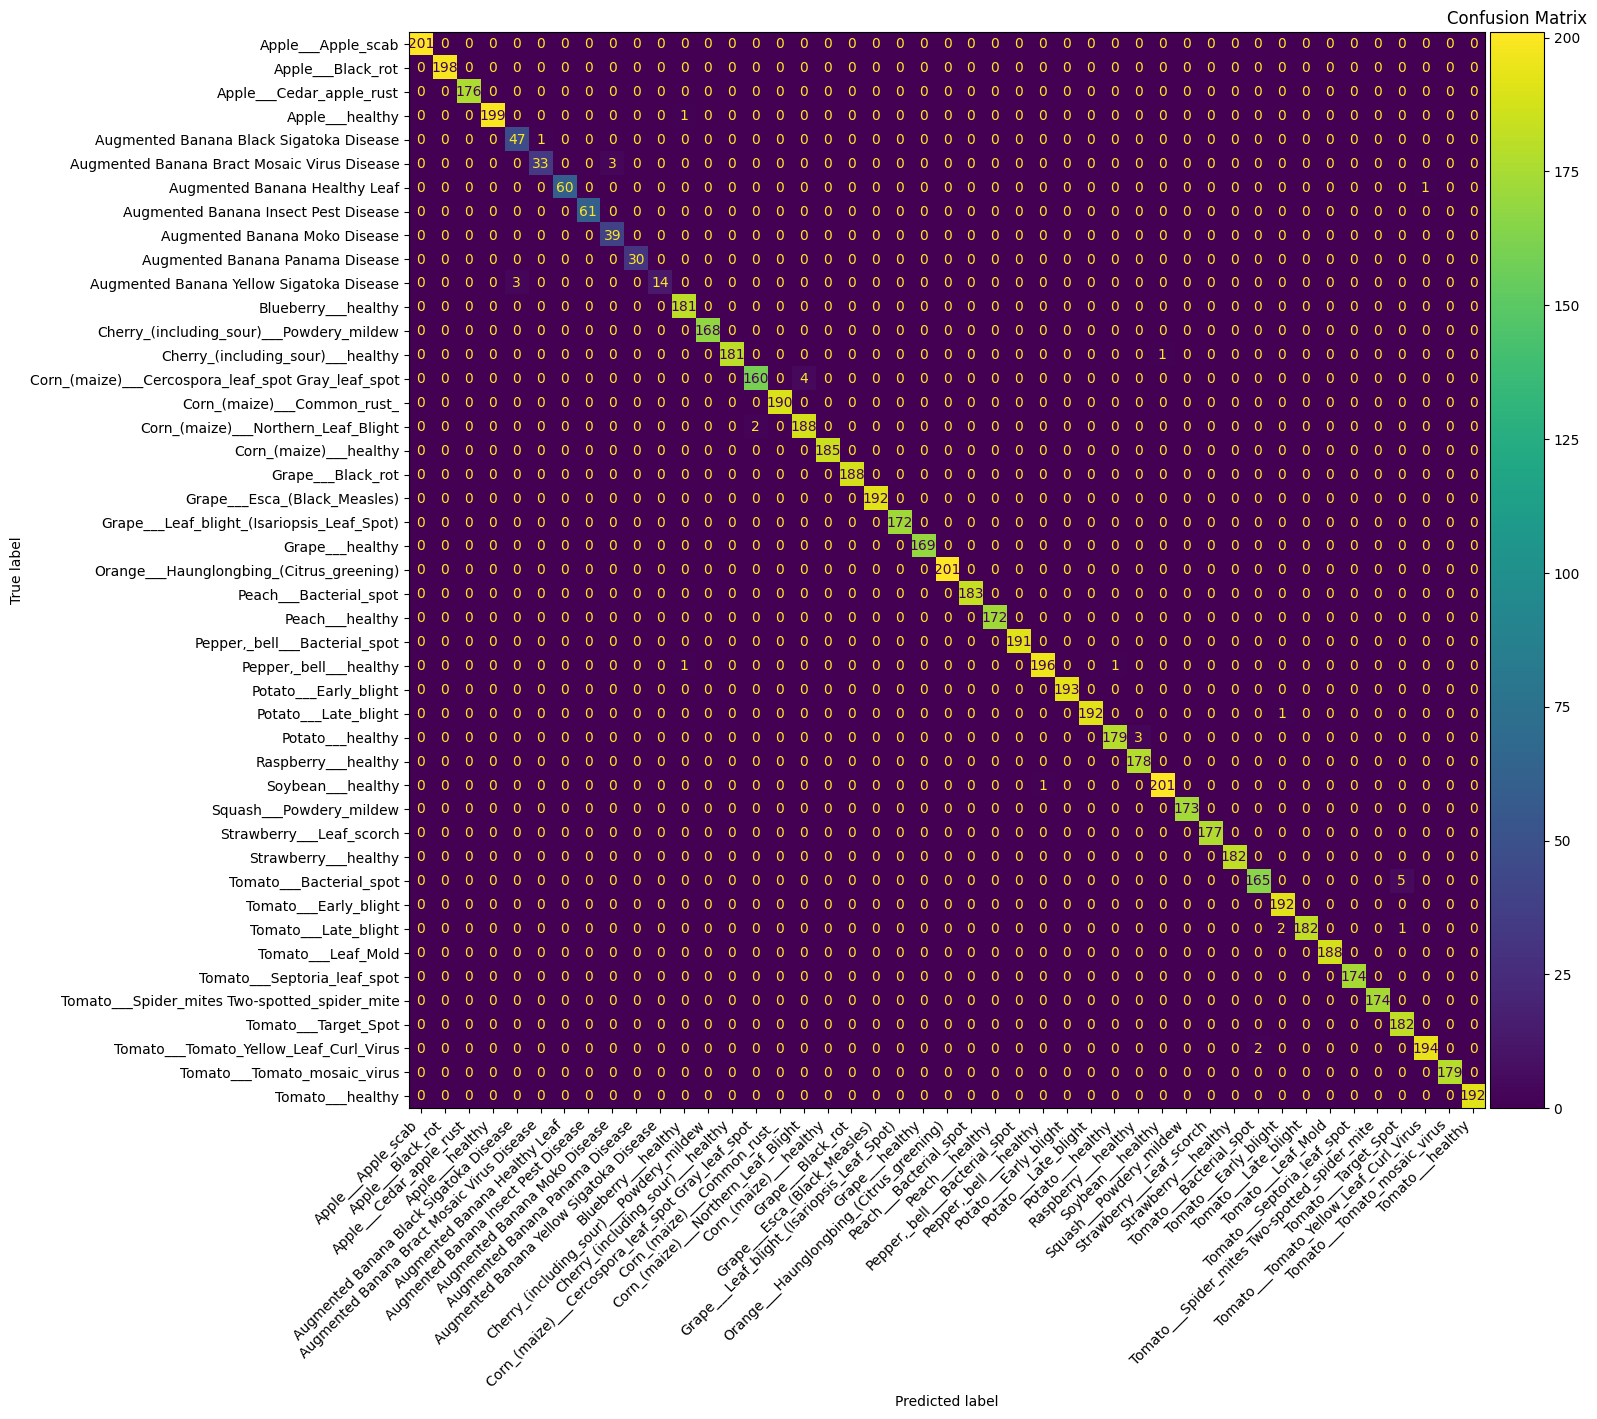

                                                Class   TP  FP    TN  FN  \
0                                  Apple___Apple_scab  201   0  7104   0   
1                                   Apple___Black_rot  198   0  7107   0   
2                            Apple___Cedar_apple_rust  176   0  7129   0   
3                                     Apple___healthy  199   0  7105   1   
4             Augmented Banana Black Sigatoka Disease   47   3  7254   1   
5         Augmented Banana Bract Mosaic Virus Disease   33   1  7268   3   
6                       Augmented Banana Healthy Leaf   60   0  7244   1   
7                Augmented Banana Insect Pest Disease   61   0  7244   0   
8                       Augmented Banana Moko Disease   39   3  7263   0   
9                     Augmented Banana Panama Disease   30   0  7275   0   
10           Augmented Banana Yellow Sigatoka Disease   14   0  7288   3   
11                                Blueberry___healthy  181   2  7122   0   
12          

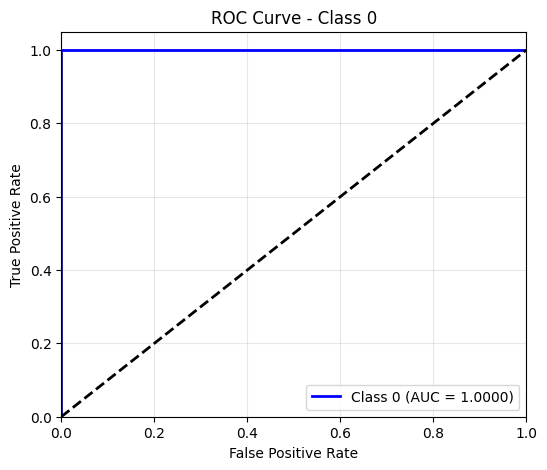

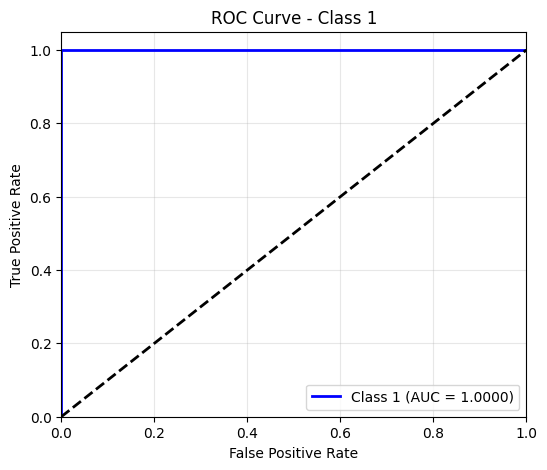

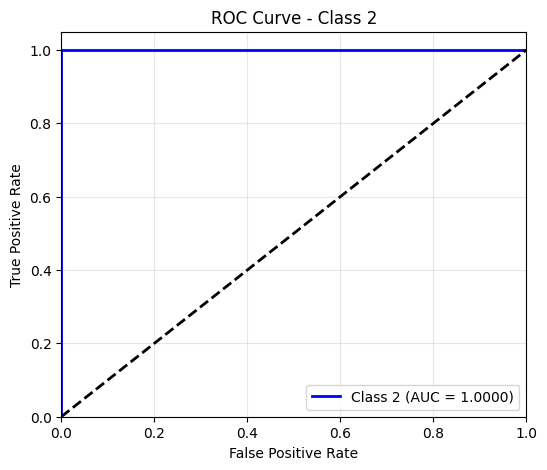

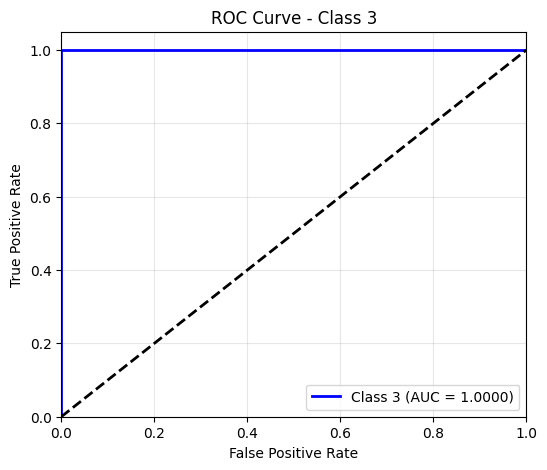

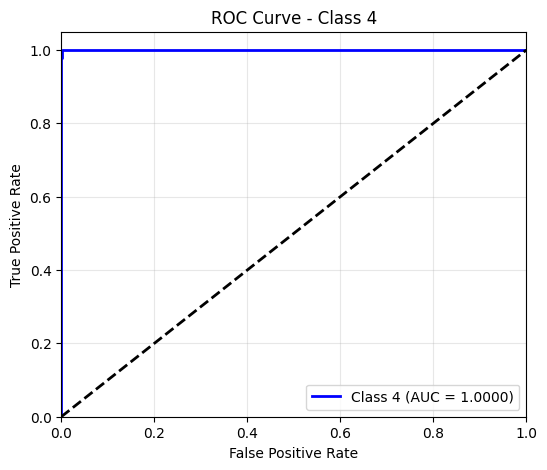

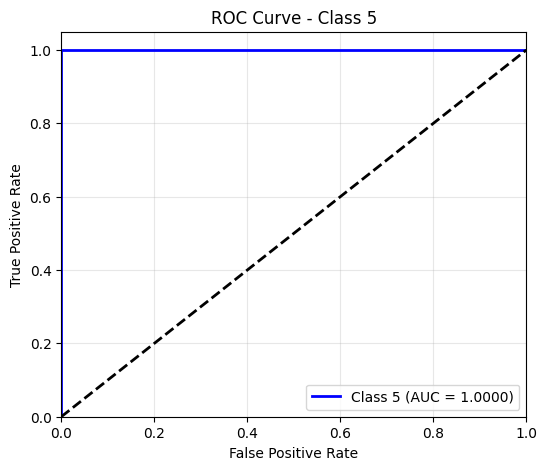

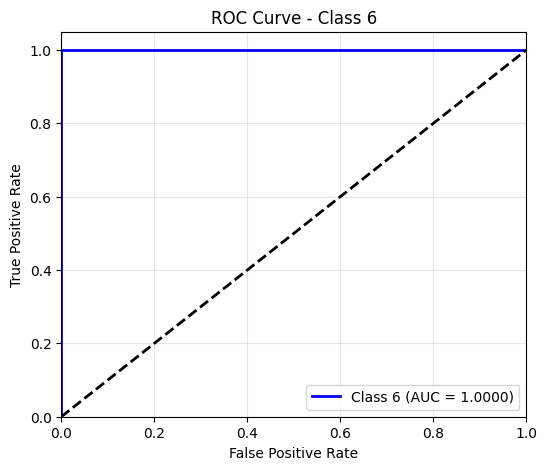

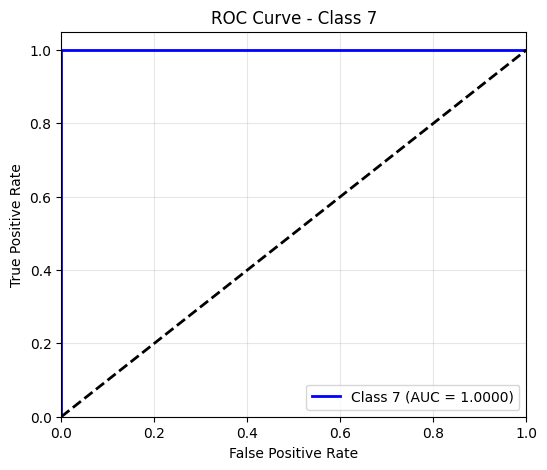

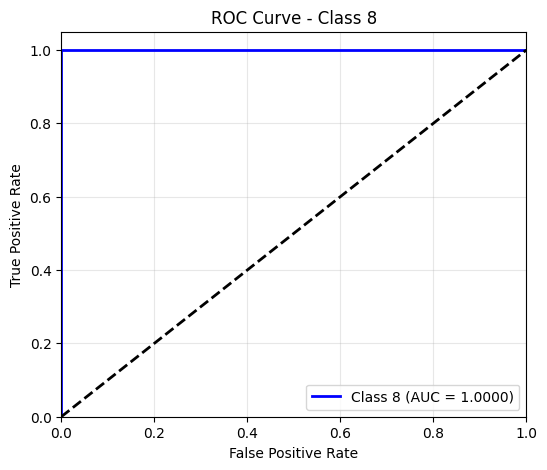

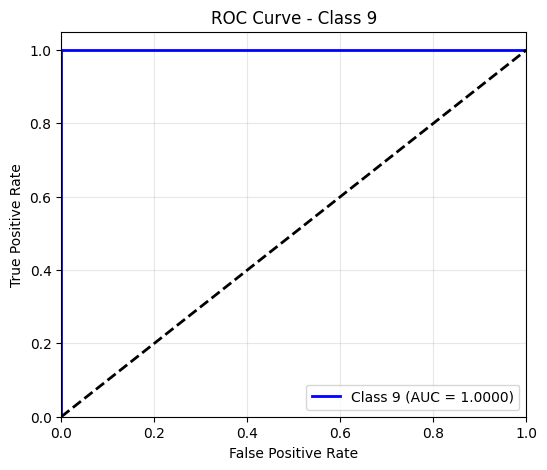

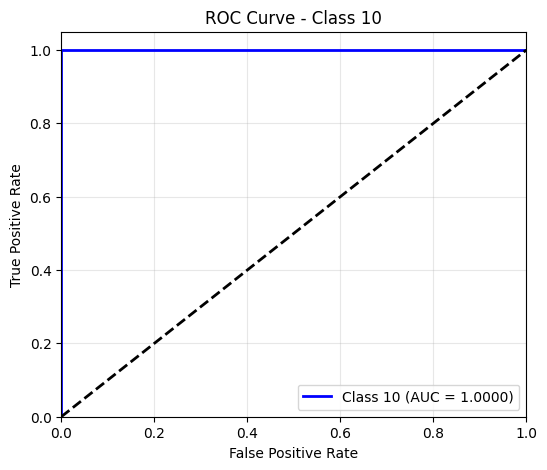

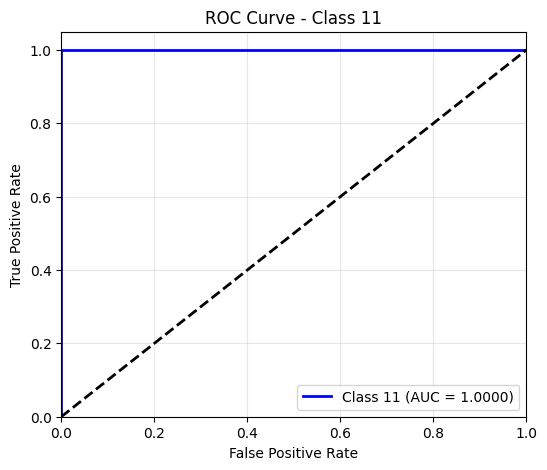

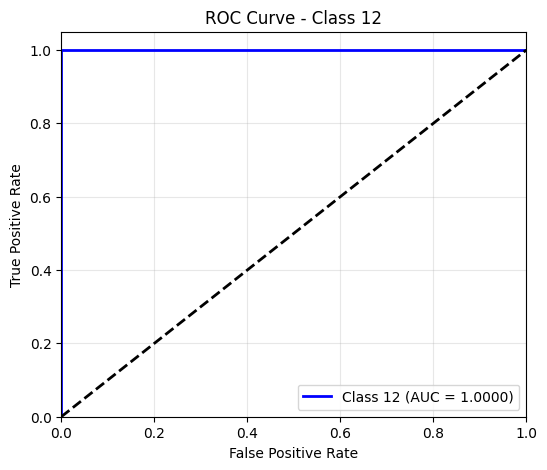

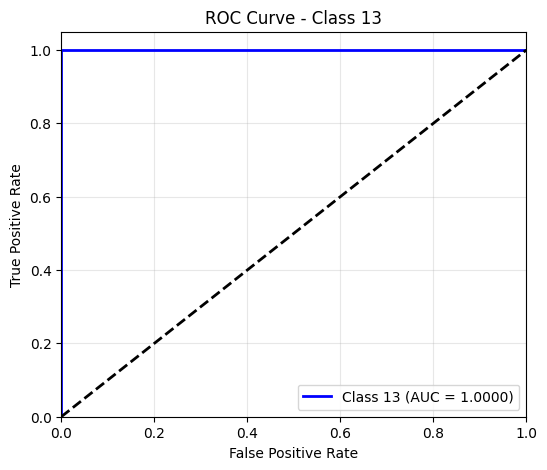

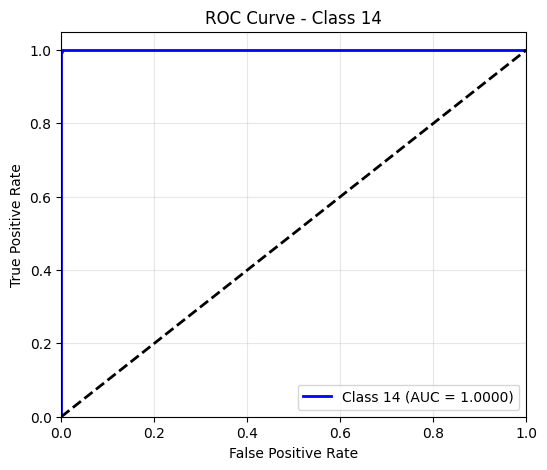

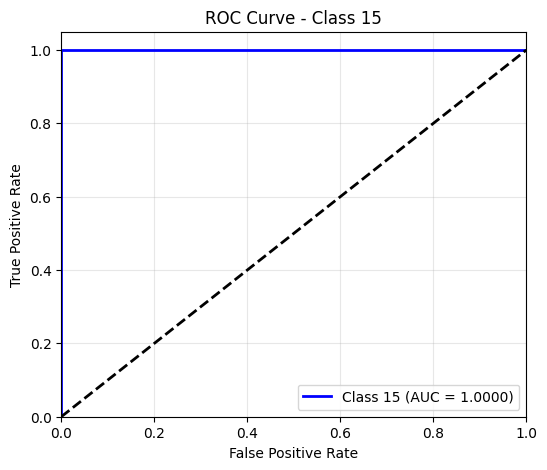

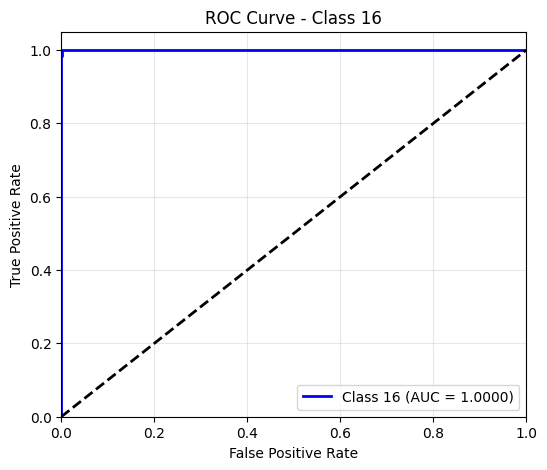

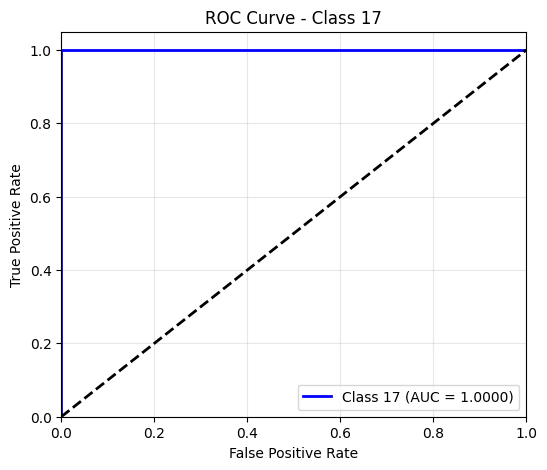

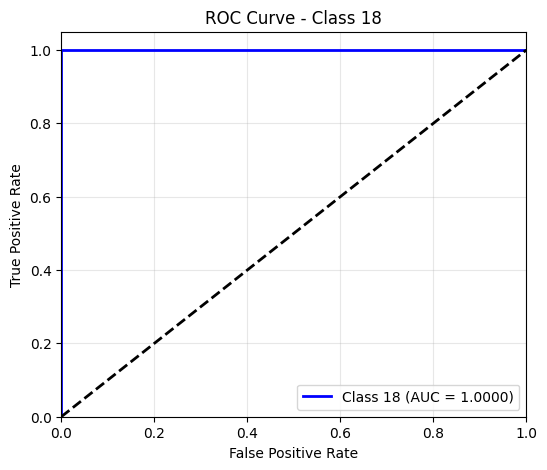

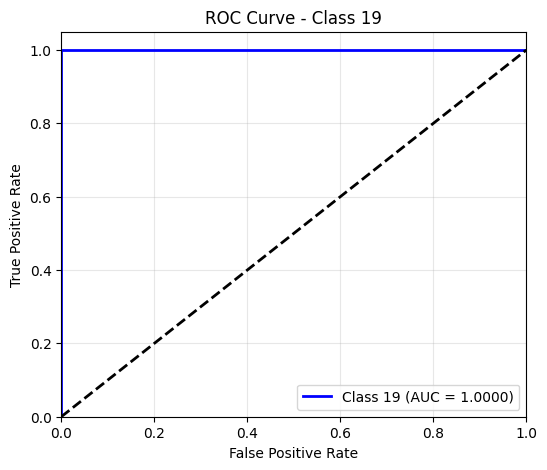

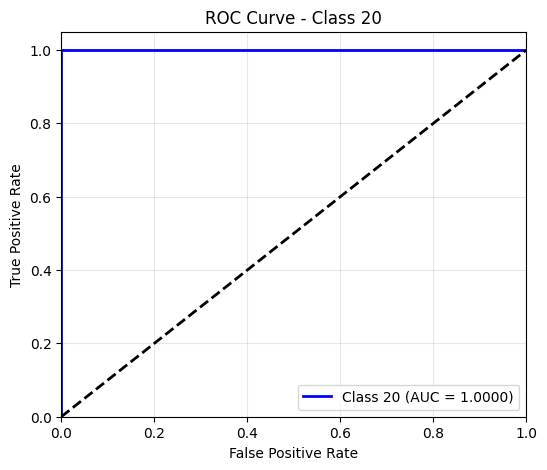

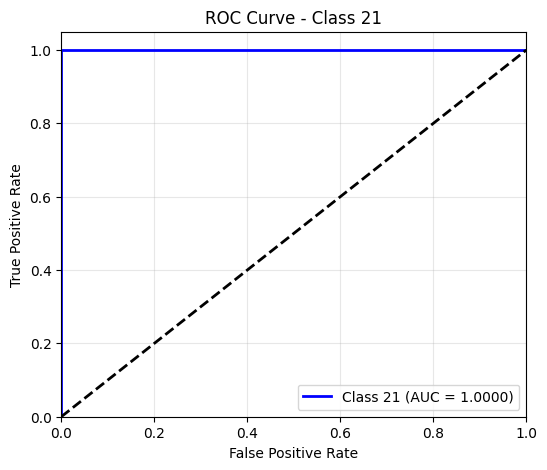

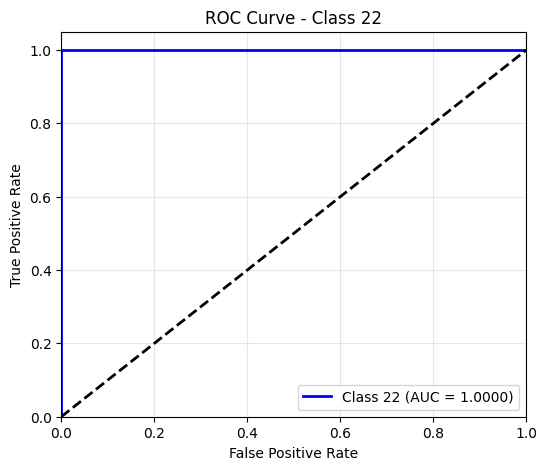

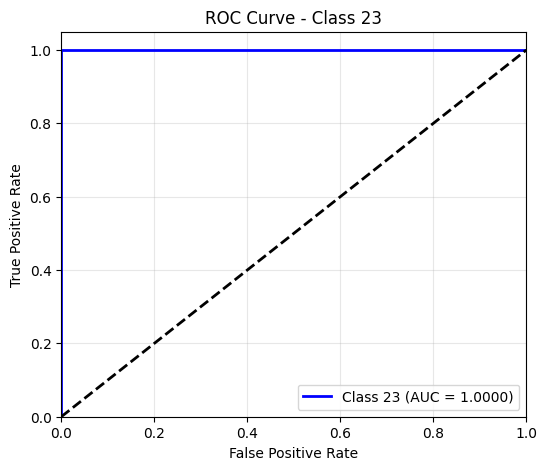

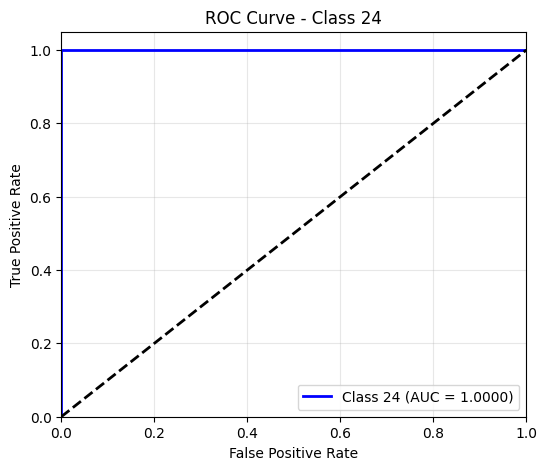

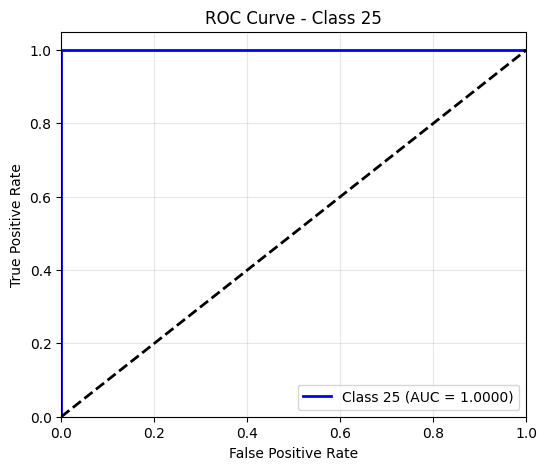

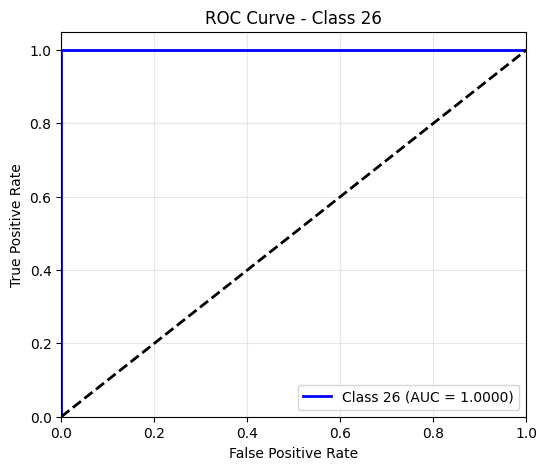

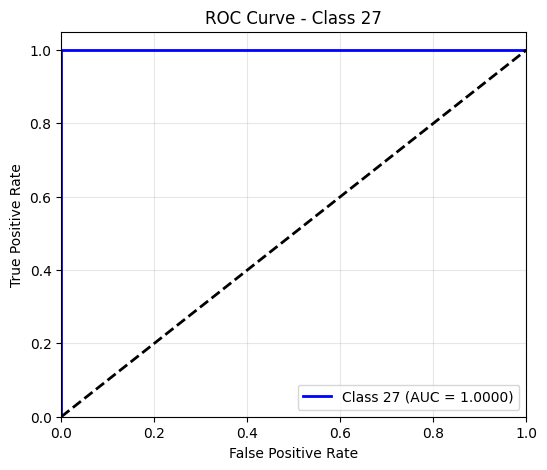

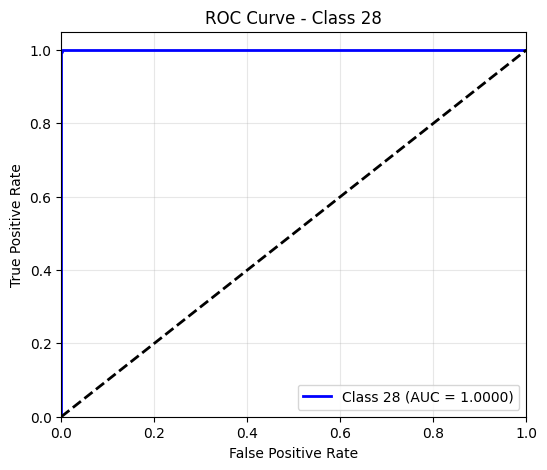

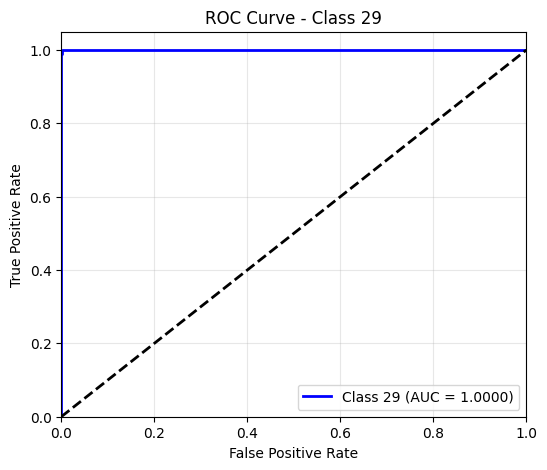

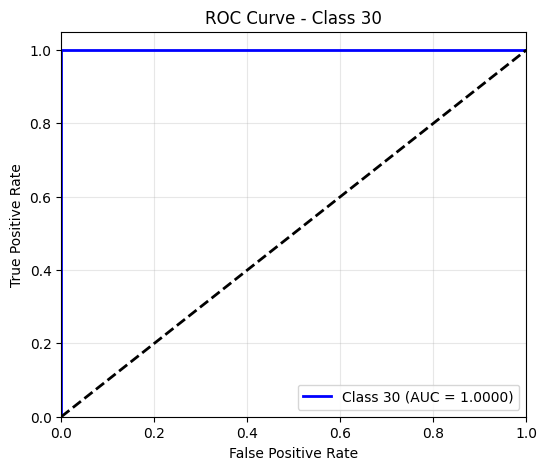

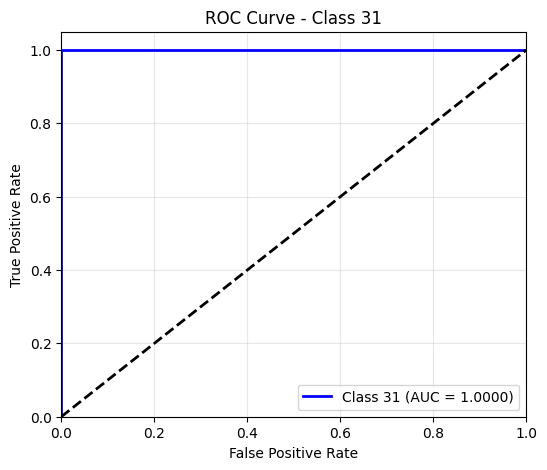

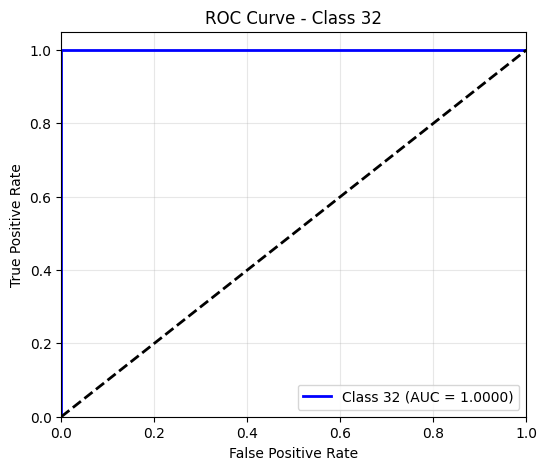

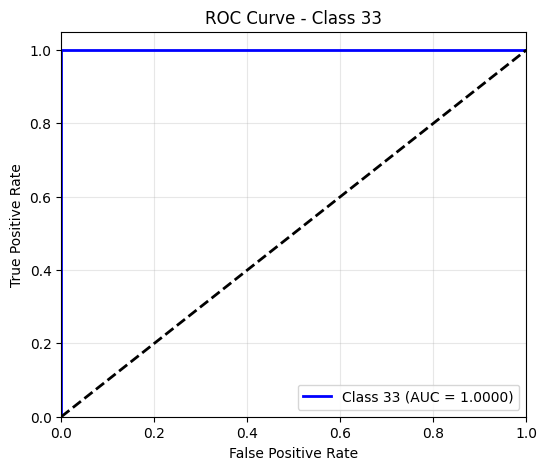

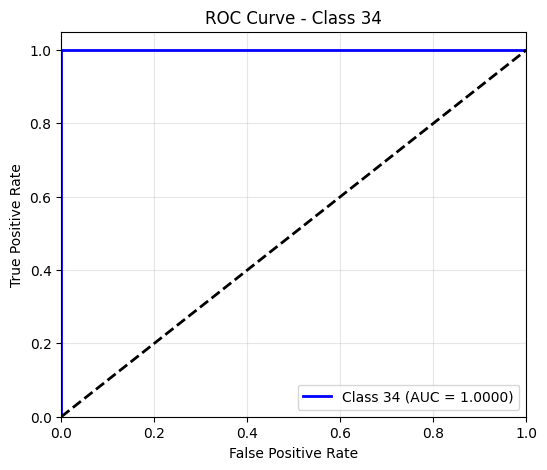

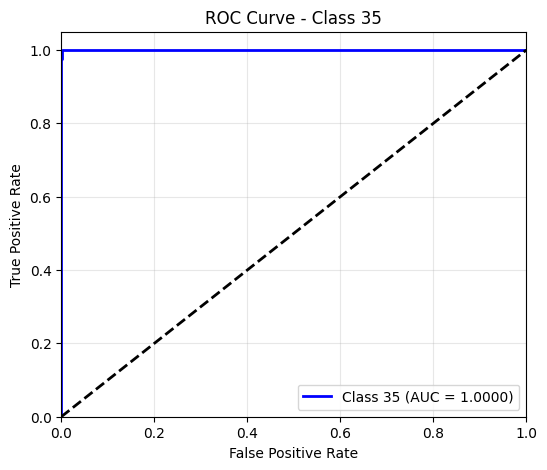

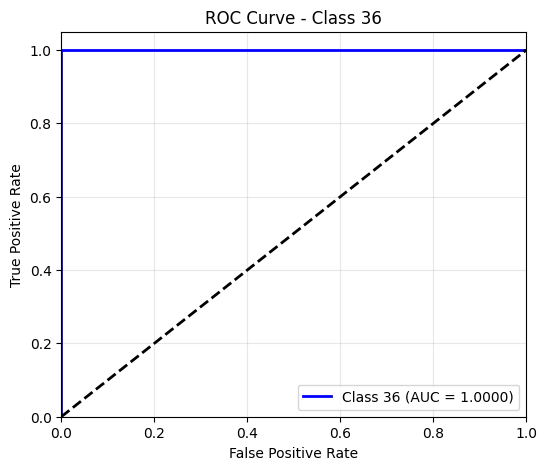

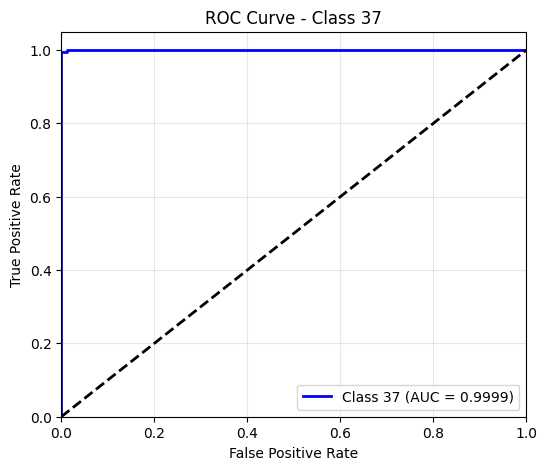

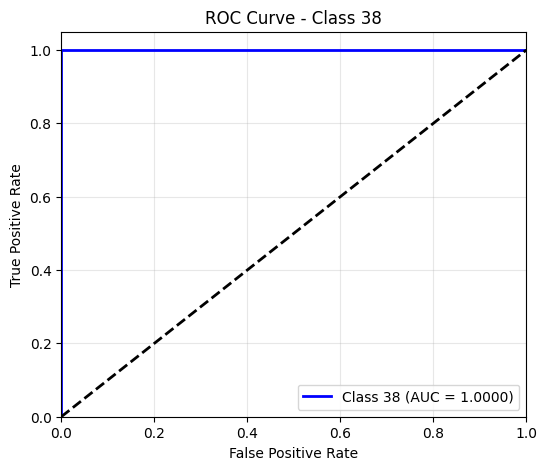

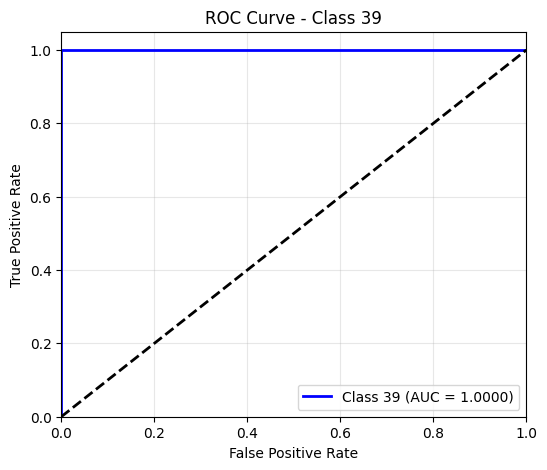

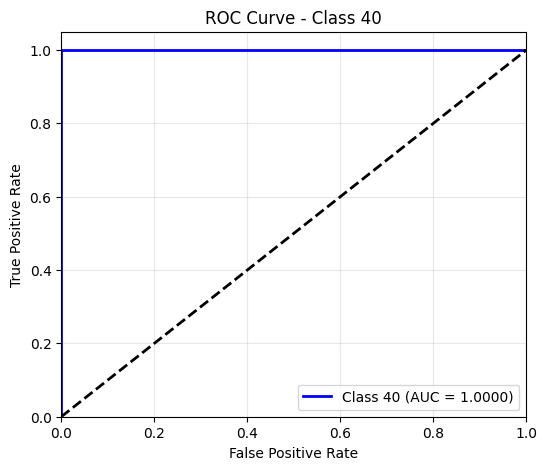

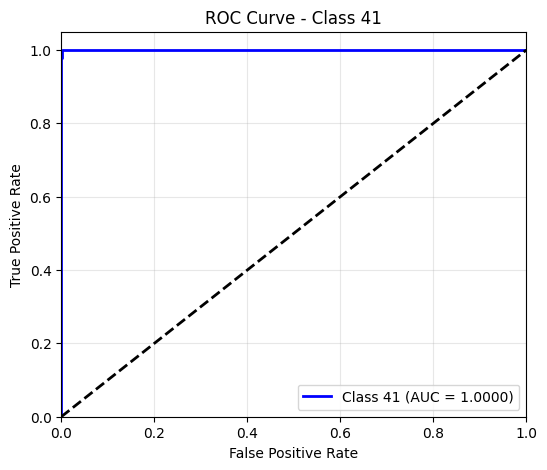

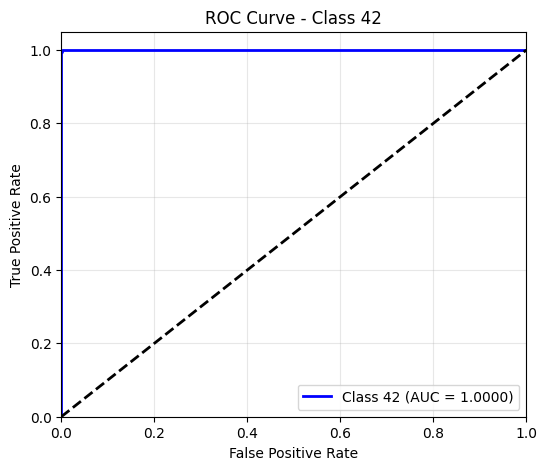

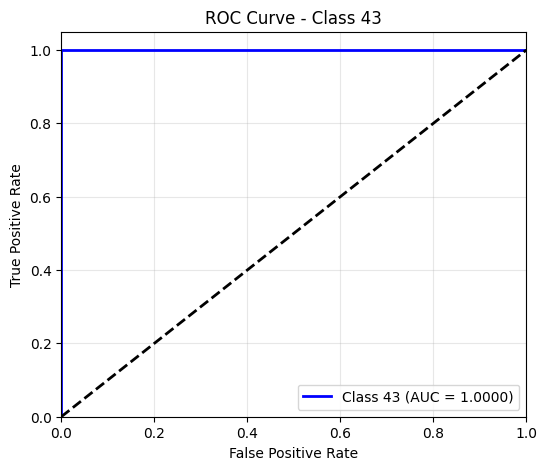

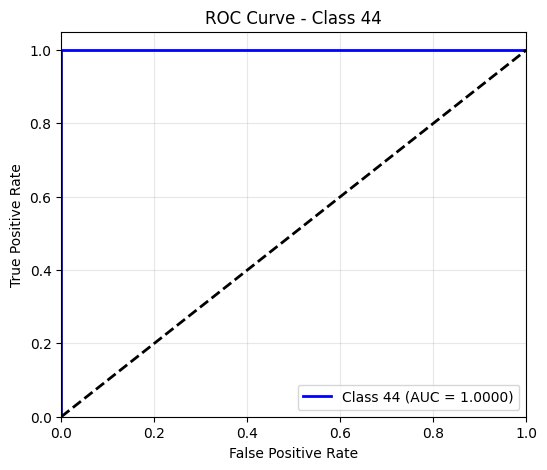

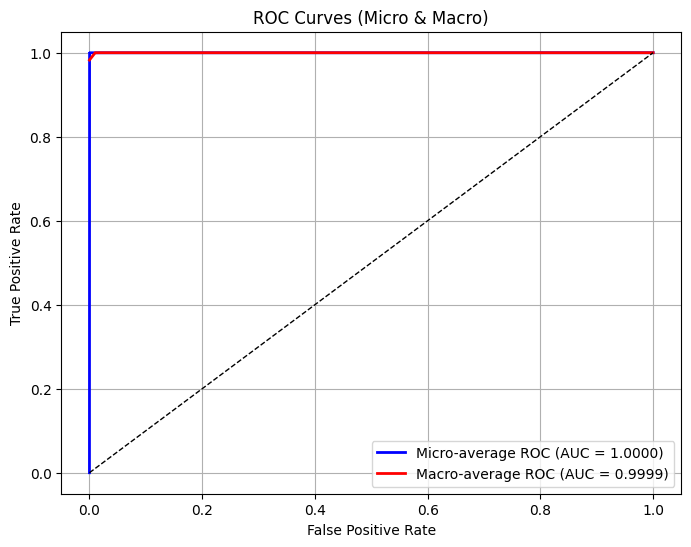

AUC Micro: 0.9999972776519459
AUC Macro: 0.9999108433651493


In [8]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def test_model_plant(model, test_loader, model_classes, device="cuda", show_misclassified=True, max_images=12):
    """
    Test a pretrained model on a subset of classes (one plant).
    
    model_classes: list of class names in the order of the model's output (all 45 classes)
    test_loader: DataLoader with only the subset of images for this plant
    """
    model.to(device)
    model.eval()

    # Les classes présentes dans le dataset test (subset)
    test_classes = test_loader.dataset.classes
    print("Classes:", test_classes)
    test_class_indices = [model_classes.index(c) for c in test_classes]
    print("Indices:", test_class_indices)

    all_preds, all_labels = [], []
    misclassified_images, misclassified_true, misclassified_pred = [], [], []
    all_probs = []  # 🔥 nouvelle ligne

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Filtrer les outputs pour ne garder que les classes du sous-ensemble
            outputs_subset = outputs[:, test_class_indices]

            # Prédiction top-1
            _, predicted = torch.max(outputs_subset, 1)

            # Collecter les labels et prédictions
            #all_preds.extend(predicted.cpu().numpy())
            #all_labels.extend(labels.cpu().numpy())

            # 🔥 AJOUT IMPORTANT
            probs = F.softmax(outputs_subset, dim=1)
    
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-5 (facultatif)
            # top5_probs, top5_preds = torch.topk(outputs_subset, 5, dim=1)

            # Collecter les erreurs
            for i in range(len(labels)):
                if predicted[i] != labels[i] and len(misclassified_images) < max_images:
                    misclassified_images.append(images[i].cpu())
                    misclassified_true.append(labels[i].item())
                    misclassified_pred.append(predicted[i].item())        
        
          
            
    # Rapport de classification
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=test_classes))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(16, 16))  # Ajuste la taille si nécessaire
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_classes)
    disp.plot(cmap="viridis", ax=ax, xticks_rotation=45, values_format='d', colorbar=False)
            
    # Ajuster les ticks pour qu'ils soient centrés
    ax.set_xticks(range(len(test_classes)))
    ax.set_yticks(range(len(test_classes)))
    ax.set_xticklabels(test_classes, rotation=45, ha='right')  # ha='right' aligne bien horizontalement
    ax.set_yticklabels(test_classes)

    # Créer une colorbar de la même hauteur que la matrice
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)  # taille et espacement de la colorbar
    im = ax.imshow(cm, cmap="viridis")  # refaire l'imshow pour la colorbar
    plt.colorbar(im, cax=cax)
    
    plt.title("Confusion Matrix")
    plt.tight_layout()  # Évite que les labels se coupent
    plt.savefig('general_cfm.png')
    plt.show()

    #all_probs = np.array(all_probs)
    #all_labels = np.array(all_labels)

    # Convertir en array numpy
    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)

    tp_fp_tn_fn_table = get_tp_fp_tn_fn(all_labels, all_preds, test_classes)
    #print(tp_fp_tn_fn_table)
    metrics_table = get_metrics_table(tp_fp_tn_fn_table)
    pd.set_option("display.max_rows", None)  # Pour afficher toutes les classes
    print(metrics_table)
    metrics_table.to_csv("TP_FP_TN_FN_metrics.csv", index=False)


    n_classes = len(test_classes)    
    y_true_bin = label_binarize(all_labels, classes=range(n_classes))
    
    # ROC micro-average
    fpr_micro, tpr_micro, _ = roc_curve(
        y_true_bin.ravel(),
        all_probs.ravel()
    )
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    
    # ROC macro-average
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(6,5))
        plt.plot(fpr[i], tpr[i], color='b', lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.4f})')
        plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle='--')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Class {i}')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        
        # Sauvegarde automatique de chaque figure
        plt.savefig(f'roc_class_{i}.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    
    roc_auc_macro = np.mean(list(roc_auc.values()))
    
    # Macro-average
    # On interpole toutes les courbes à des points communs
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    fpr_macro = all_fpr
    tpr_macro = mean_tpr
    roc_auc_macro = auc(fpr_macro, tpr_macro)
    
    # Tracé
    plt.figure(figsize=(8,6))
    
    plt.plot(fpr_micro, tpr_micro,
             label=f"Micro-average ROC (AUC = {roc_auc_micro:.4f})",
             linewidth=2, color='blue')
    
    plt.plot(fpr_macro, tpr_macro,
             label=f"Macro-average ROC (AUC = {roc_auc_macro:.4f})",
             linewidth=2, color='red')
    
    plt.plot([0,1],[0,1],'k--', linewidth=1)  # diagonale
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Micro & Macro)")
    plt.legend(loc='lower right')
    plt.grid()
    plt.savefig('general_roc_curves_micro_macro.png')
    plt.show()
    
    print("AUC Micro:", roc_auc_micro)
    print("AUC Macro:", roc_auc_macro)


  
from collections import OrderedDict

# Charger les poids sauvegardés
state_dict = torch.load("/kaggle/input/agrivitnet_2/pytorch/default/1/best_model_agrivitnet_on_new_plant_and_banana.pth", map_location=DEVICE)
,
# Supprimer "module." si présent (cas DataParallel)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # enlever le prefixe
    new_state_dict[name] = v

# Reconstruire ton modèle
model = AgriViTNet(NUM_CLASSES)

# Charger les poids corrigés
model.load_state_dict(new_state_dict, strict=True)
model = model.to(DEVICE)
model.eval()

test_model_plant(model, test_loader, test_classes, DEVICE)

Number of test samples: 775
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Indices: [0, 1, 2, 3]
Classification Report:

                          precision    recall  f1-score   support

      Apple___Apple_scab       1.00      1.00      1.00       201
       Apple___Black_rot       1.00      1.00      1.00       198
Apple___Cedar_apple_rust       1.00      1.00      1.00       176
         Apple___healthy       1.00      1.00      1.00       200

                accuracy                           1.00       775
               macro avg       1.00      1.00      1.00       775
            weighted avg       1.00      1.00      1.00       775



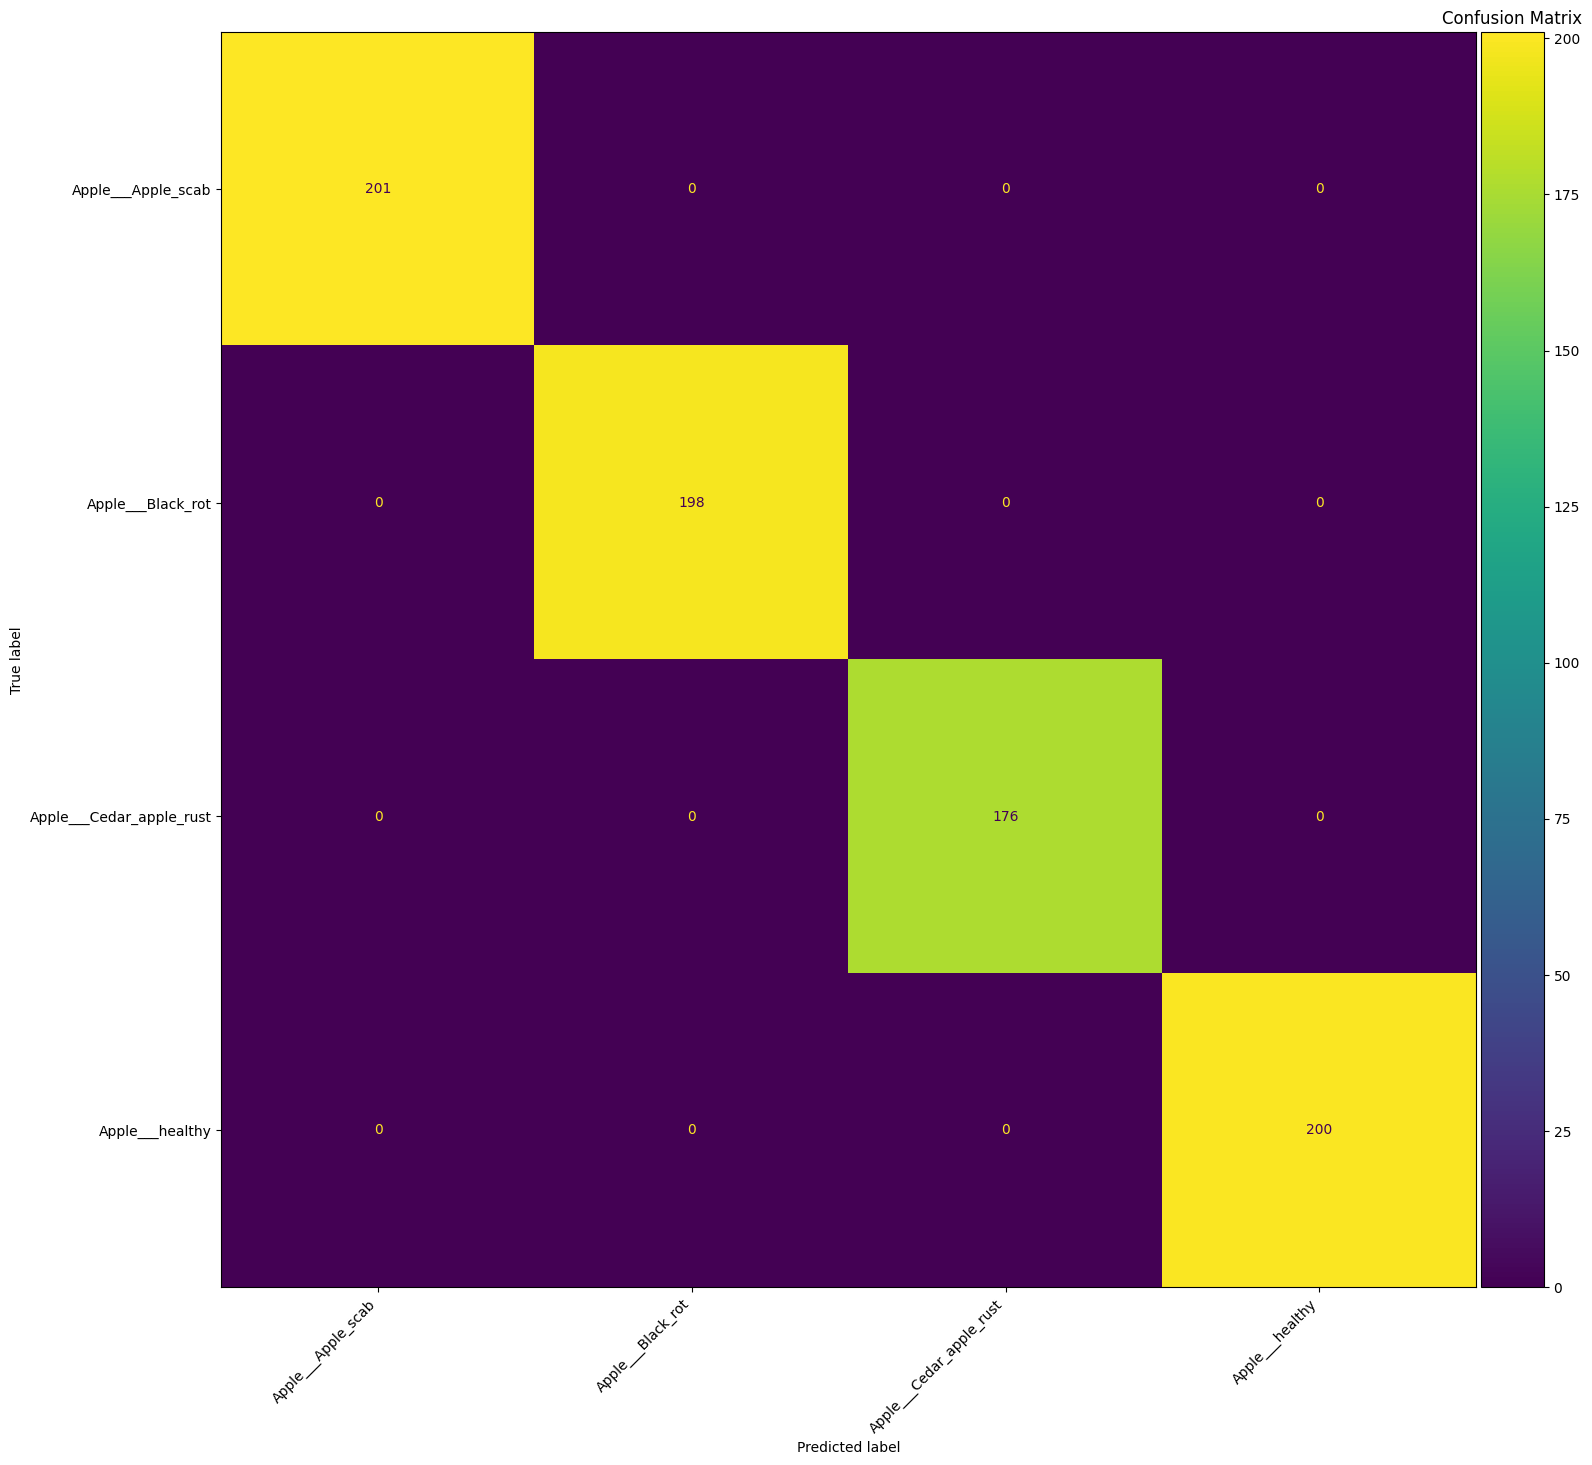

                      Class   TP  FP   TN  FN  Precision  Recall  F1-score  \
0        Apple___Apple_scab  201   0  574   0        1.0     1.0       1.0   
1         Apple___Black_rot  198   0  577   0        1.0     1.0       1.0   
2  Apple___Cedar_apple_rust  176   0  599   0        1.0     1.0       1.0   
3           Apple___healthy  200   0  575   0        1.0     1.0       1.0   

   Accuracy  
0       1.0  
1       1.0  
2       1.0  
3       1.0  


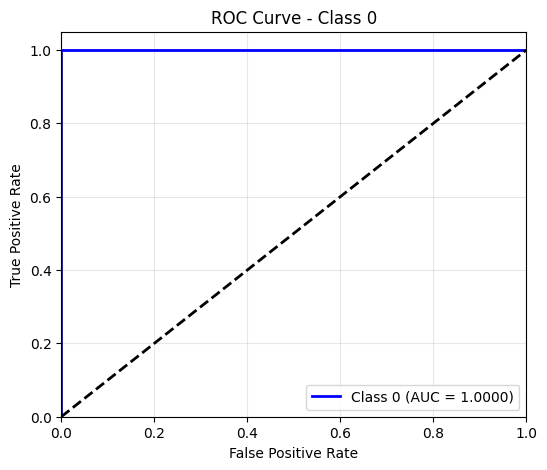

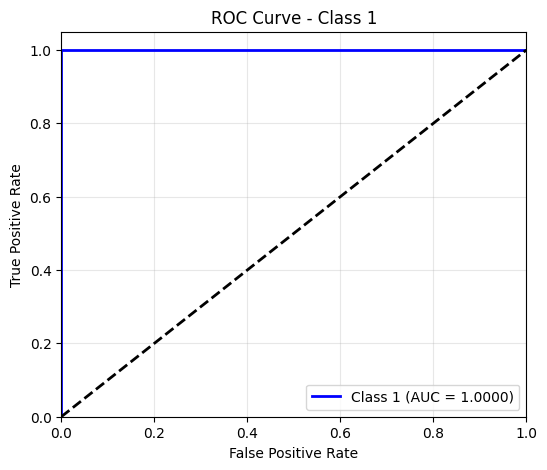

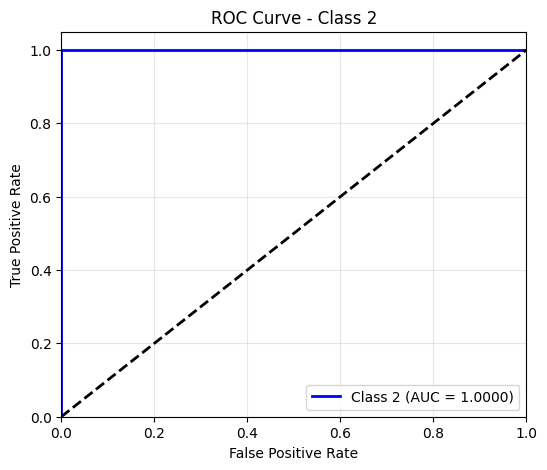

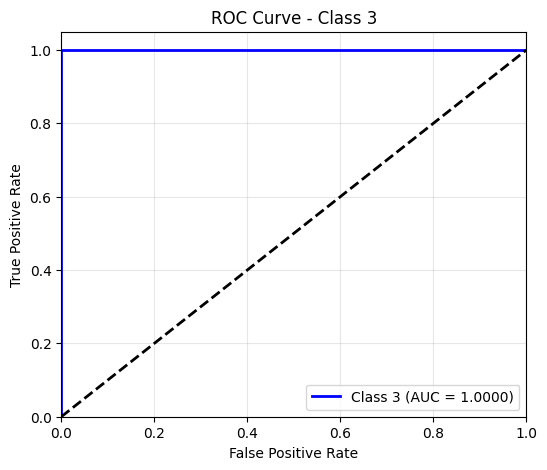

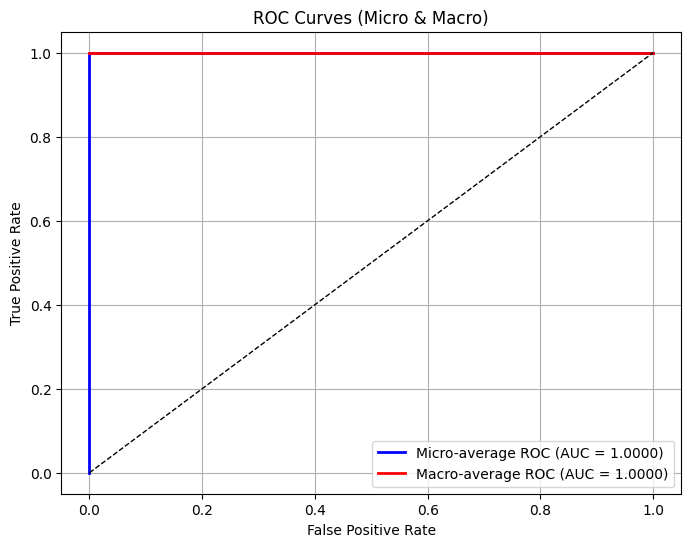

AUC Micro: 1.0
AUC Macro: 1.0


In [10]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Apple___Apple_scab", f"{sub_test_path}/Apple___Apple_scab")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Apple___Black_rot", f"{sub_test_path}/Apple___Black_rot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Apple___Cedar_apple_rust", f"{sub_test_path}/Apple___Cedar_apple_rust")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Apple___healthy", f"{sub_test_path}/Apple___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 292
Classes: ['Augmented Banana Black Sigatoka Disease', 'Augmented Banana Bract Mosaic Virus Disease', 'Augmented Banana Healthy Leaf', 'Augmented Banana Insect Pest Disease', 'Augmented Banana Moko Disease', 'Augmented Banana Panama Disease', 'Augmented Banana Yellow Sigatoka Disease']
Classes: ['Augmented Banana Black Sigatoka Disease', 'Augmented Banana Bract Mosaic Virus Disease', 'Augmented Banana Healthy Leaf', 'Augmented Banana Insect Pest Disease', 'Augmented Banana Moko Disease', 'Augmented Banana Panama Disease', 'Augmented Banana Yellow Sigatoka Disease']
Indices: [4, 5, 6, 7, 8, 9, 10]
Classification Report:

                                             precision    recall  f1-score   support

    Augmented Banana Black Sigatoka Disease       0.87      0.94      0.90        48
Augmented Banana Bract Mosaic Virus Disease       1.00      0.97      0.99        36
              Augmented Banana Healthy Leaf       1.00      1.00      1.00        61
     

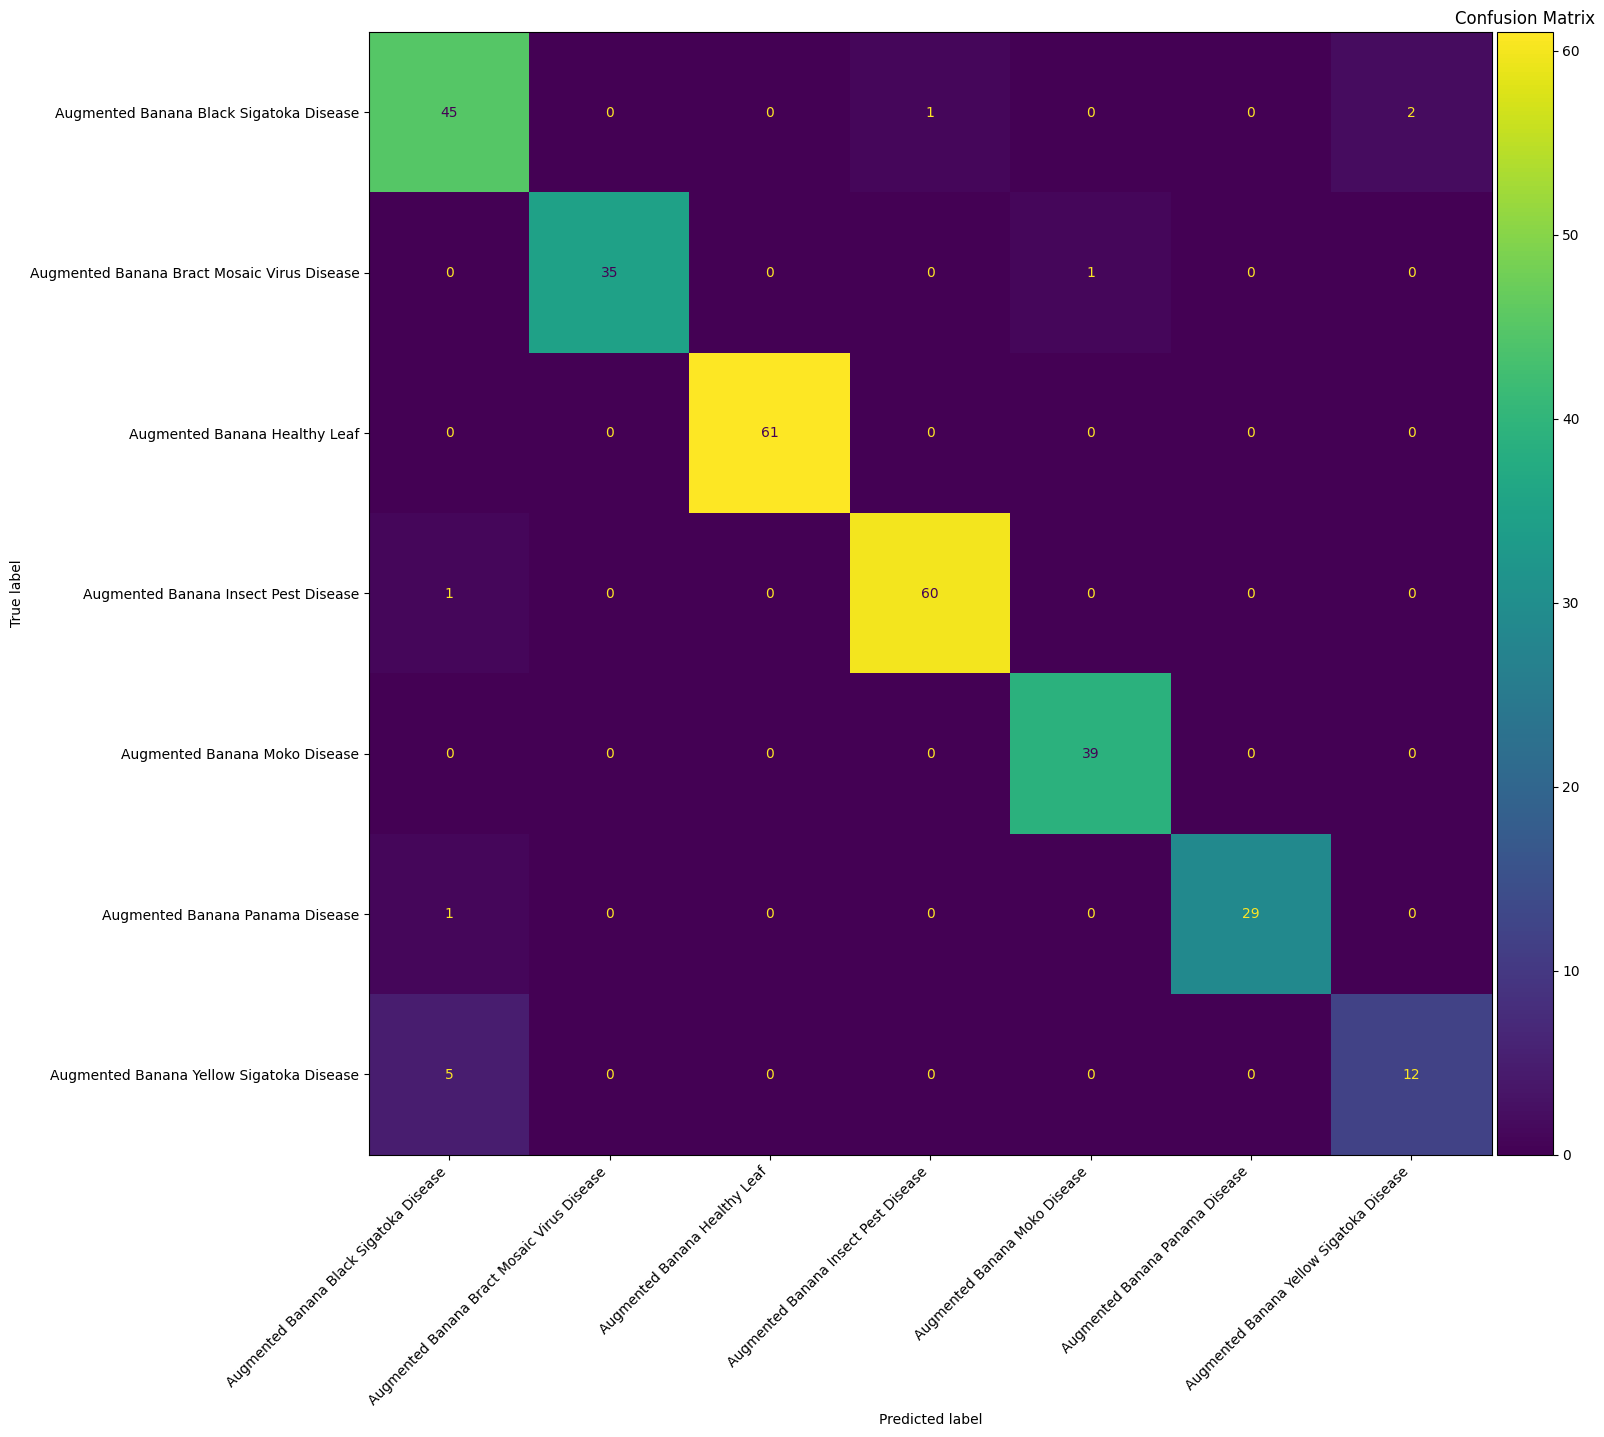

                                         Class  TP  FP   TN  FN  Precision  \
0      Augmented Banana Black Sigatoka Disease  45   7  237   3   0.865385   
1  Augmented Banana Bract Mosaic Virus Disease  35   0  256   1   1.000000   
2                Augmented Banana Healthy Leaf  61   0  231   0   1.000000   
3         Augmented Banana Insect Pest Disease  60   1  230   1   0.983607   
4                Augmented Banana Moko Disease  39   1  252   0   0.975000   
5              Augmented Banana Panama Disease  29   0  262   1   1.000000   
6     Augmented Banana Yellow Sigatoka Disease  12   2  273   5   0.857143   

     Recall  F1-score  Accuracy  
0  0.937500  0.900000  0.965753  
1  0.972222  0.985915  0.996575  
2  1.000000  1.000000  1.000000  
3  0.983607  0.983607  0.993151  
4  1.000000  0.987342  0.996575  
5  0.966667  0.983051  0.996575  
6  0.705882  0.774194  0.976027  


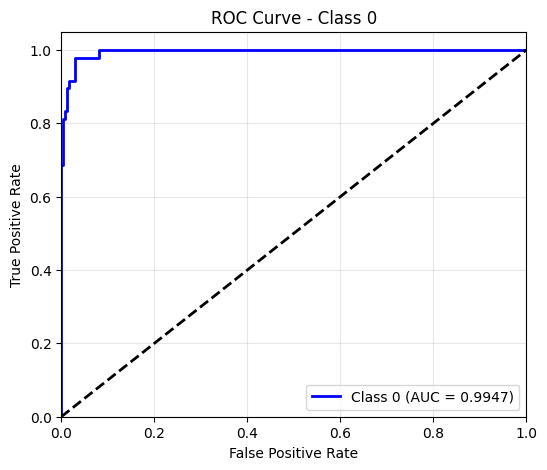

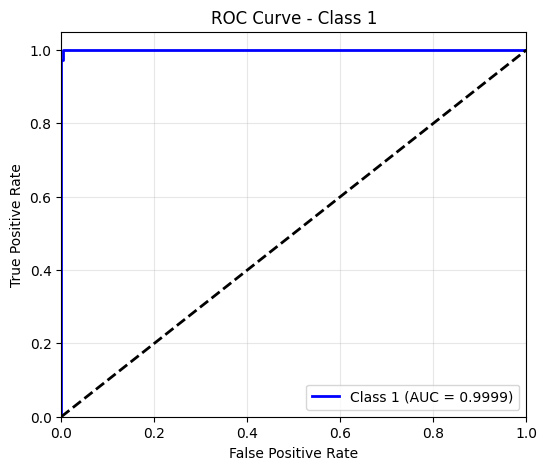

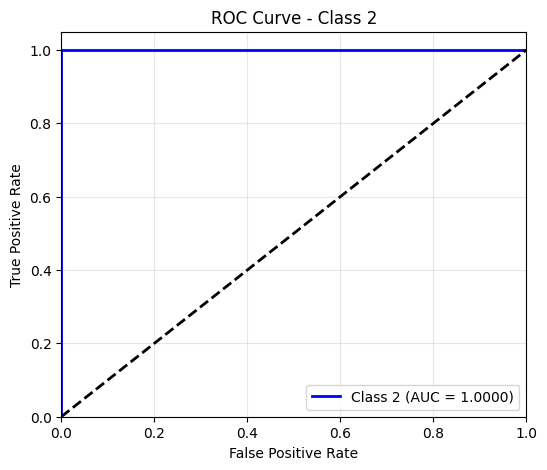

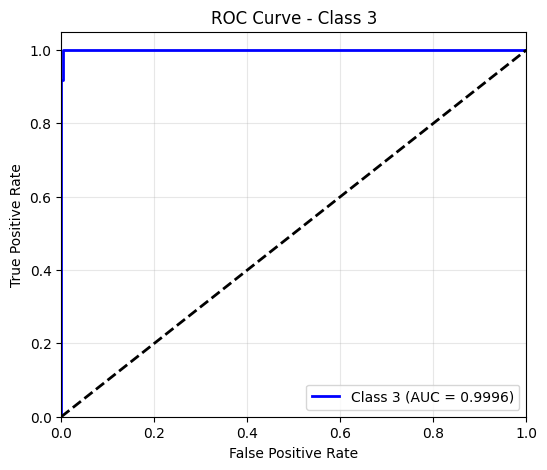

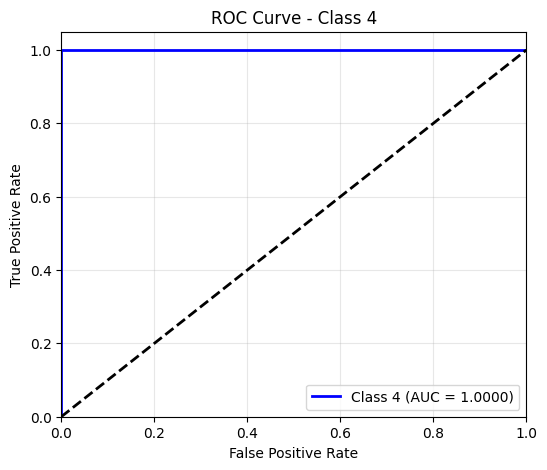

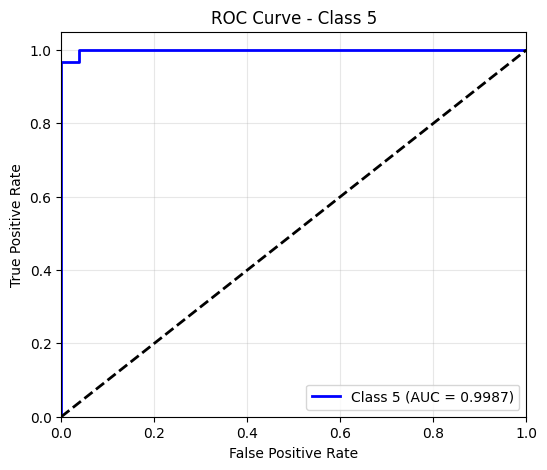

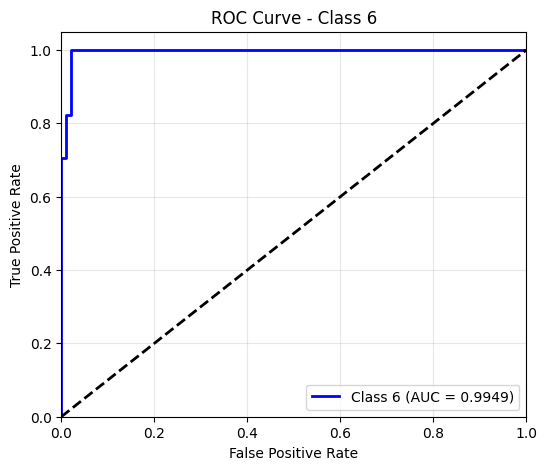

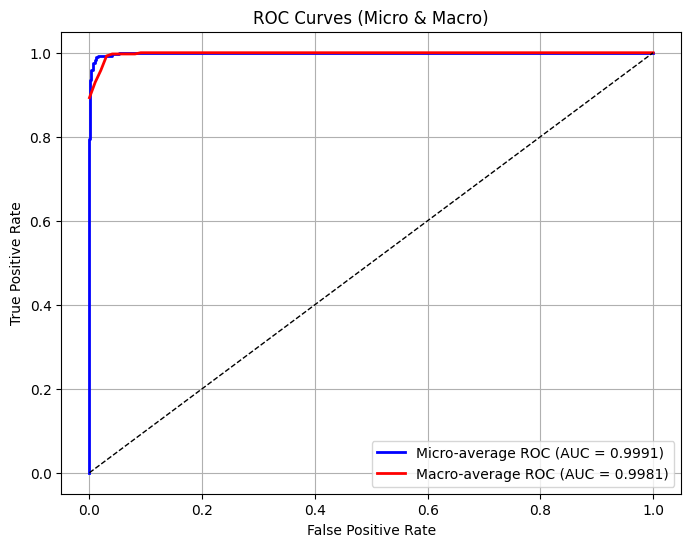

AUC Micro: 0.9991477450428472
AUC Macro: 0.9980946086277973


In [11]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Black Sigatoka Disease", f"{sub_test_path}/Augmented Banana Black Sigatoka Disease")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Bract Mosaic Virus Disease", f"{sub_test_path}/Augmented Banana Bract Mosaic Virus Disease")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Healthy Leaf", f"{sub_test_path}/Augmented Banana Healthy Leaf")    
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Insect Pest Disease", f"{sub_test_path}/Augmented Banana Insect Pest Disease")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Moko Disease", f"{sub_test_path}/Augmented Banana Moko Disease")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Panama Disease", f"{sub_test_path}/Augmented Banana Panama Disease")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Augmented Banana Yellow Sigatoka Disease", f"{sub_test_path}/Augmented Banana Yellow Sigatoka Disease")
        
sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 181
Classes: ['Blueberry___healthy']
Classes: ['Blueberry___healthy']
Indices: [11]
Classification Report:

                     precision    recall  f1-score   support

Blueberry___healthy       1.00      1.00      1.00       181

           accuracy                           1.00       181
          macro avg       1.00      1.00      1.00       181
       weighted avg       1.00      1.00      1.00       181



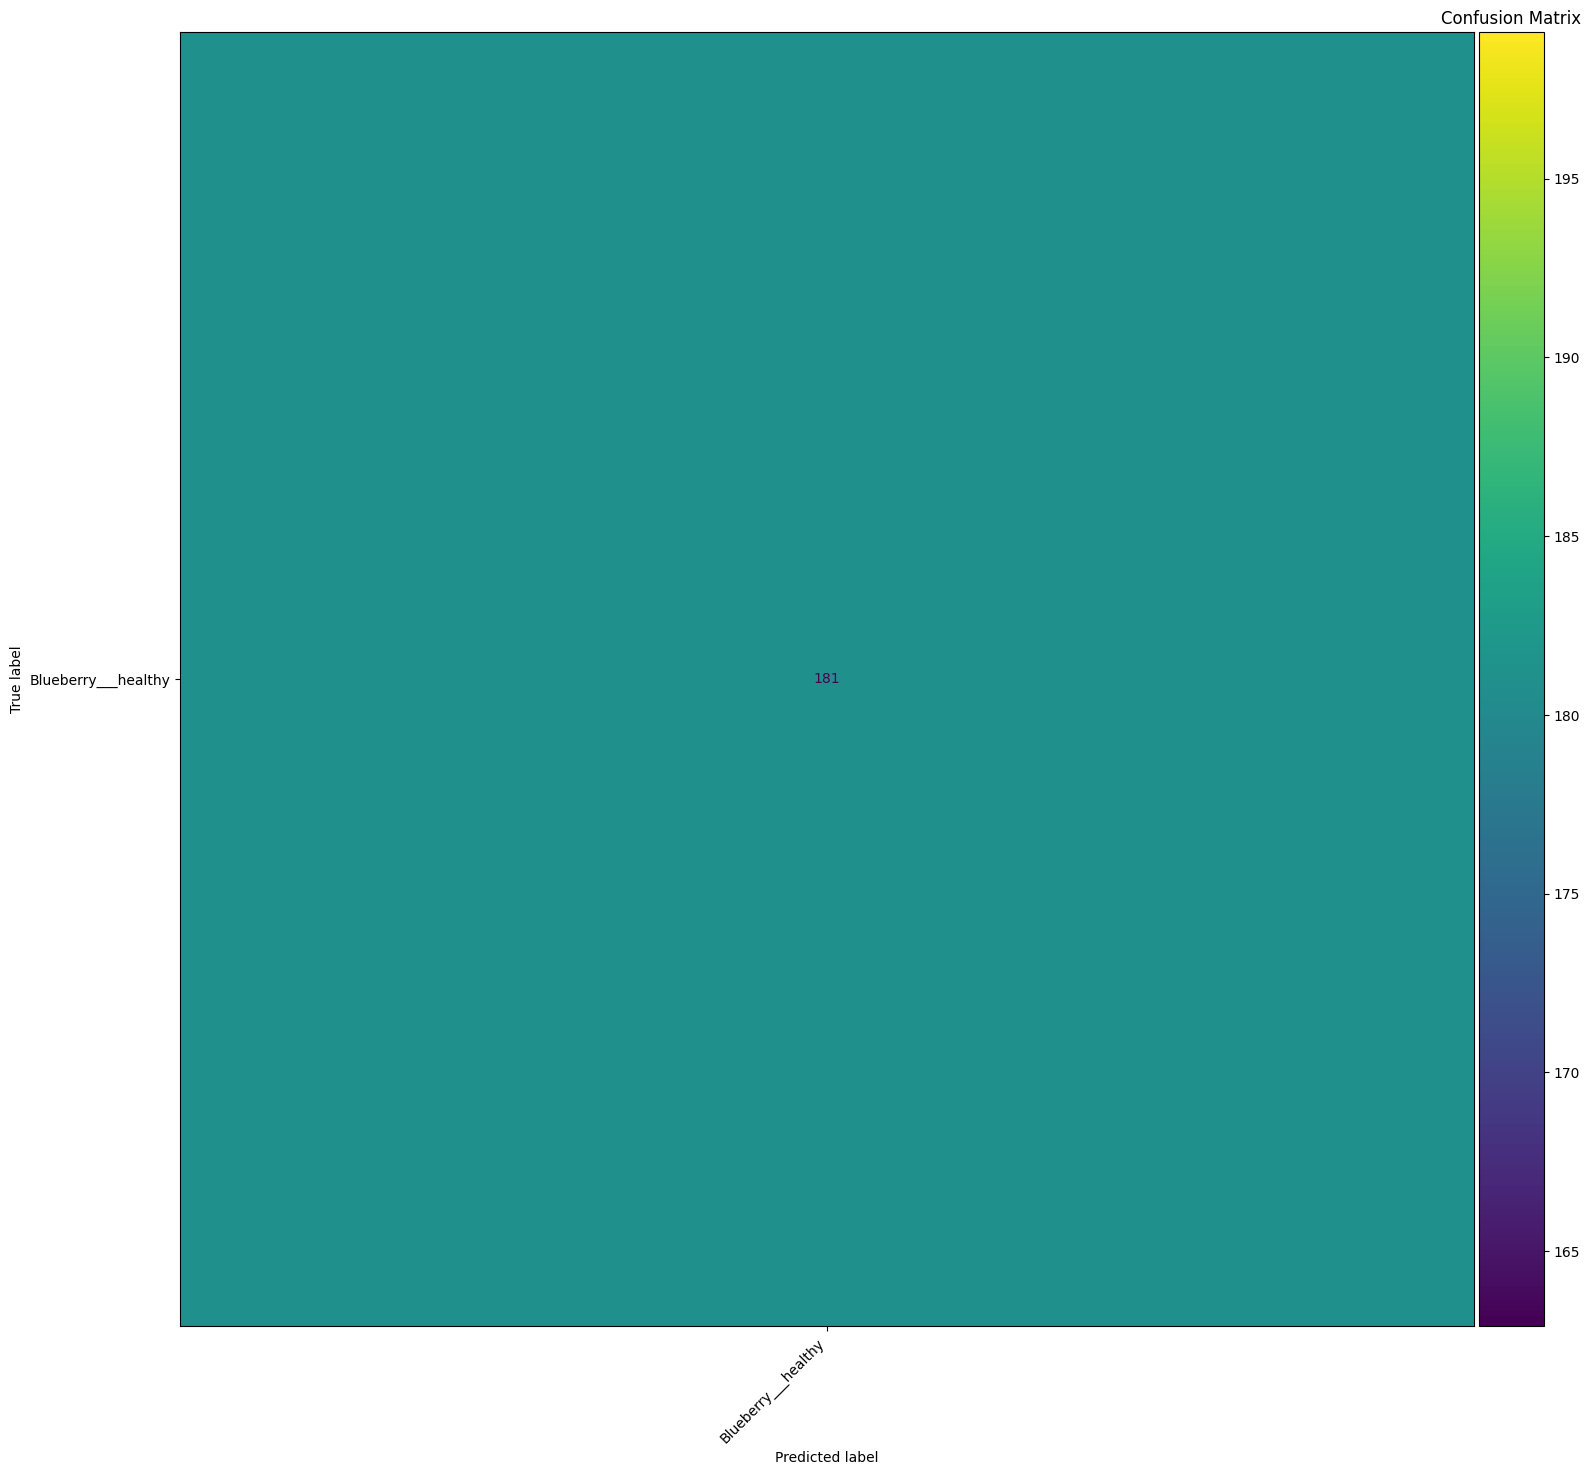

                 Class   TP  FP  TN  FN  Precision  Recall  F1-score  Accuracy
0  Blueberry___healthy  181   0   0   0        1.0     1.0       1.0       1.0


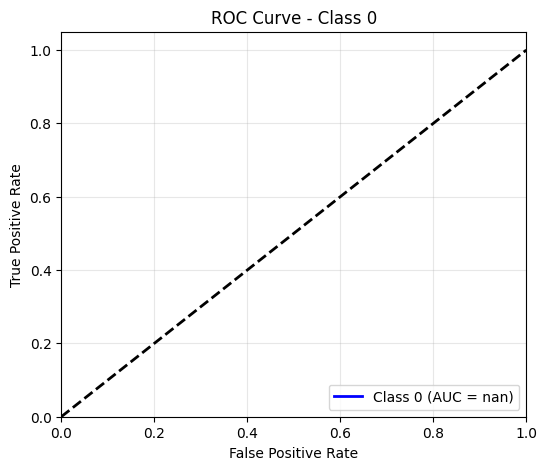

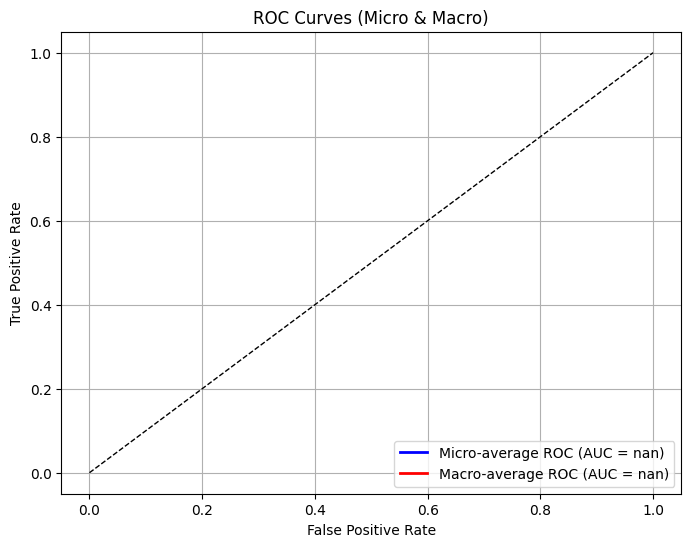

AUC Micro: nan
AUC Macro: nan


In [12]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Blueberry___healthy", f"{sub_test_path}/Blueberry___healthy")
     
sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 350
Classes: ['Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy']
Classes: ['Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy']
Indices: [12, 13]
Classification Report:

                                          precision    recall  f1-score   support

Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       168
       Cherry_(including_sour)___healthy       1.00      1.00      1.00       182

                                accuracy                           1.00       350
                               macro avg       1.00      1.00      1.00       350
                            weighted avg       1.00      1.00      1.00       350



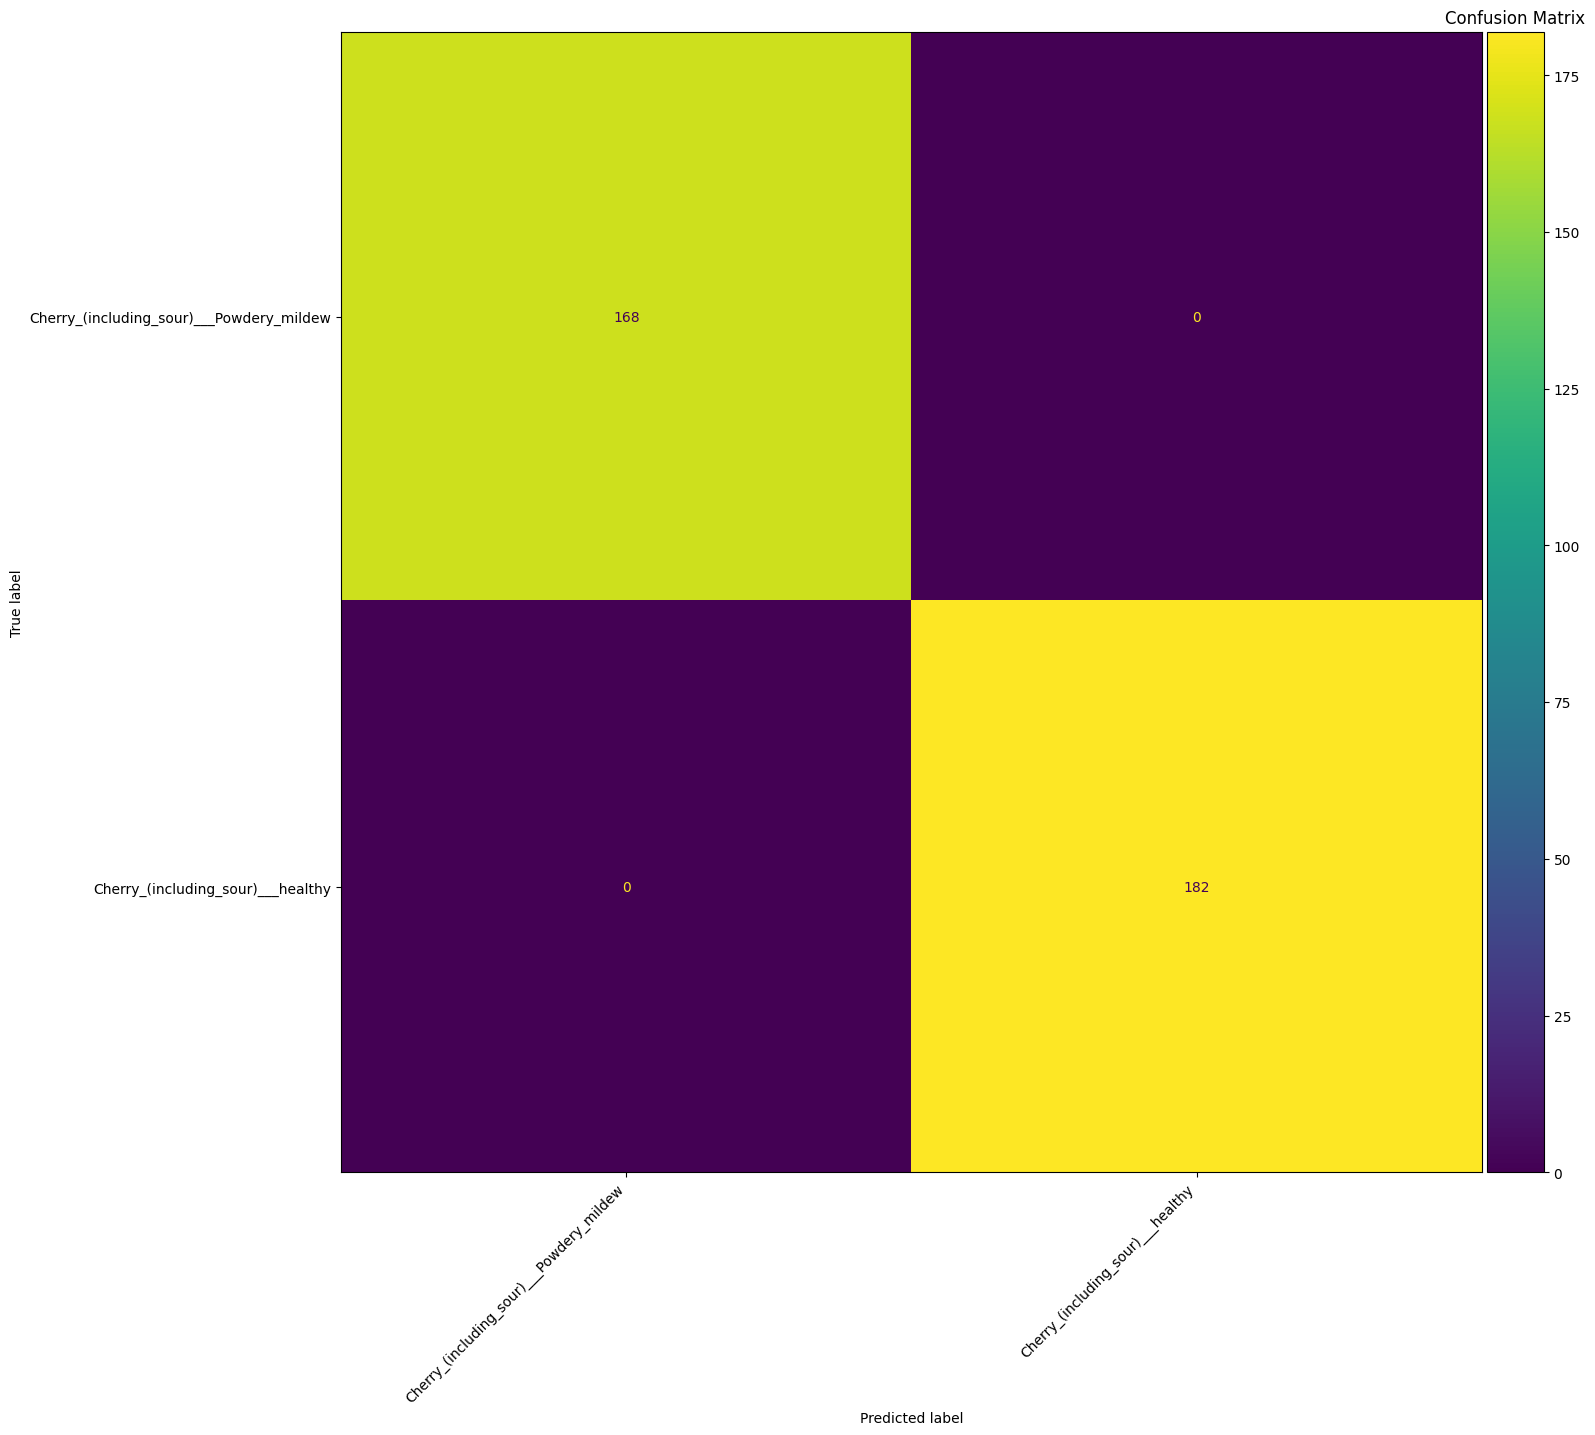

                                      Class   TP  FP   TN  FN  Precision  \
0  Cherry_(including_sour)___Powdery_mildew  168   0  182   0        1.0   
1         Cherry_(including_sour)___healthy  182   0  168   0        1.0   

   Recall  F1-score  Accuracy  
0     1.0       1.0       1.0  
1     1.0       1.0       1.0  


ValueError: Found input variables with inconsistent numbers of samples: [350, 700]

In [13]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Cherry_(including_sour)___Powdery_mildew", f"{sub_test_path}/Cherry_(including_sour)___Powdery_mildew")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Cherry_(including_sour)___healthy", f"{sub_test_path}/Cherry_(including_sour)___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 729
Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Indices: [14, 15, 16, 17]
Classification Report:

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.98      0.98       164
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       190
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.98      0.98       190
                            Corn_(maize)___healthy       1.00      1.00      1.00       185

                                          accuracy                           0.99       729
                                         macro a

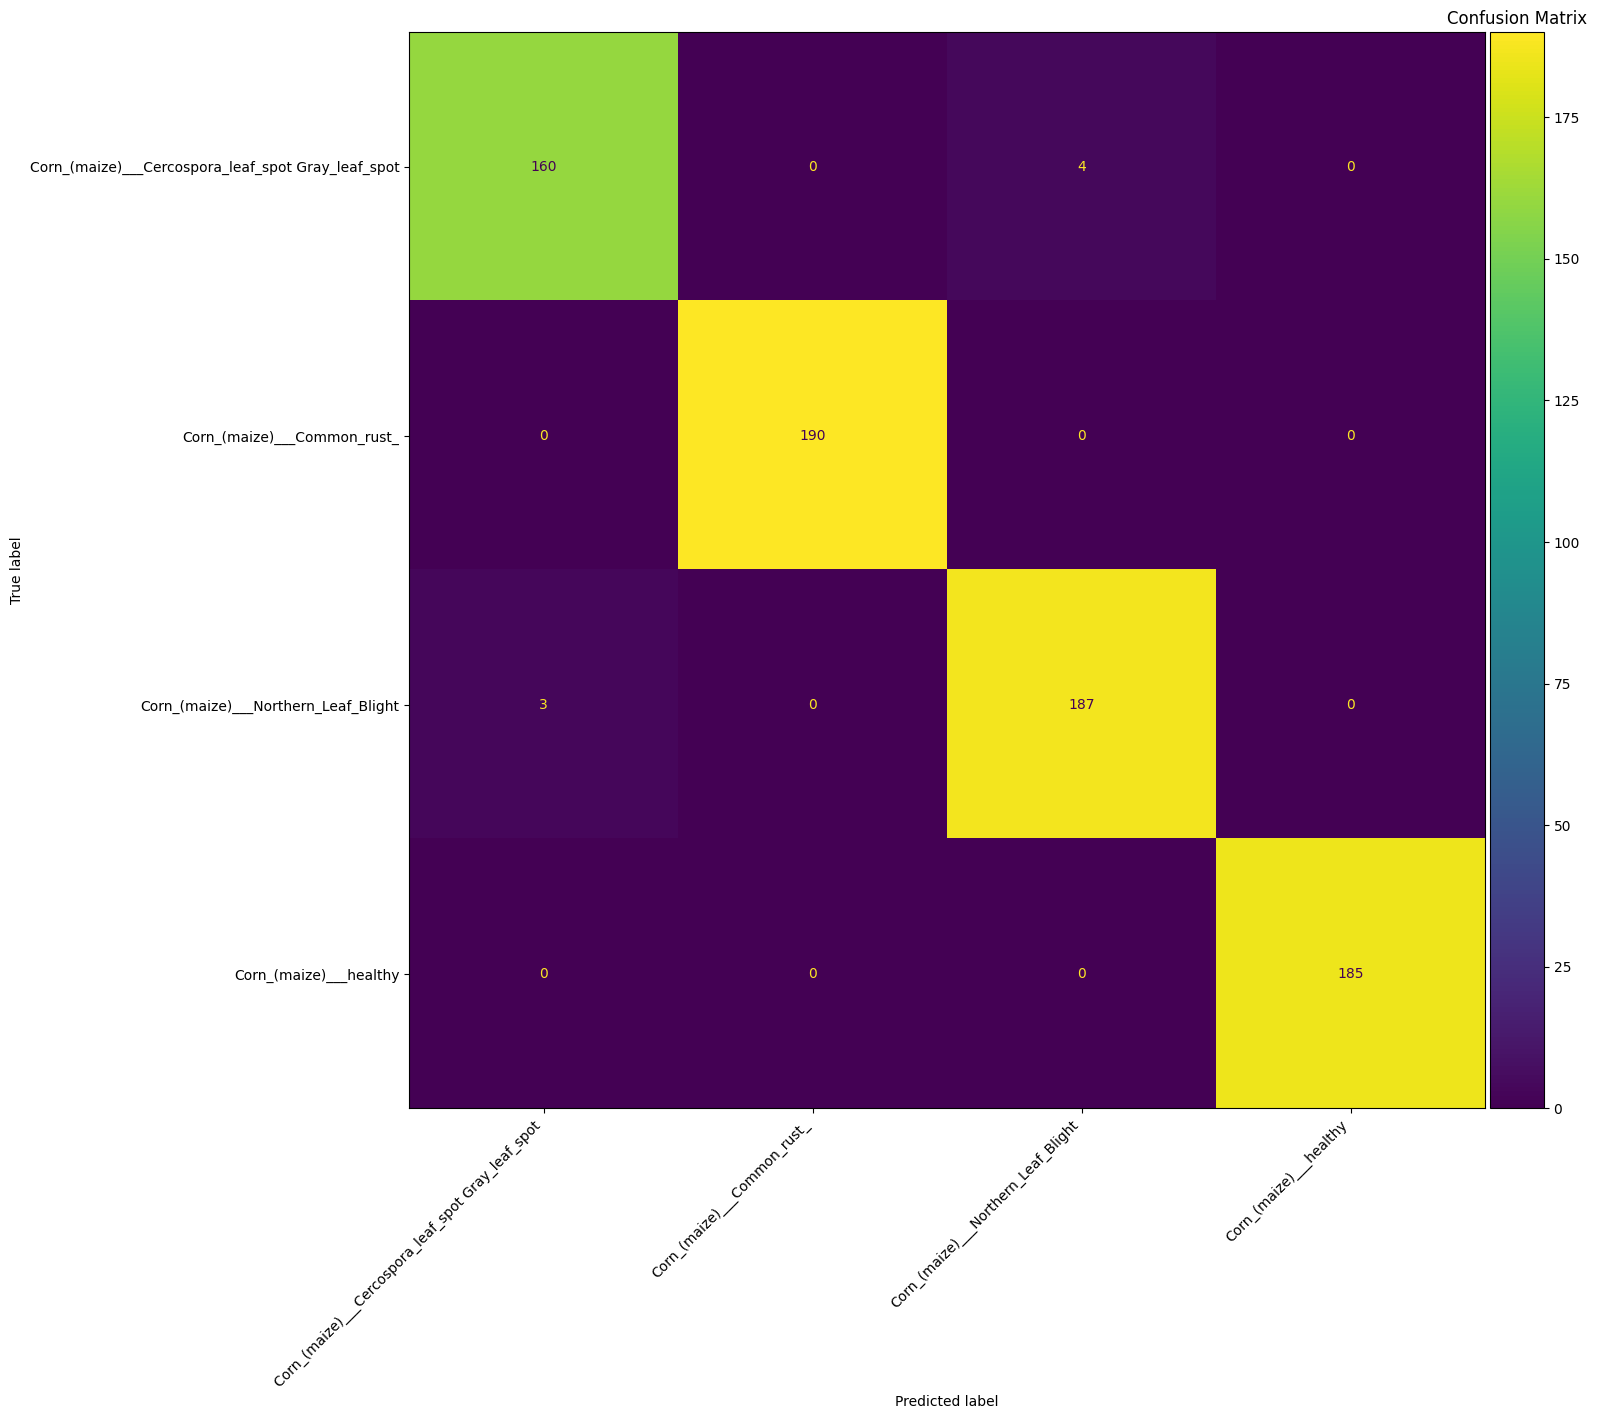

                                               Class   TP  FP   TN  FN  \
0  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...  160   3  562   4   
1                        Corn_(maize)___Common_rust_  190   0  539   0   
2                Corn_(maize)___Northern_Leaf_Blight  187   4  535   3   
3                             Corn_(maize)___healthy  185   0  544   0   

   Precision    Recall  F1-score  Accuracy  
0   0.981595  0.975610  0.978593  0.990398  
1   1.000000  1.000000  1.000000  1.000000  
2   0.979058  0.984211  0.981627  0.990398  
3   1.000000  1.000000  1.000000  1.000000  


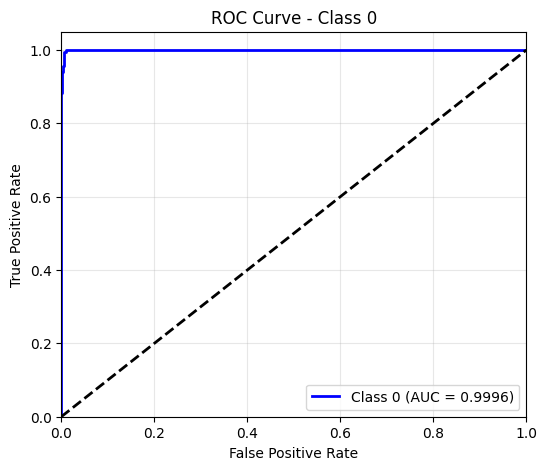

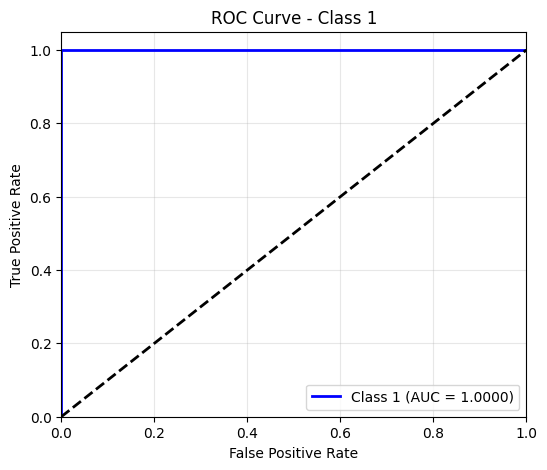

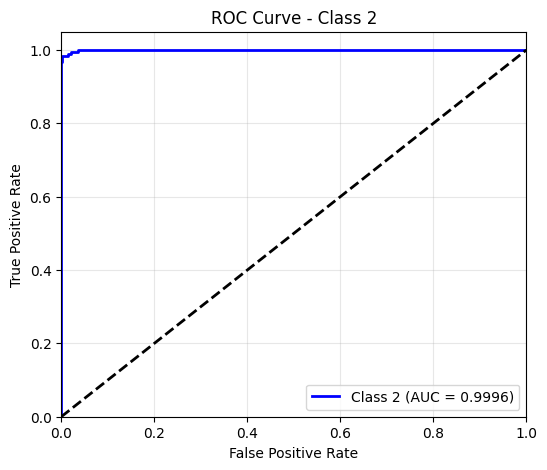

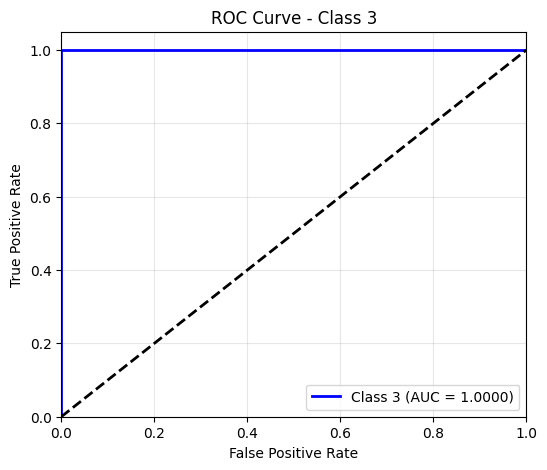

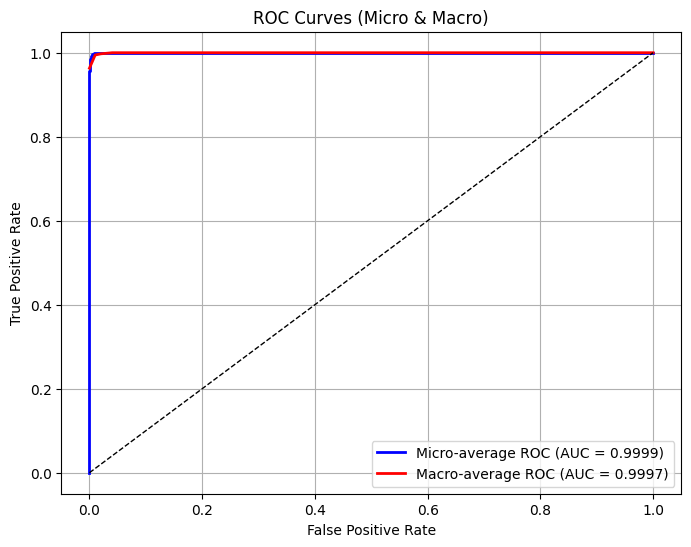

AUC Micro: 0.9999021528259958
AUC Macro: 0.9997187050219785


In [14]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", f"{sub_test_path}/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Corn_(maize)___Common_rust_", f"{sub_test_path}/Corn_(maize)___Common_rust_")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Corn_(maize)___Northern_Leaf_Blight", f"{sub_test_path}/Corn_(maize)___Northern_Leaf_Blight")    
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Corn_(maize)___healthy", f"{sub_test_path}/Corn_(maize)___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 721
Classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
Classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
Indices: [18, 19, 20, 21]
Classification Report:

                                            precision    recall  f1-score   support

                         Grape___Black_rot       1.00      1.00      1.00       188
              Grape___Esca_(Black_Measles)       1.00      1.00      1.00       192
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      1.00      1.00       172
                           Grape___healthy       1.00      1.00      1.00       169

                                  accuracy                           1.00       721
                                 macro avg       1.00      1.00      1.00       721
                              weighted avg       1.00      1.00      1.00   

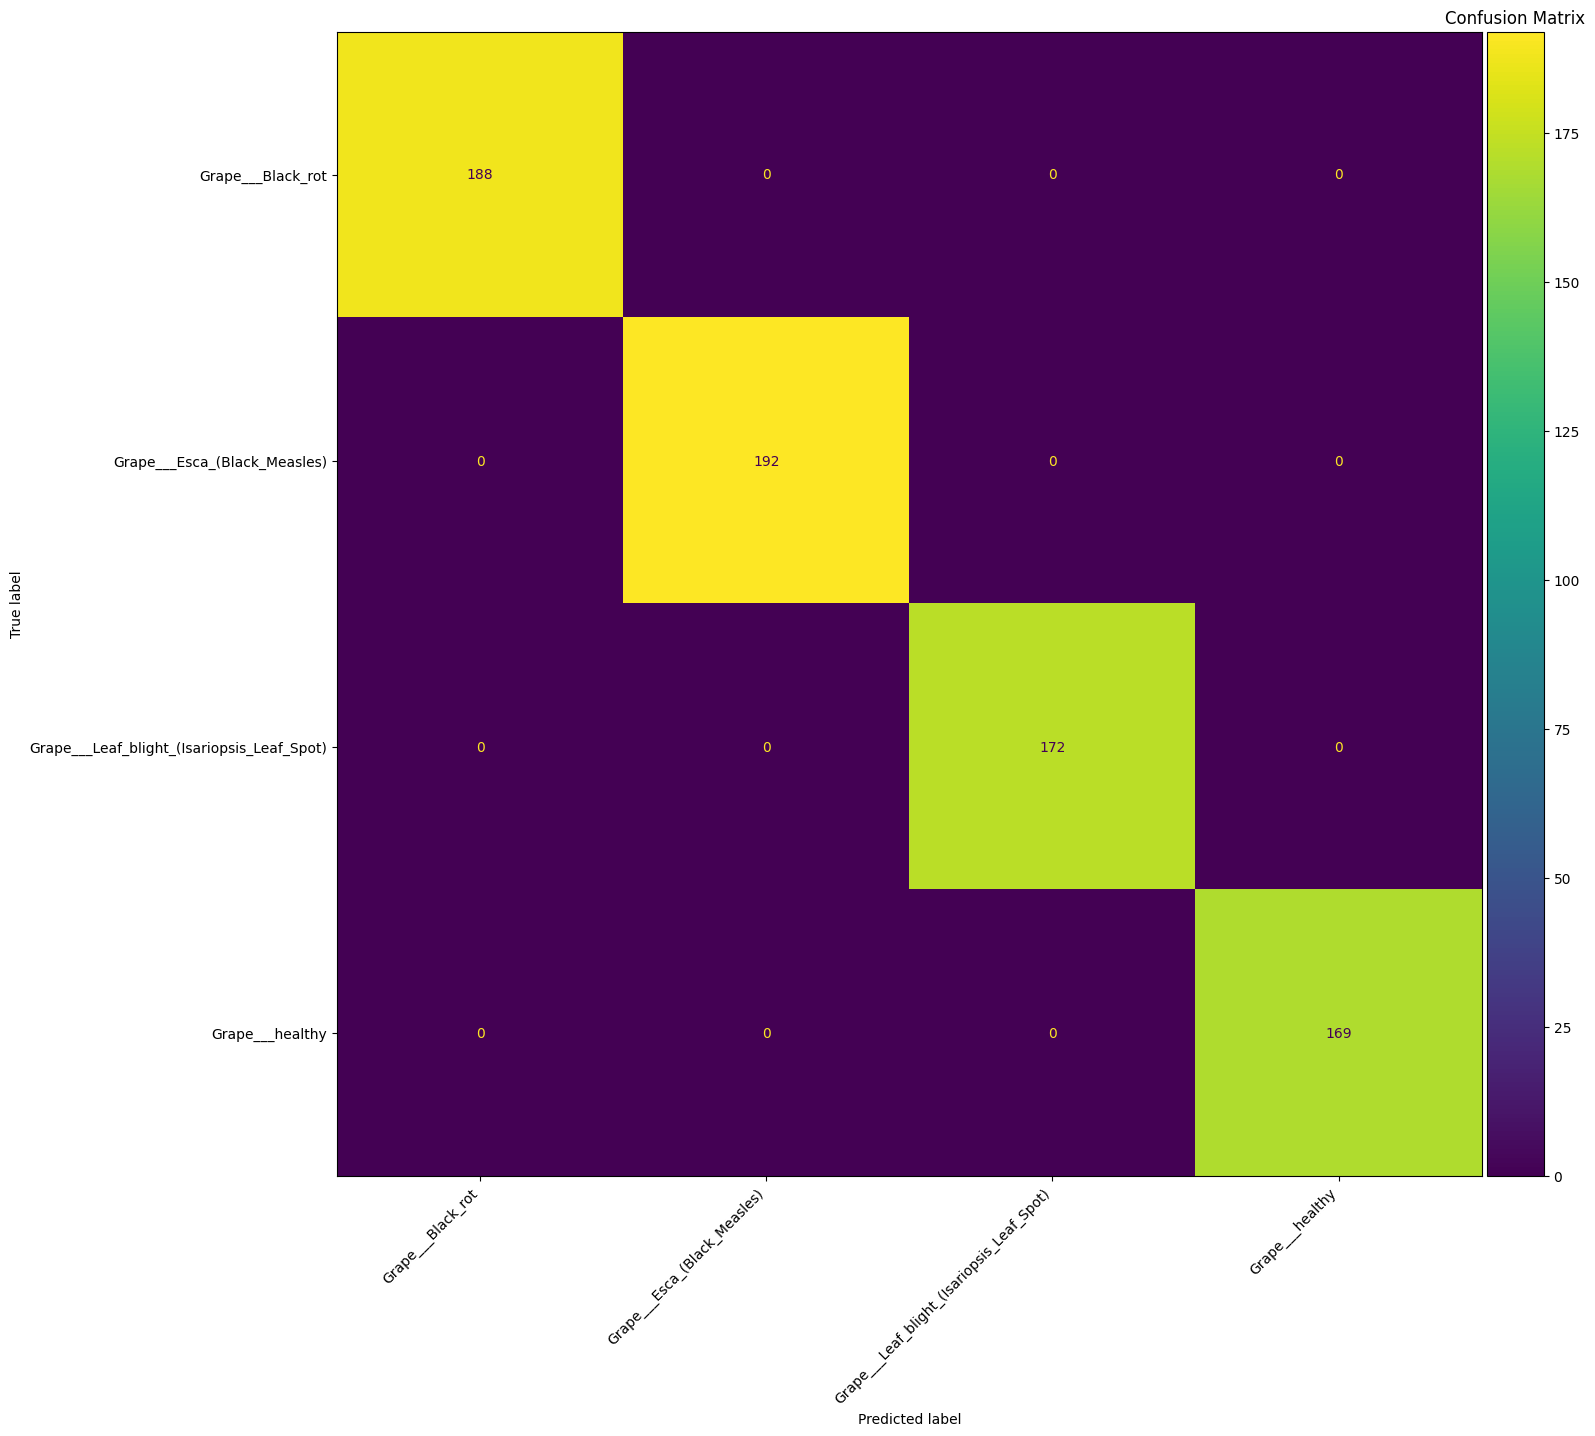

                                        Class   TP  FP   TN  FN  Precision  \
0                           Grape___Black_rot  188   0  533   0        1.0   
1                Grape___Esca_(Black_Measles)  192   0  529   0        1.0   
2  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)  172   0  549   0        1.0   
3                             Grape___healthy  169   0  552   0        1.0   

   Recall  F1-score  Accuracy  
0     1.0       1.0       1.0  
1     1.0       1.0       1.0  
2     1.0       1.0       1.0  
3     1.0       1.0       1.0  


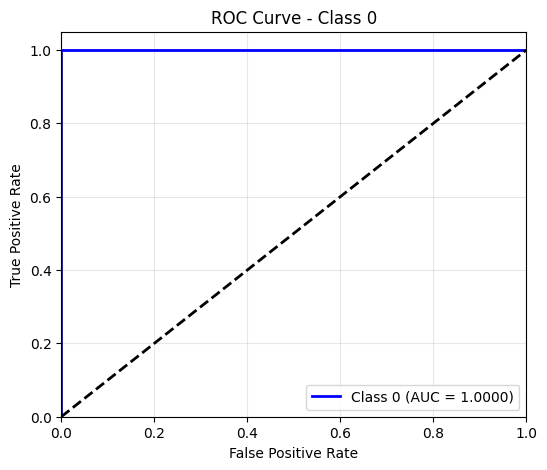

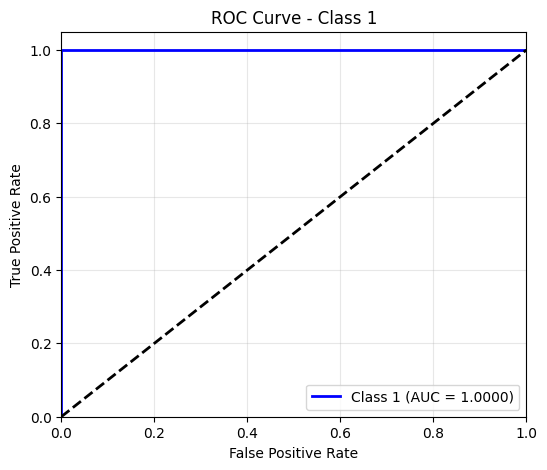

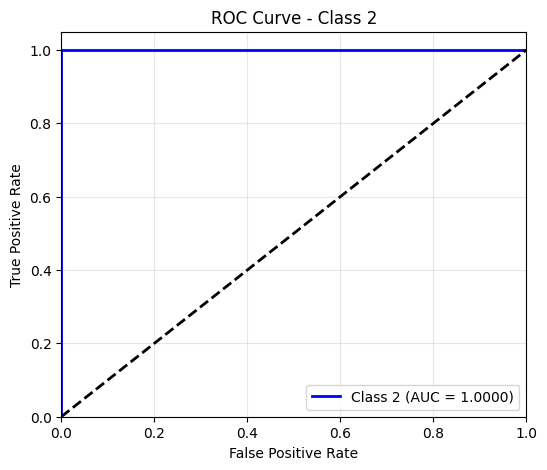

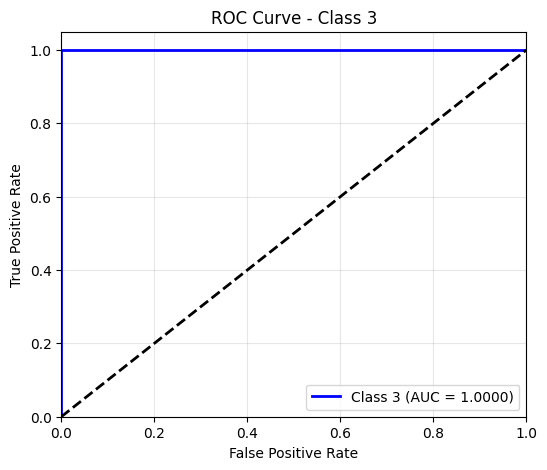

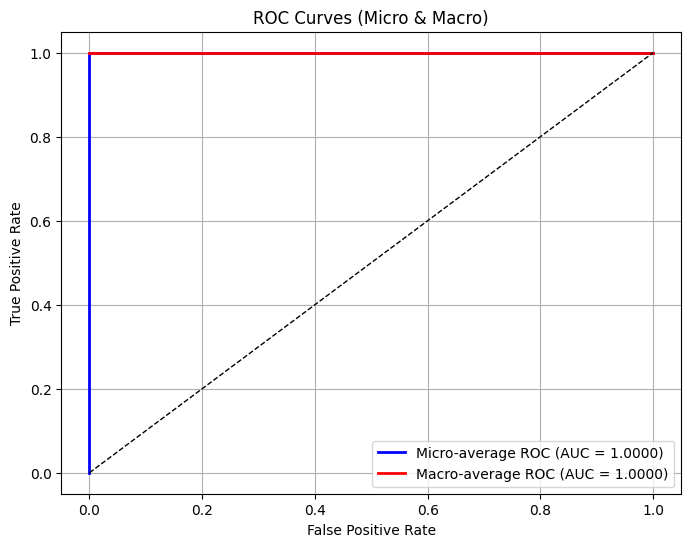

AUC Micro: 1.0
AUC Macro: 1.0


In [15]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Grape___Black_rot", f"{sub_test_path}/Grape___Black_rot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Grape___Esca_(Black_Measles)", f"{sub_test_path}/Grape___Esca_(Black_Measles)")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", f"{sub_test_path}/Grape___Leaf_blight_(Isariopsis_Leaf_Spot)")    
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Grape___healthy", f"{sub_test_path}/Grape___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 201
Classes: ['Orange___Haunglongbing_(Citrus_greening)']
Classes: ['Orange___Haunglongbing_(Citrus_greening)']
Indices: [22]
Classification Report:

                                          precision    recall  f1-score   support

Orange___Haunglongbing_(Citrus_greening)       1.00      1.00      1.00       201

                                accuracy                           1.00       201
                               macro avg       1.00      1.00      1.00       201
                            weighted avg       1.00      1.00      1.00       201



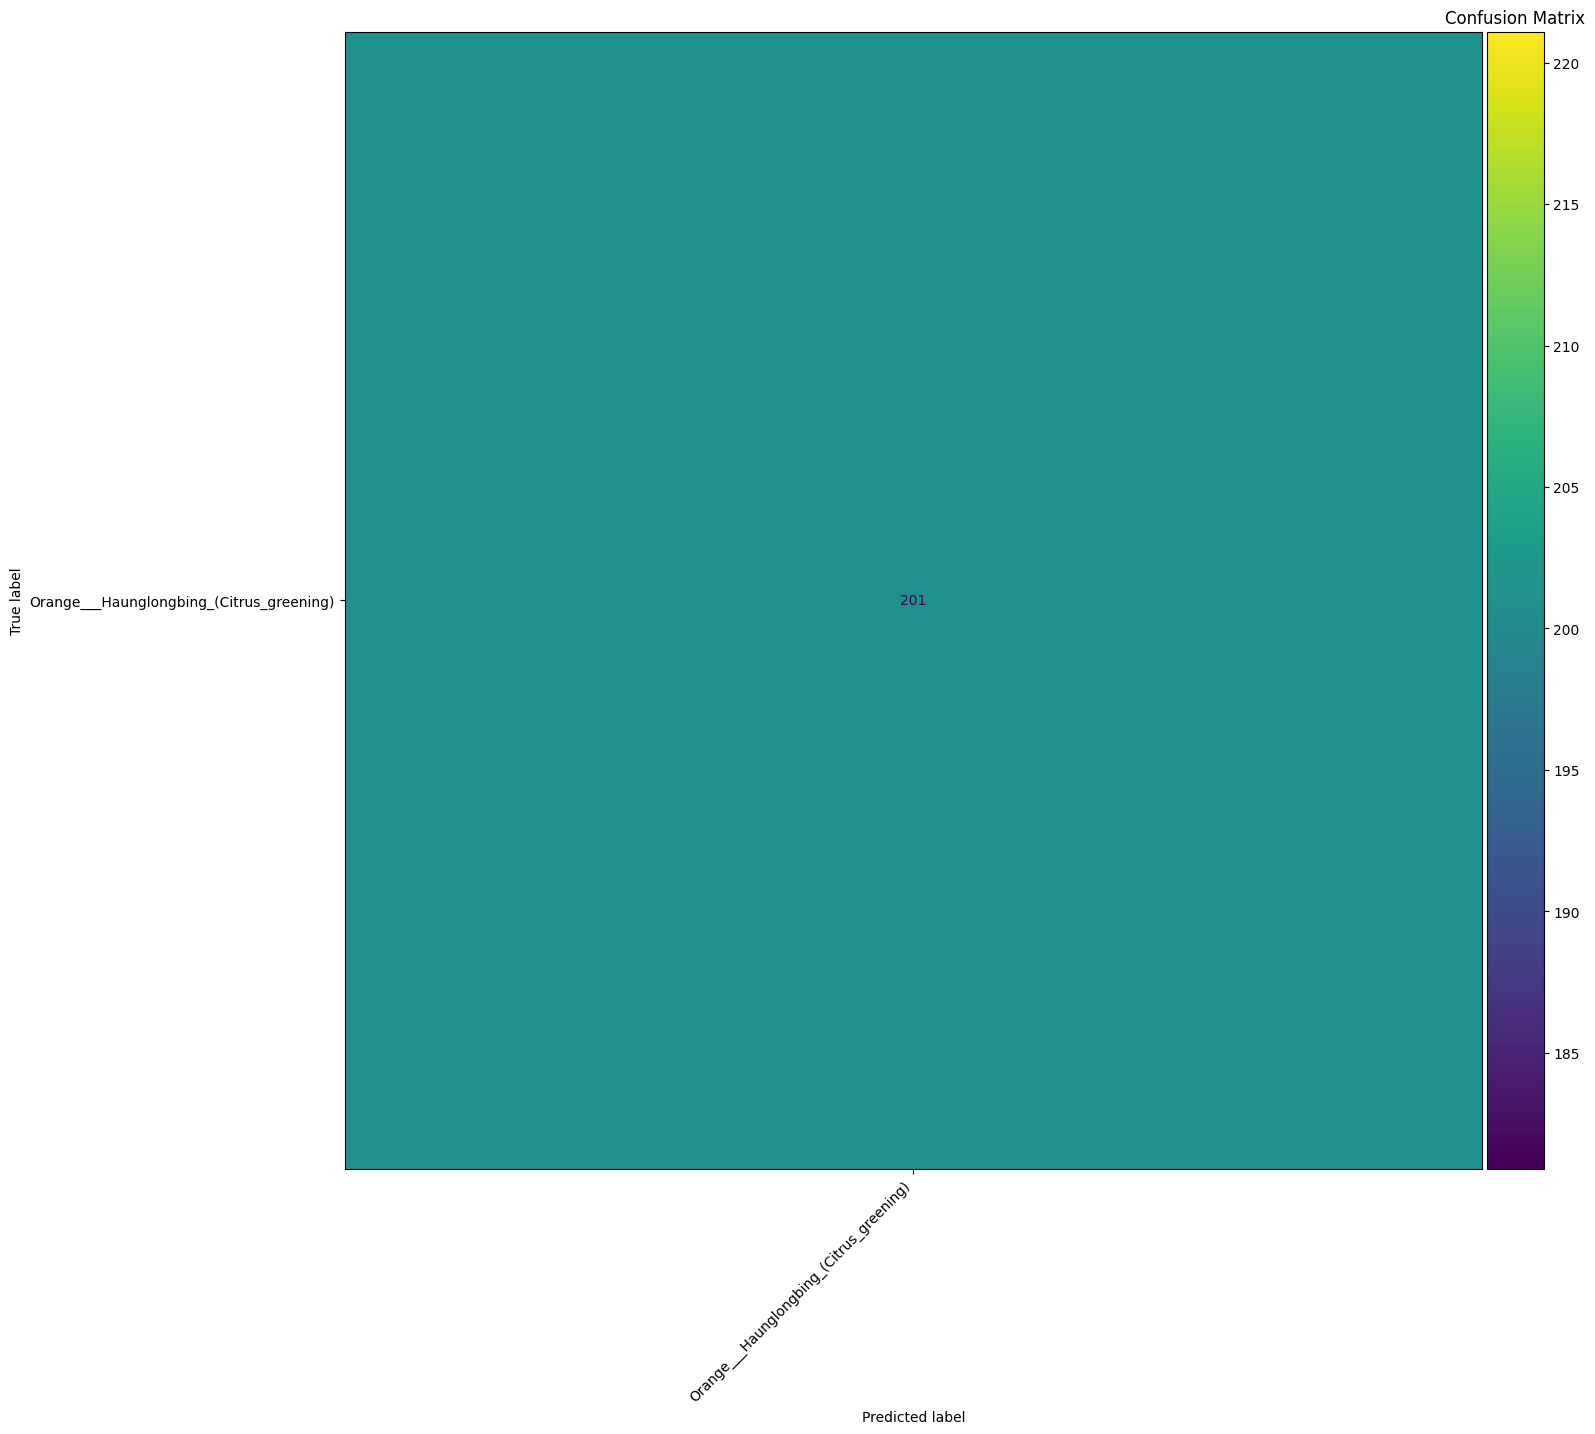

                                      Class   TP  FP  TN  FN  Precision  \
0  Orange___Haunglongbing_(Citrus_greening)  201   0   0   0        1.0   

   Recall  F1-score  Accuracy  
0     1.0       1.0       1.0  


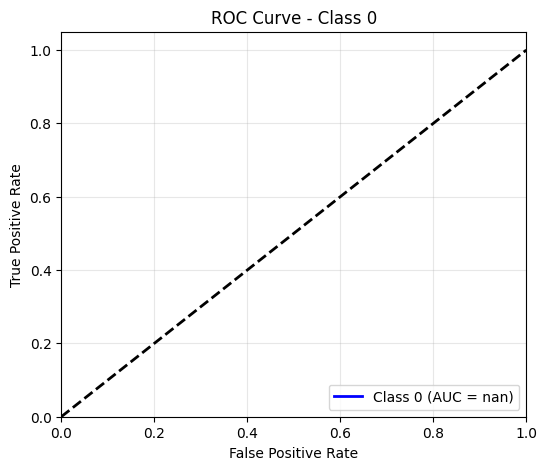

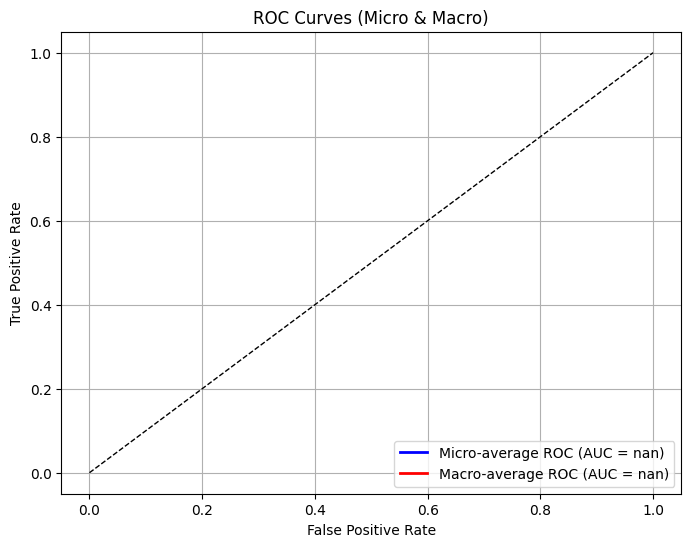

AUC Micro: nan
AUC Macro: nan


In [16]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Orange___Haunglongbing_(Citrus_greening)", f"{sub_test_path}/Orange___Haunglongbing_(Citrus_greening)")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 355
Classes: ['Peach___Bacterial_spot', 'Peach___healthy']
Classes: ['Peach___Bacterial_spot', 'Peach___healthy']
Indices: [23, 24]
Classification Report:

                        precision    recall  f1-score   support

Peach___Bacterial_spot       1.00      1.00      1.00       183
       Peach___healthy       1.00      1.00      1.00       172

              accuracy                           1.00       355
             macro avg       1.00      1.00      1.00       355
          weighted avg       1.00      1.00      1.00       355



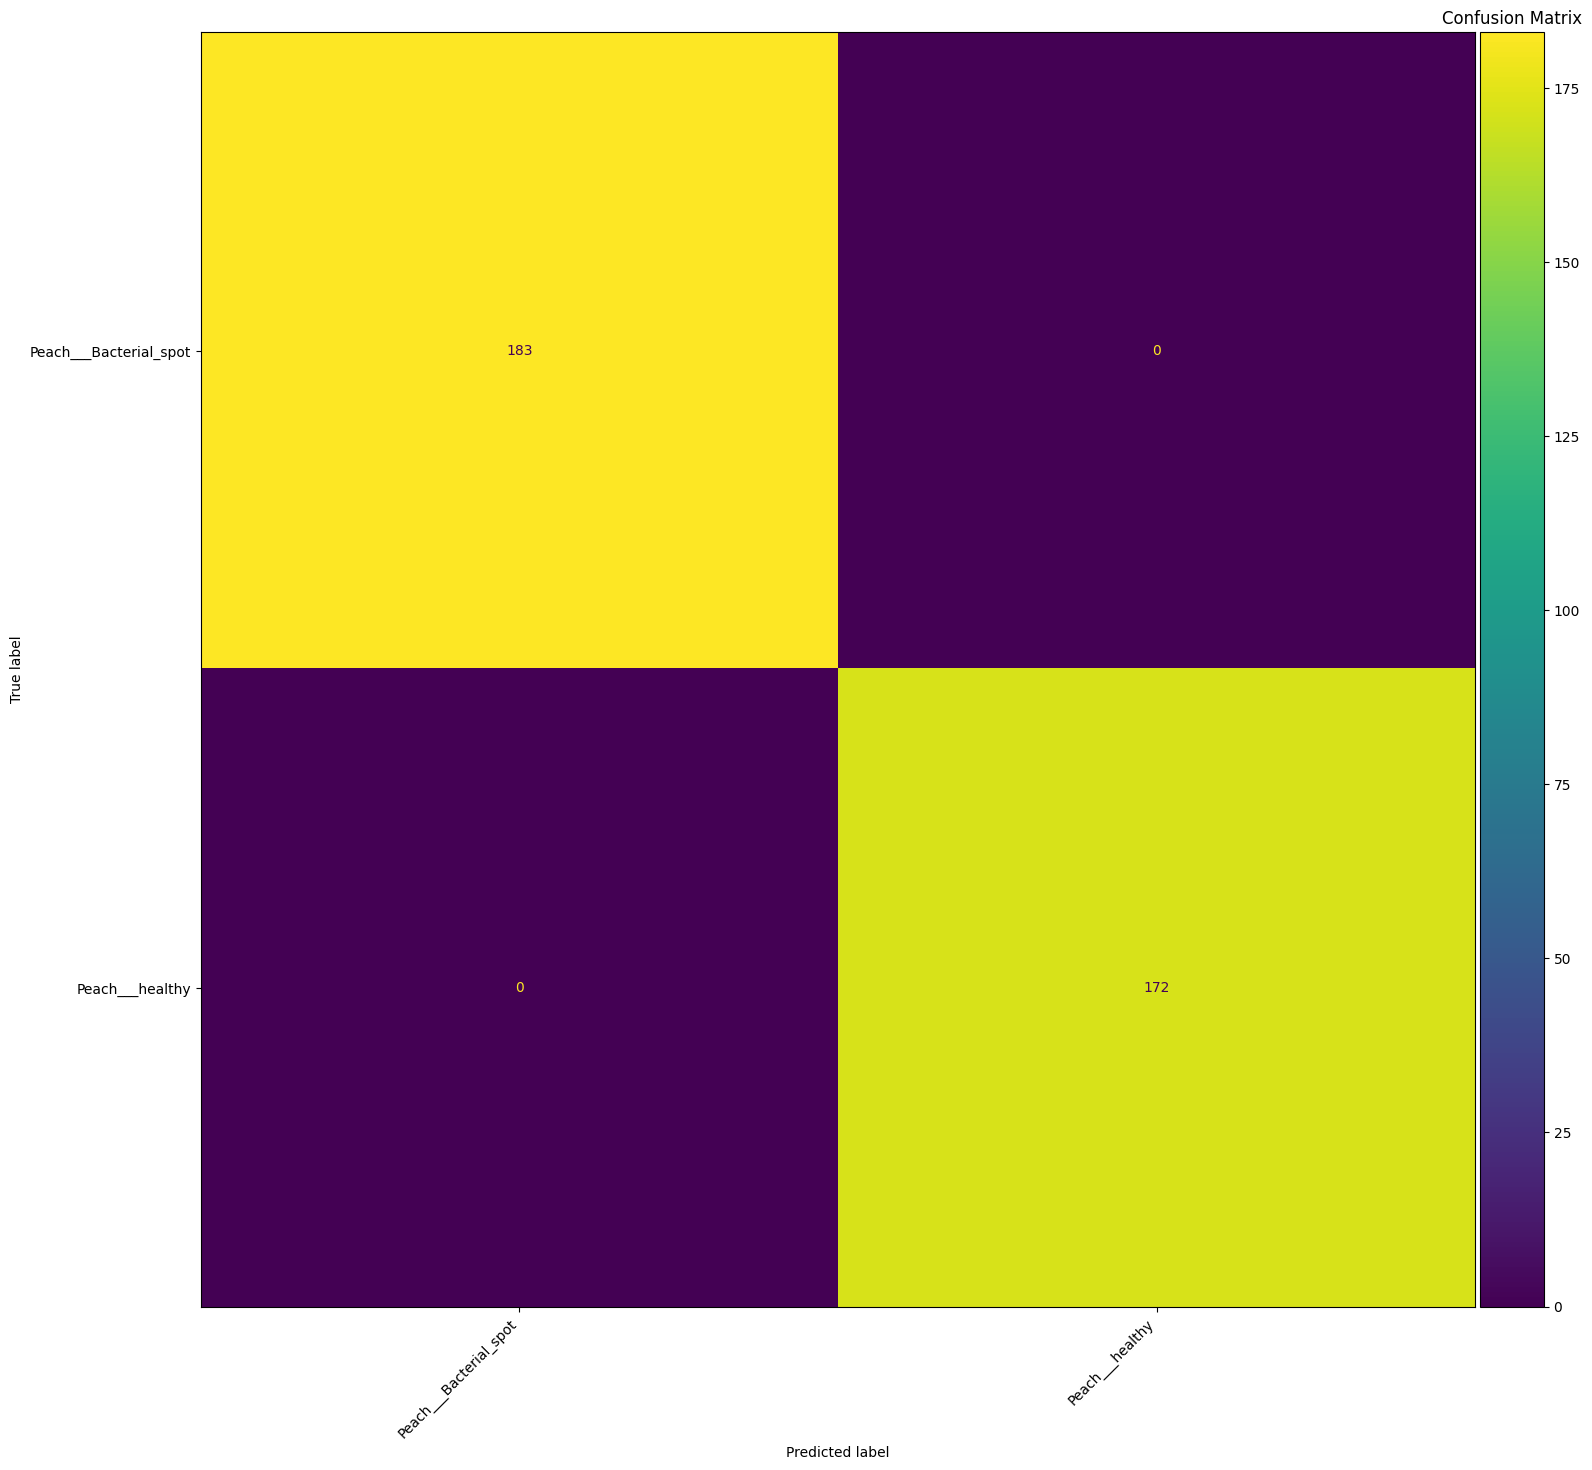

                    Class   TP  FP   TN  FN  Precision  Recall  F1-score  \
0  Peach___Bacterial_spot  183   0  172   0        1.0     1.0       1.0   
1         Peach___healthy  172   0  183   0        1.0     1.0       1.0   

   Accuracy  
0       1.0  
1       1.0  


ValueError: Found input variables with inconsistent numbers of samples: [355, 710]

In [17]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Peach___Bacterial_spot", f"{sub_test_path}/Peach___Bacterial_spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Peach___healthy", f"{sub_test_path}/Peach___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 389
Classes: ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']
Classes: ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']
Indices: [25, 26]
Classification Report:

                               precision    recall  f1-score   support

Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       191
       Pepper,_bell___healthy       1.00      1.00      1.00       198

                     accuracy                           1.00       389
                    macro avg       1.00      1.00      1.00       389
                 weighted avg       1.00      1.00      1.00       389



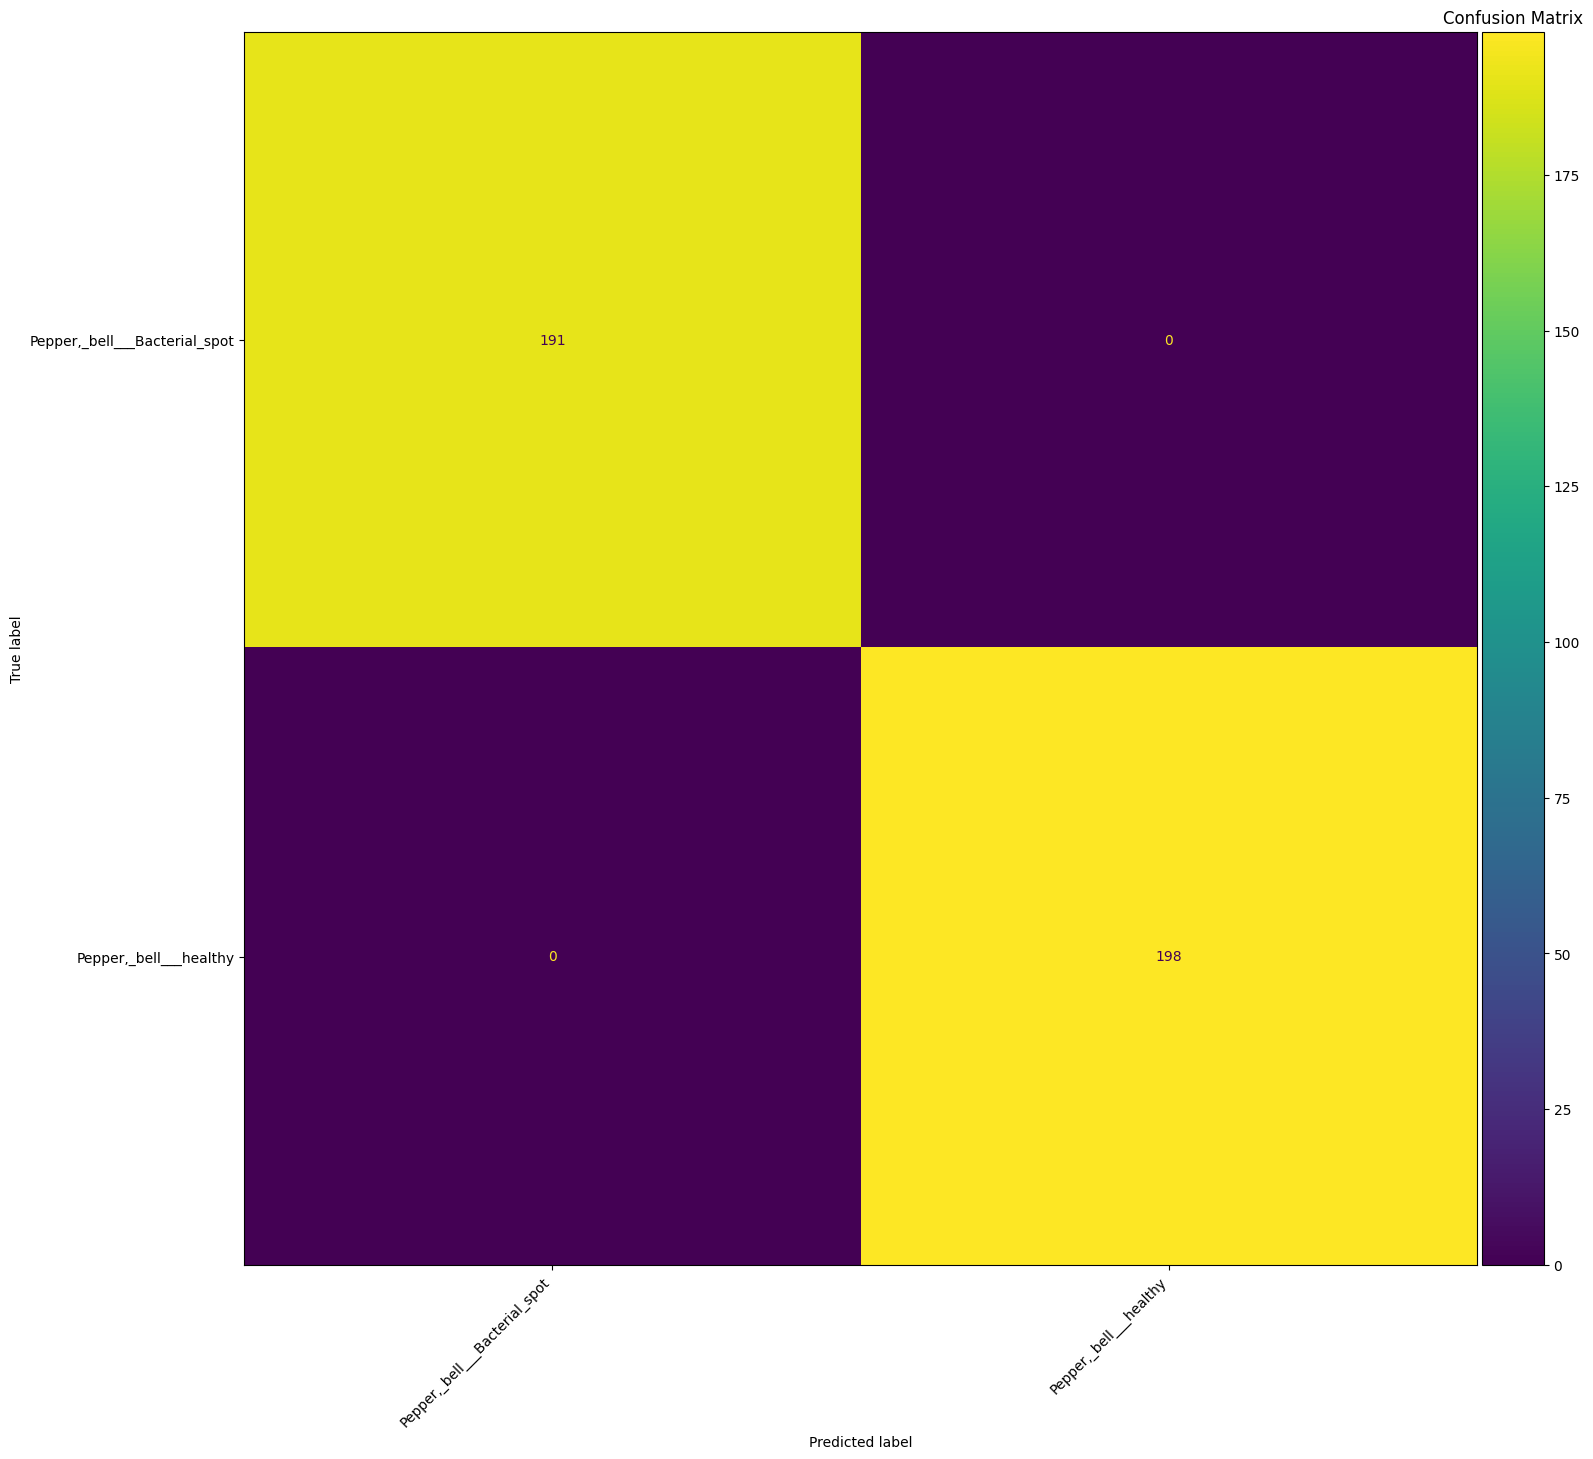

                           Class   TP  FP   TN  FN  Precision  Recall  \
0  Pepper,_bell___Bacterial_spot  191   0  198   0        1.0     1.0   
1         Pepper,_bell___healthy  198   0  191   0        1.0     1.0   

   F1-score  Accuracy  
0       1.0       1.0  
1       1.0       1.0  


ValueError: Found input variables with inconsistent numbers of samples: [389, 778]

In [18]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path):
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Pepper,_bell___Bacterial_spot", f"{sub_test_path}/Pepper,_bell___Bacterial_spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Pepper,_bell___healthy", f"{sub_test_path}/Pepper,_bell___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 568
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Indices: [27, 28, 29]
Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       193
 Potato___Late_blight       0.99      1.00      1.00       193
     Potato___healthy       1.00      0.99      1.00       182

             accuracy                           1.00       568
            macro avg       1.00      1.00      1.00       568
         weighted avg       1.00      1.00      1.00       568



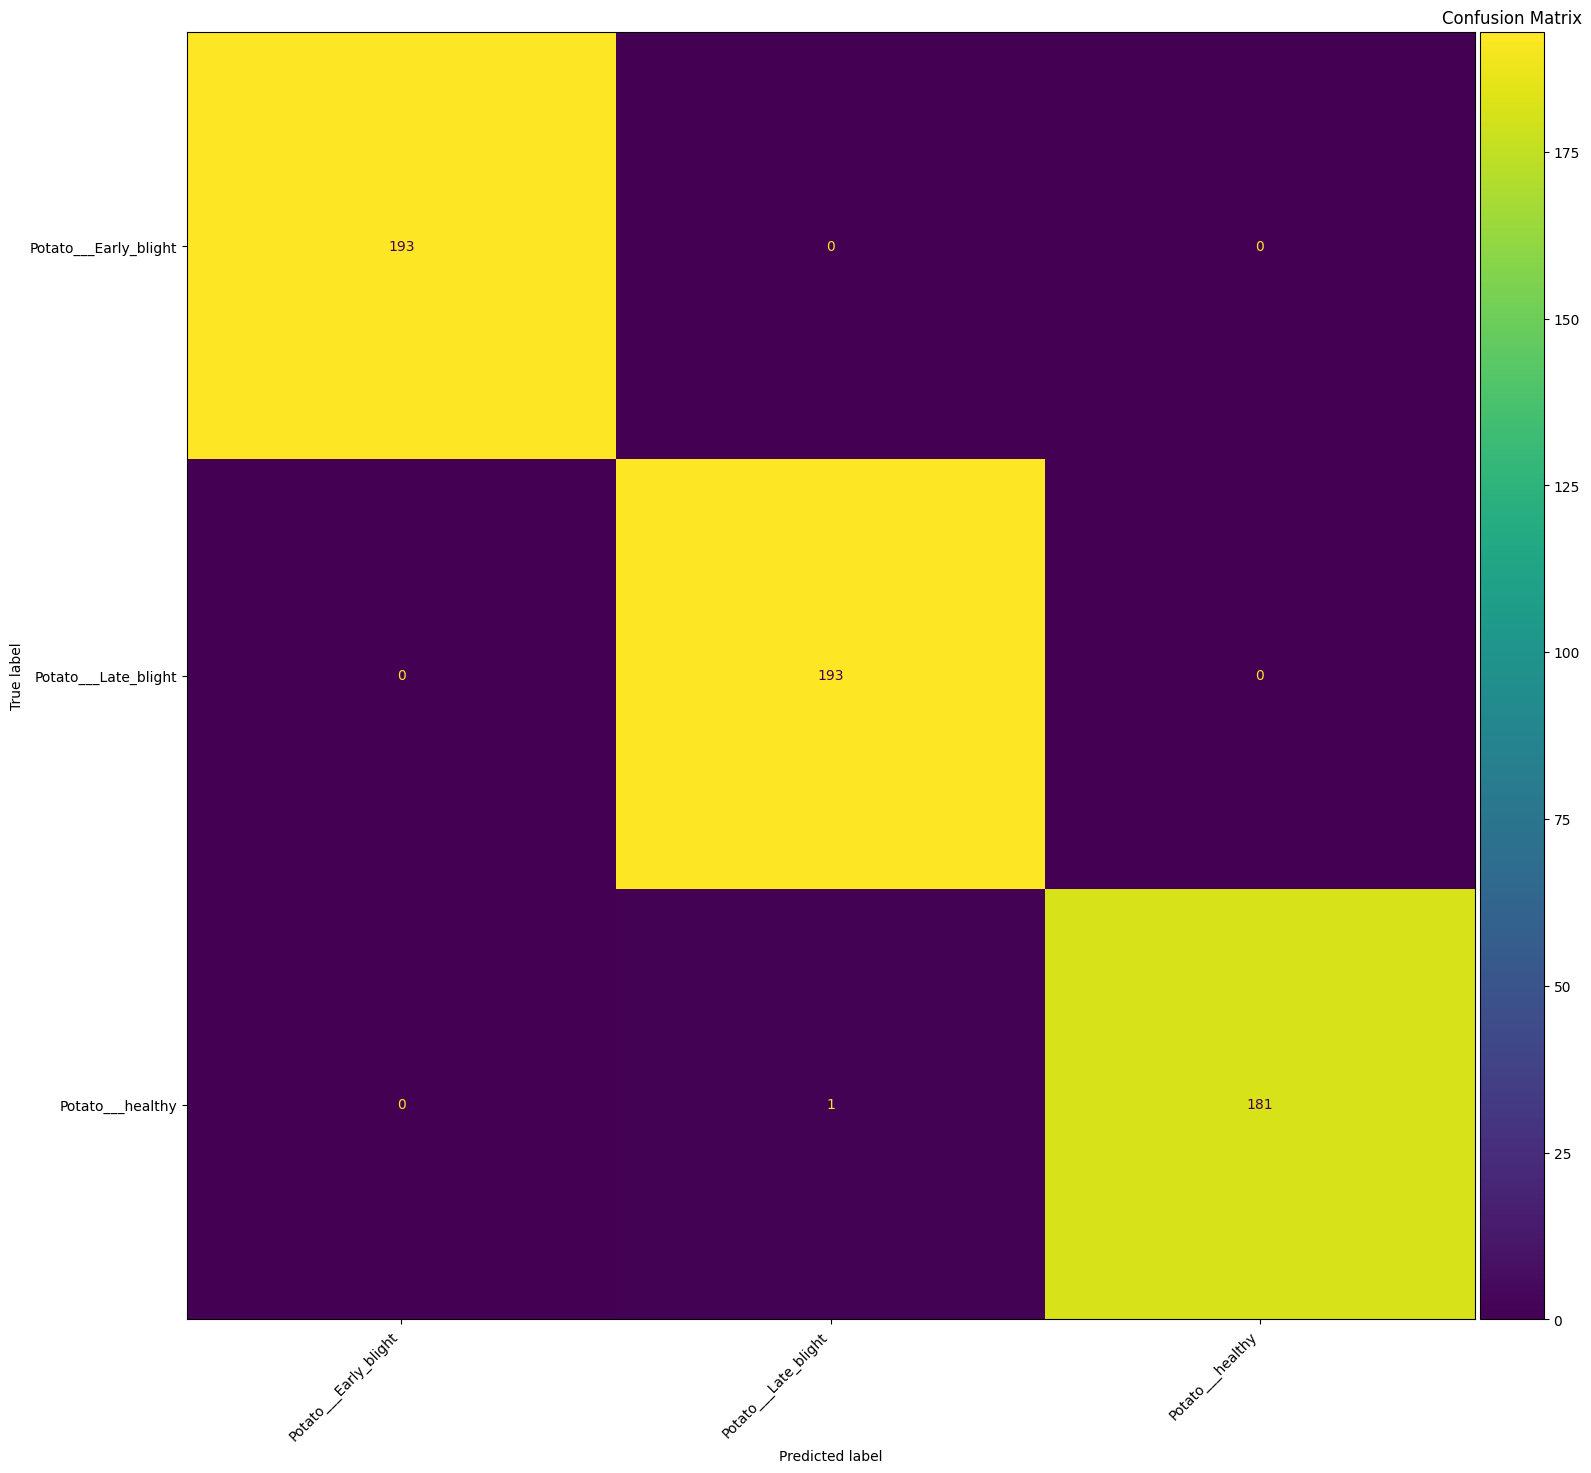

                   Class   TP  FP   TN  FN  Precision    Recall  F1-score  \
0  Potato___Early_blight  193   0  375   0   1.000000  1.000000  1.000000   
1   Potato___Late_blight  193   1  374   0   0.994845  1.000000  0.997416   
2       Potato___healthy  181   0  386   1   1.000000  0.994505  0.997245   

   Accuracy  
0  1.000000  
1  0.998239  
2  0.998239  


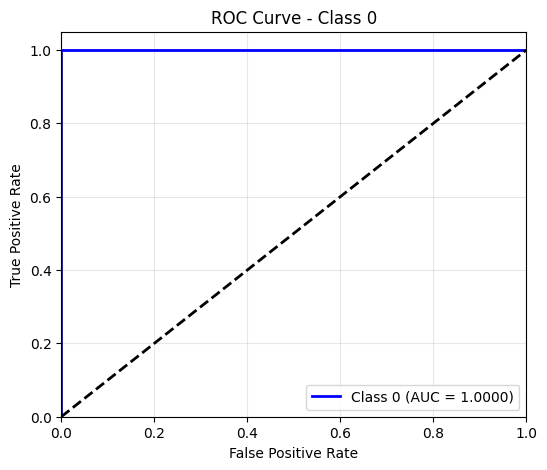

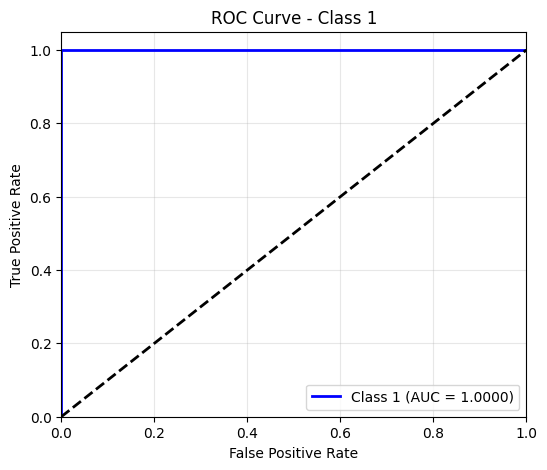

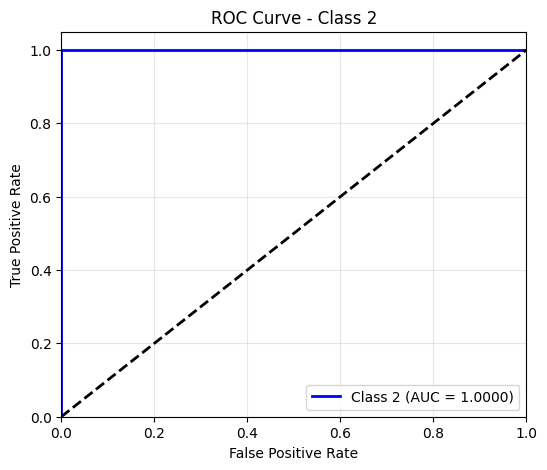

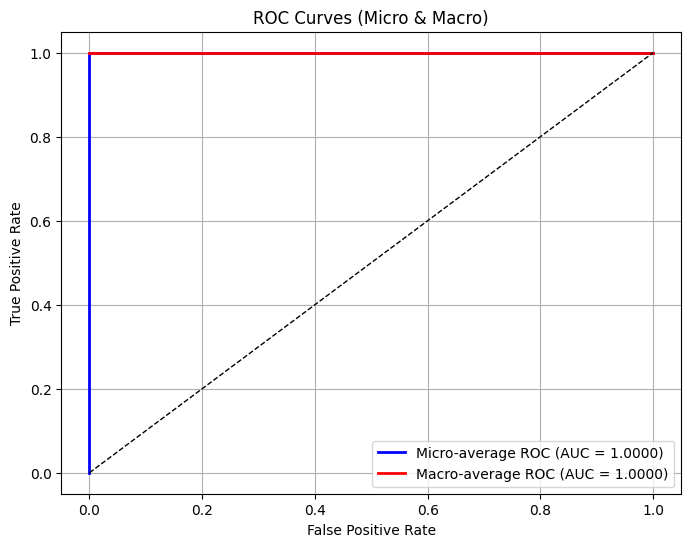

AUC Micro: 0.999998450208292
AUC Macro: 1.0


In [19]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Potato___Early_blight", f"{sub_test_path}/Potato___Early_blight")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Potato___Late_blight", f"{sub_test_path}/Potato___Late_blight")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Potato___healthy", f"{sub_test_path}/Potato___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 178
Classes: ['Raspberry___healthy']
Classes: ['Raspberry___healthy']
Indices: [30]
Classification Report:

                     precision    recall  f1-score   support

Raspberry___healthy       1.00      1.00      1.00       178

           accuracy                           1.00       178
          macro avg       1.00      1.00      1.00       178
       weighted avg       1.00      1.00      1.00       178



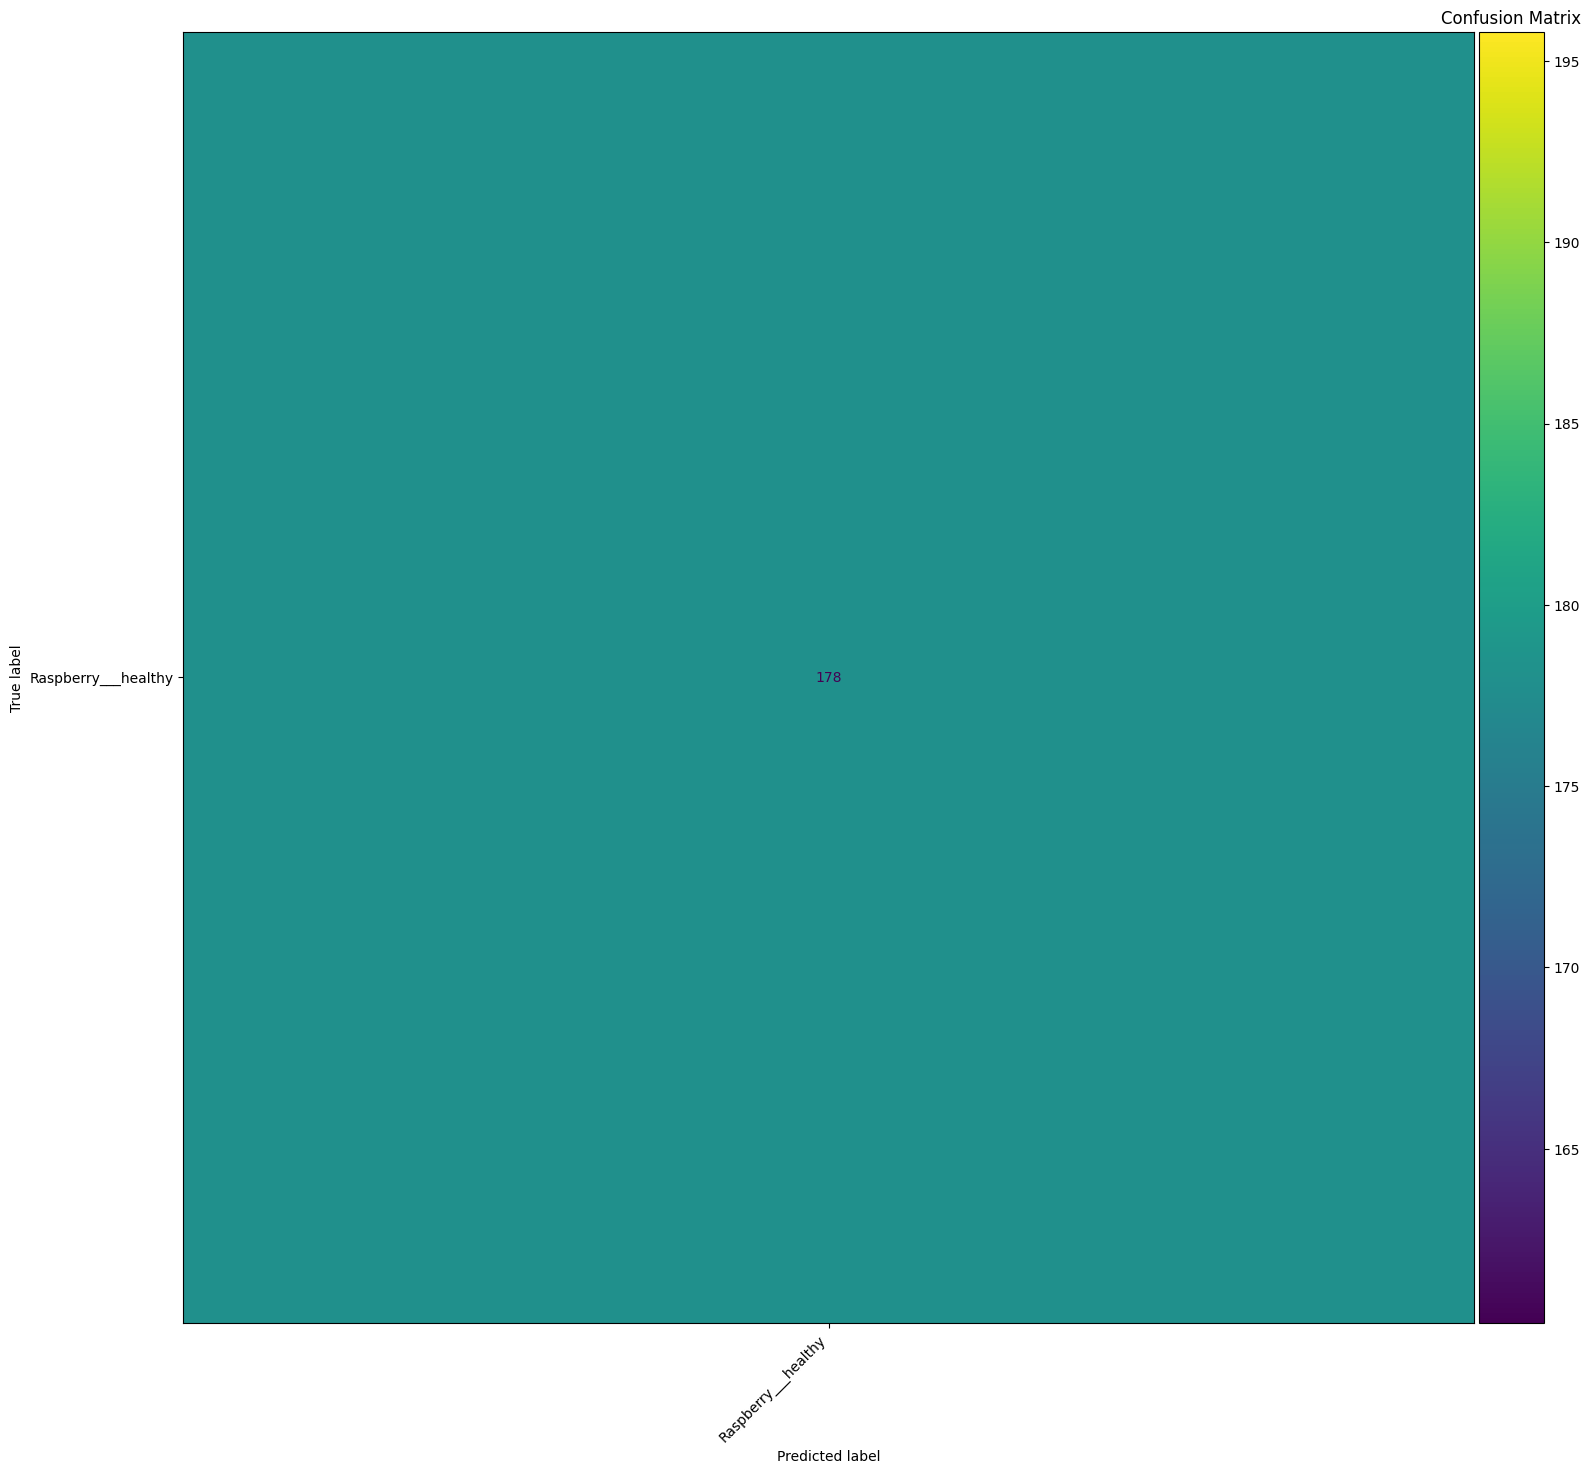

                 Class   TP  FP  TN  FN  Precision  Recall  F1-score  Accuracy
0  Raspberry___healthy  178   0   0   0        1.0     1.0       1.0       1.0


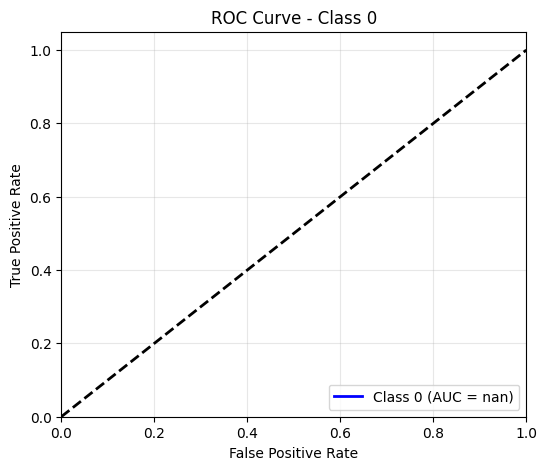

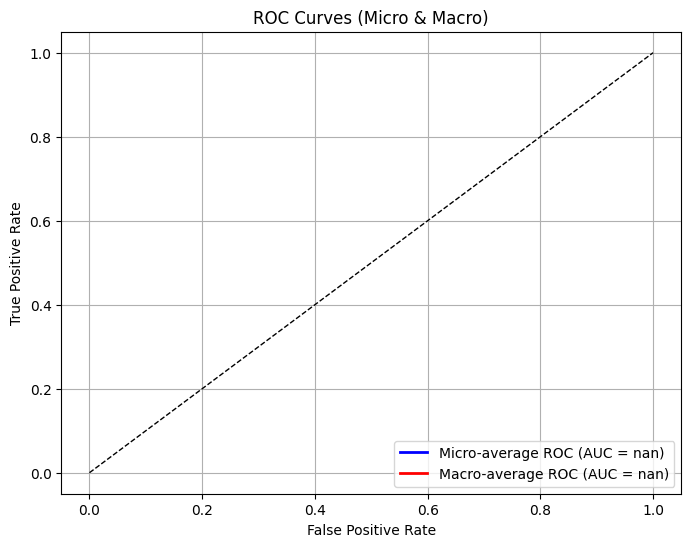

AUC Micro: nan
AUC Macro: nan


In [20]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Raspberry___healthy", f"{sub_test_path}/Raspberry___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 202
Classes: ['Soybean___healthy']
Classes: ['Soybean___healthy']
Indices: [31]
Classification Report:

                   precision    recall  f1-score   support

Soybean___healthy       1.00      1.00      1.00       202

         accuracy                           1.00       202
        macro avg       1.00      1.00      1.00       202
     weighted avg       1.00      1.00      1.00       202



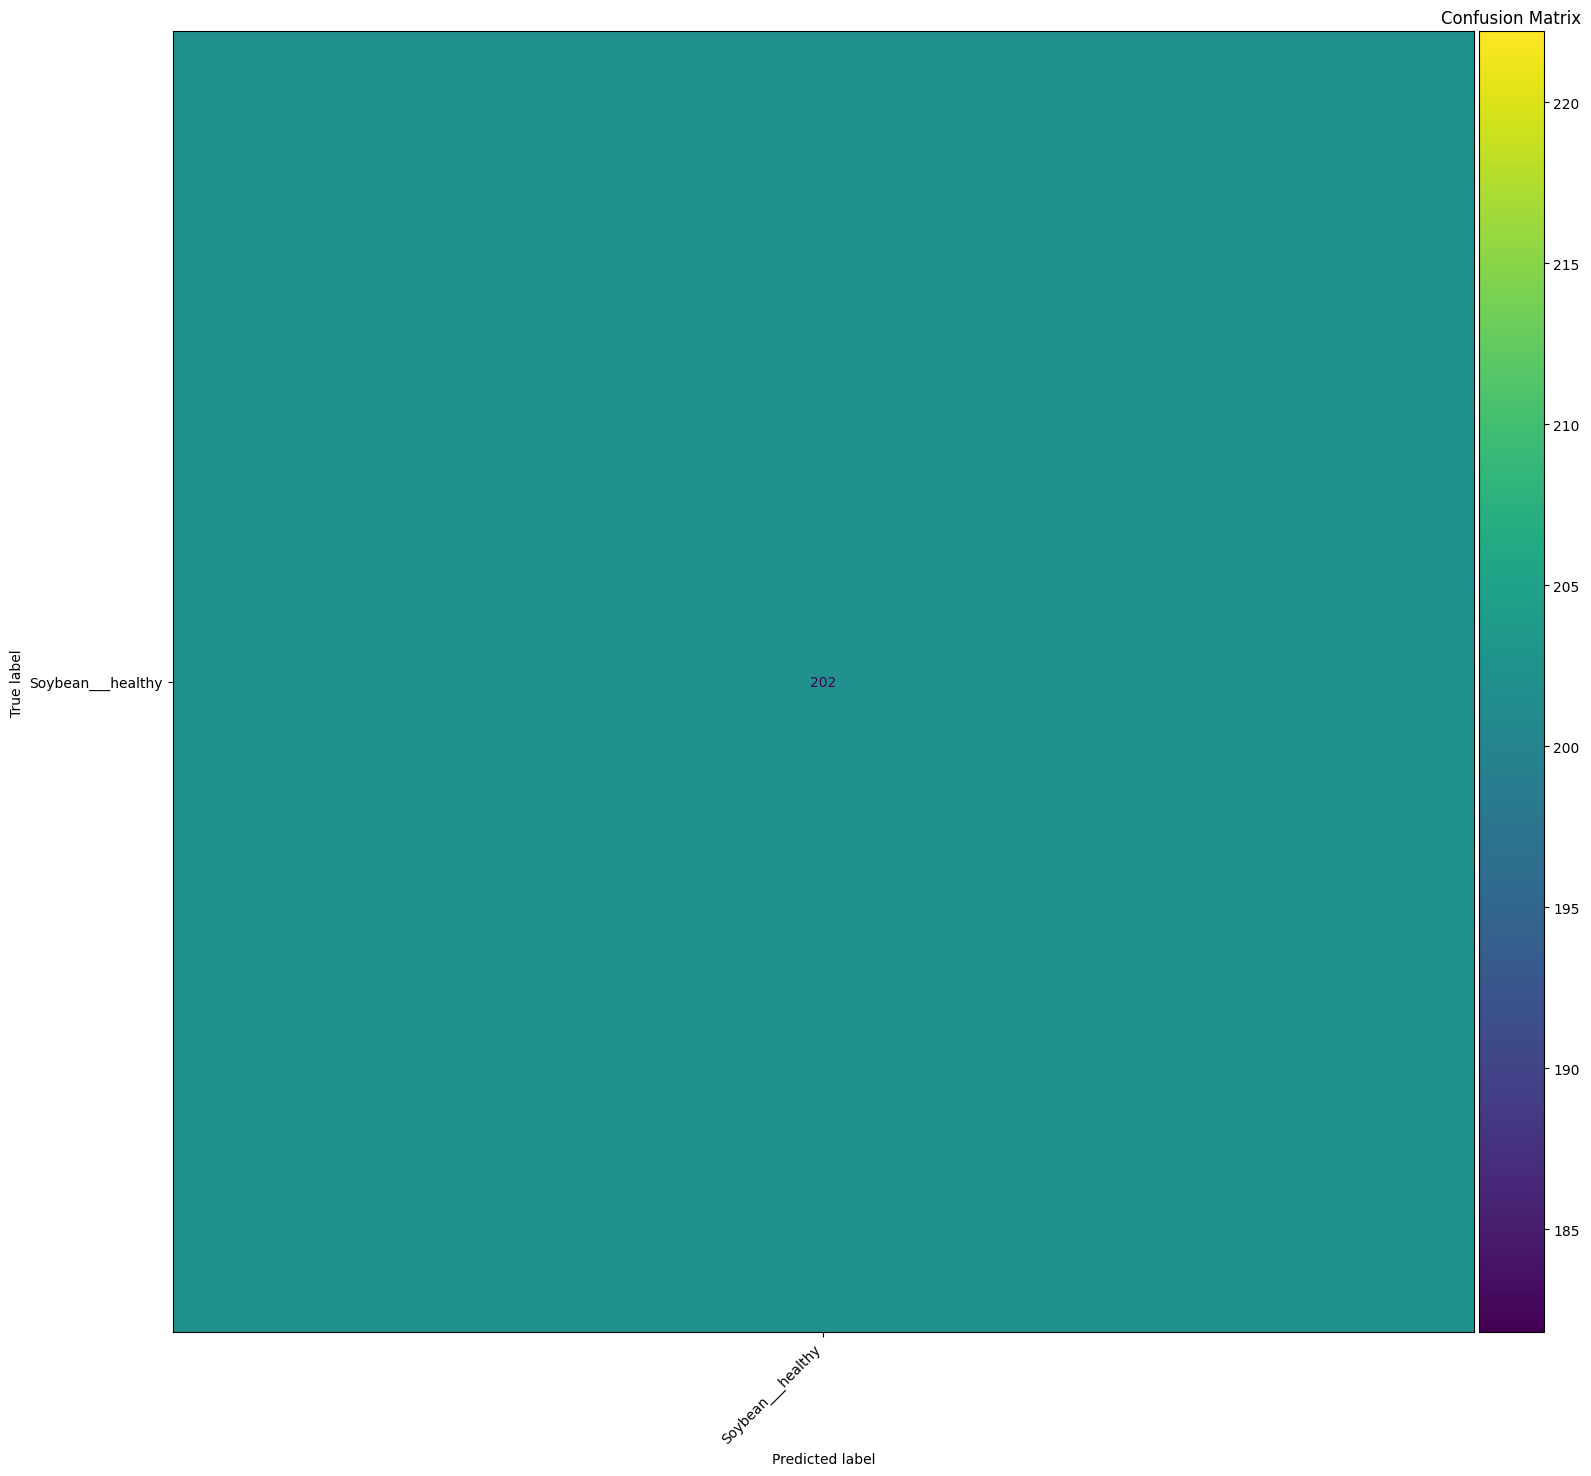

               Class   TP  FP  TN  FN  Precision  Recall  F1-score  Accuracy
0  Soybean___healthy  202   0   0   0        1.0     1.0       1.0       1.0


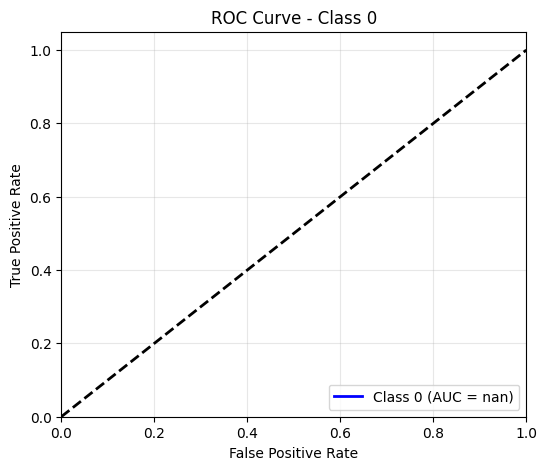

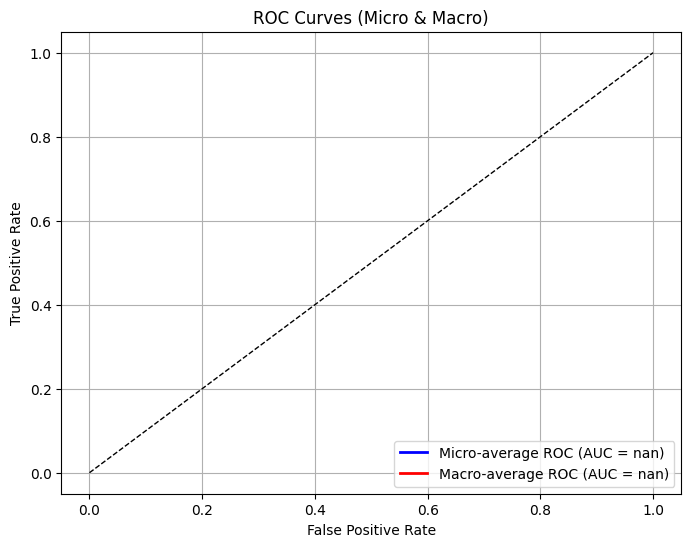

AUC Micro: nan
AUC Macro: nan


In [21]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Soybean___healthy", f"{sub_test_path}/Soybean___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 173
Classes: ['Squash___Powdery_mildew']
Classes: ['Squash___Powdery_mildew']
Indices: [32]
Classification Report:

                         precision    recall  f1-score   support

Squash___Powdery_mildew       1.00      1.00      1.00       173

               accuracy                           1.00       173
              macro avg       1.00      1.00      1.00       173
           weighted avg       1.00      1.00      1.00       173



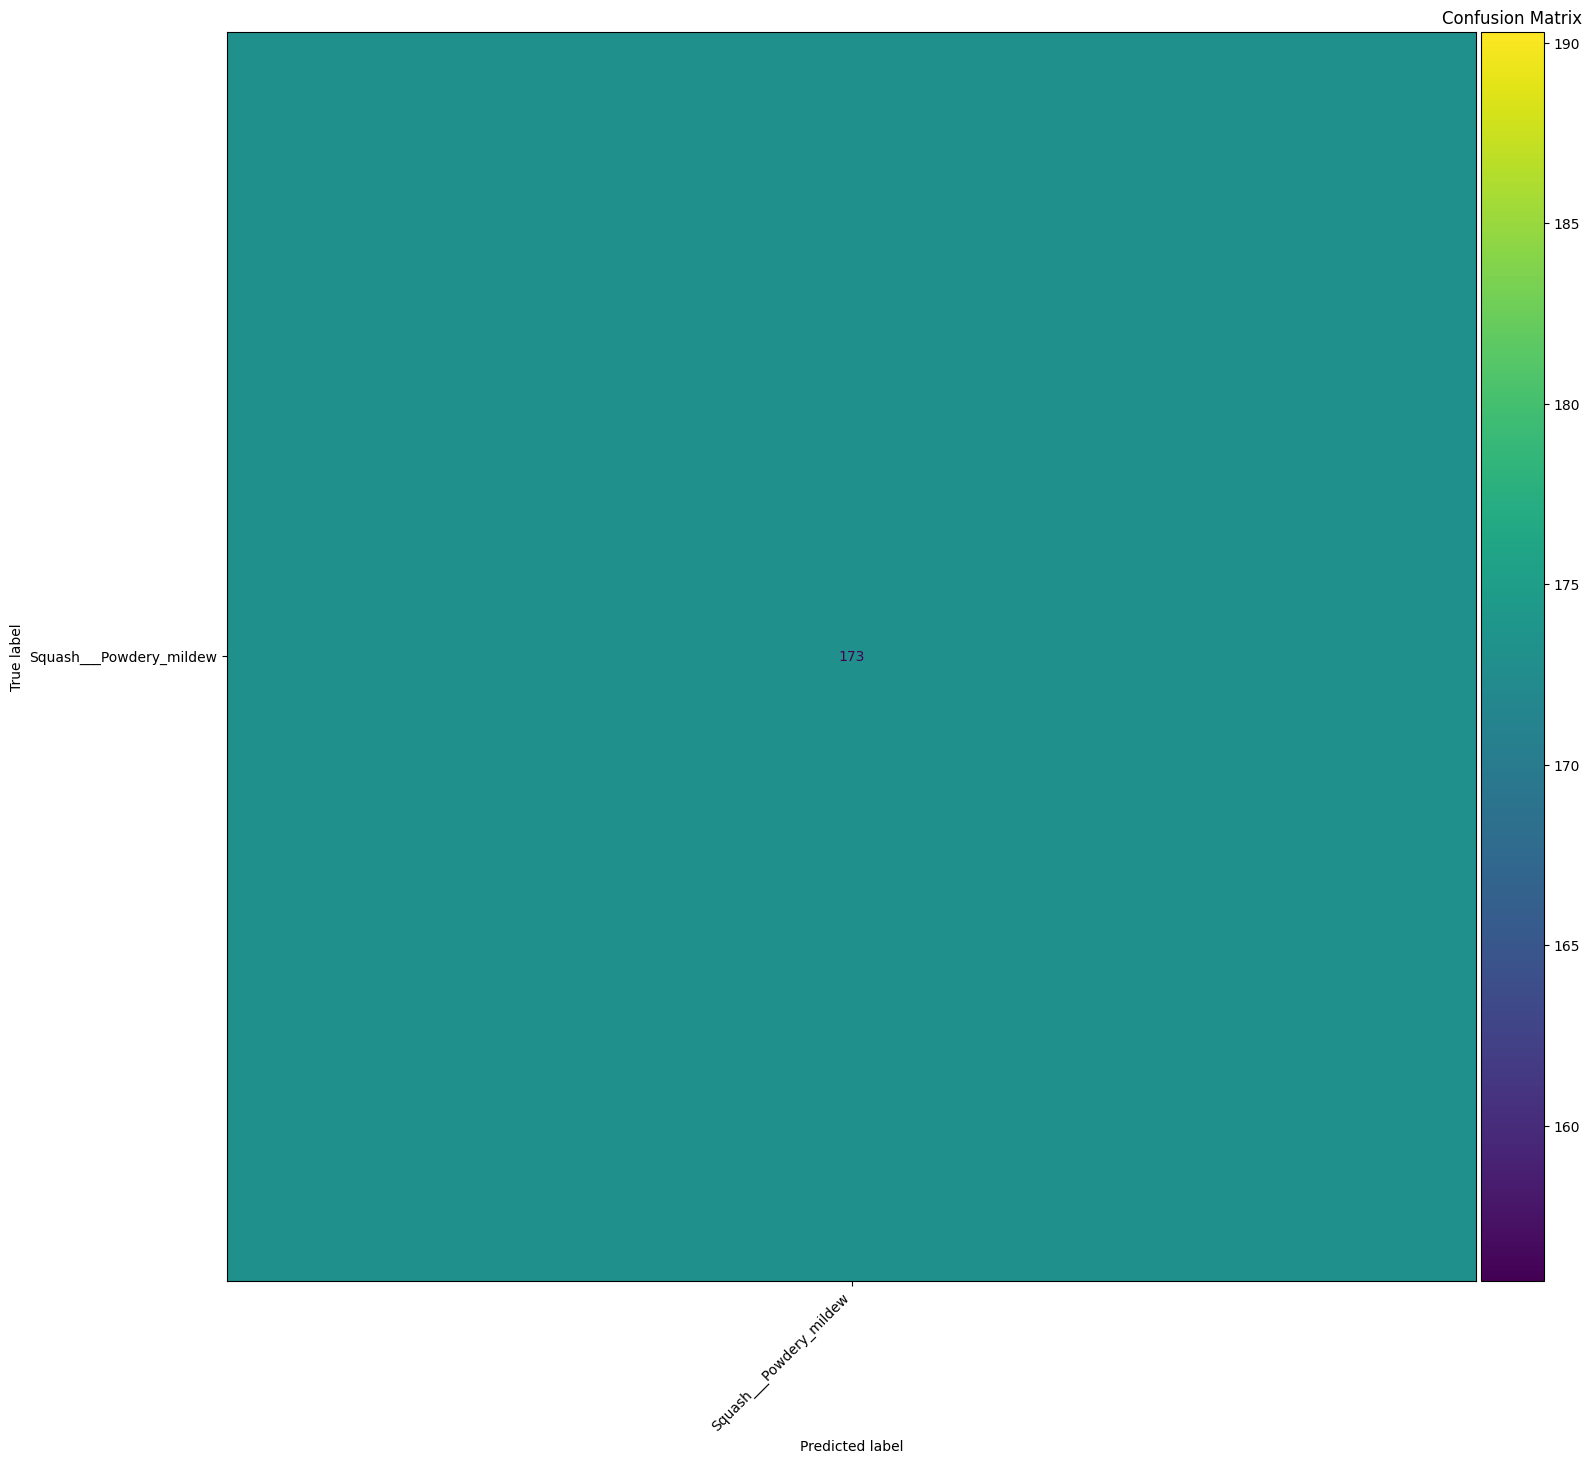

                     Class   TP  FP  TN  FN  Precision  Recall  F1-score  \
0  Squash___Powdery_mildew  173   0   0   0        1.0     1.0       1.0   

   Accuracy  
0       1.0  


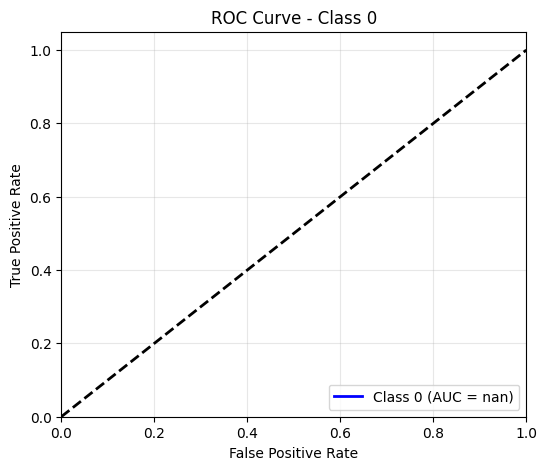

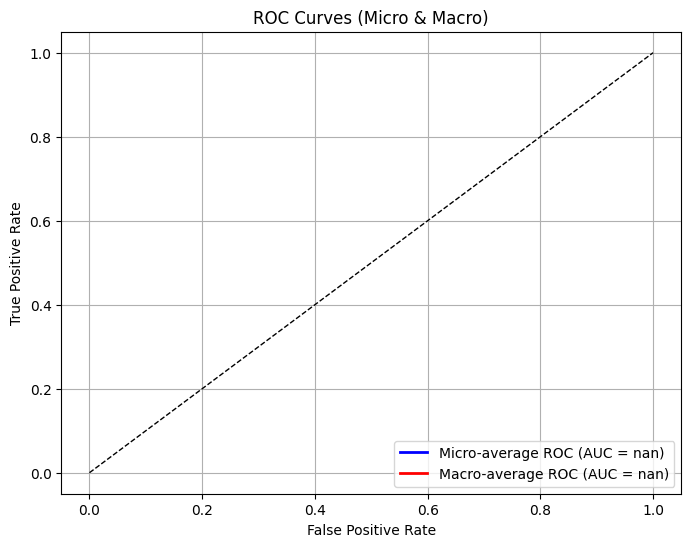

AUC Micro: nan
AUC Macro: nan


In [22]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Squash___Powdery_mildew", f"{sub_test_path}/Squash___Powdery_mildew")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 359
Classes: ['Strawberry___Leaf_scorch', 'Strawberry___healthy']
Classes: ['Strawberry___Leaf_scorch', 'Strawberry___healthy']
Indices: [33, 34]
Classification Report:

                          precision    recall  f1-score   support

Strawberry___Leaf_scorch       1.00      1.00      1.00       177
    Strawberry___healthy       1.00      1.00      1.00       182

                accuracy                           1.00       359
               macro avg       1.00      1.00      1.00       359
            weighted avg       1.00      1.00      1.00       359



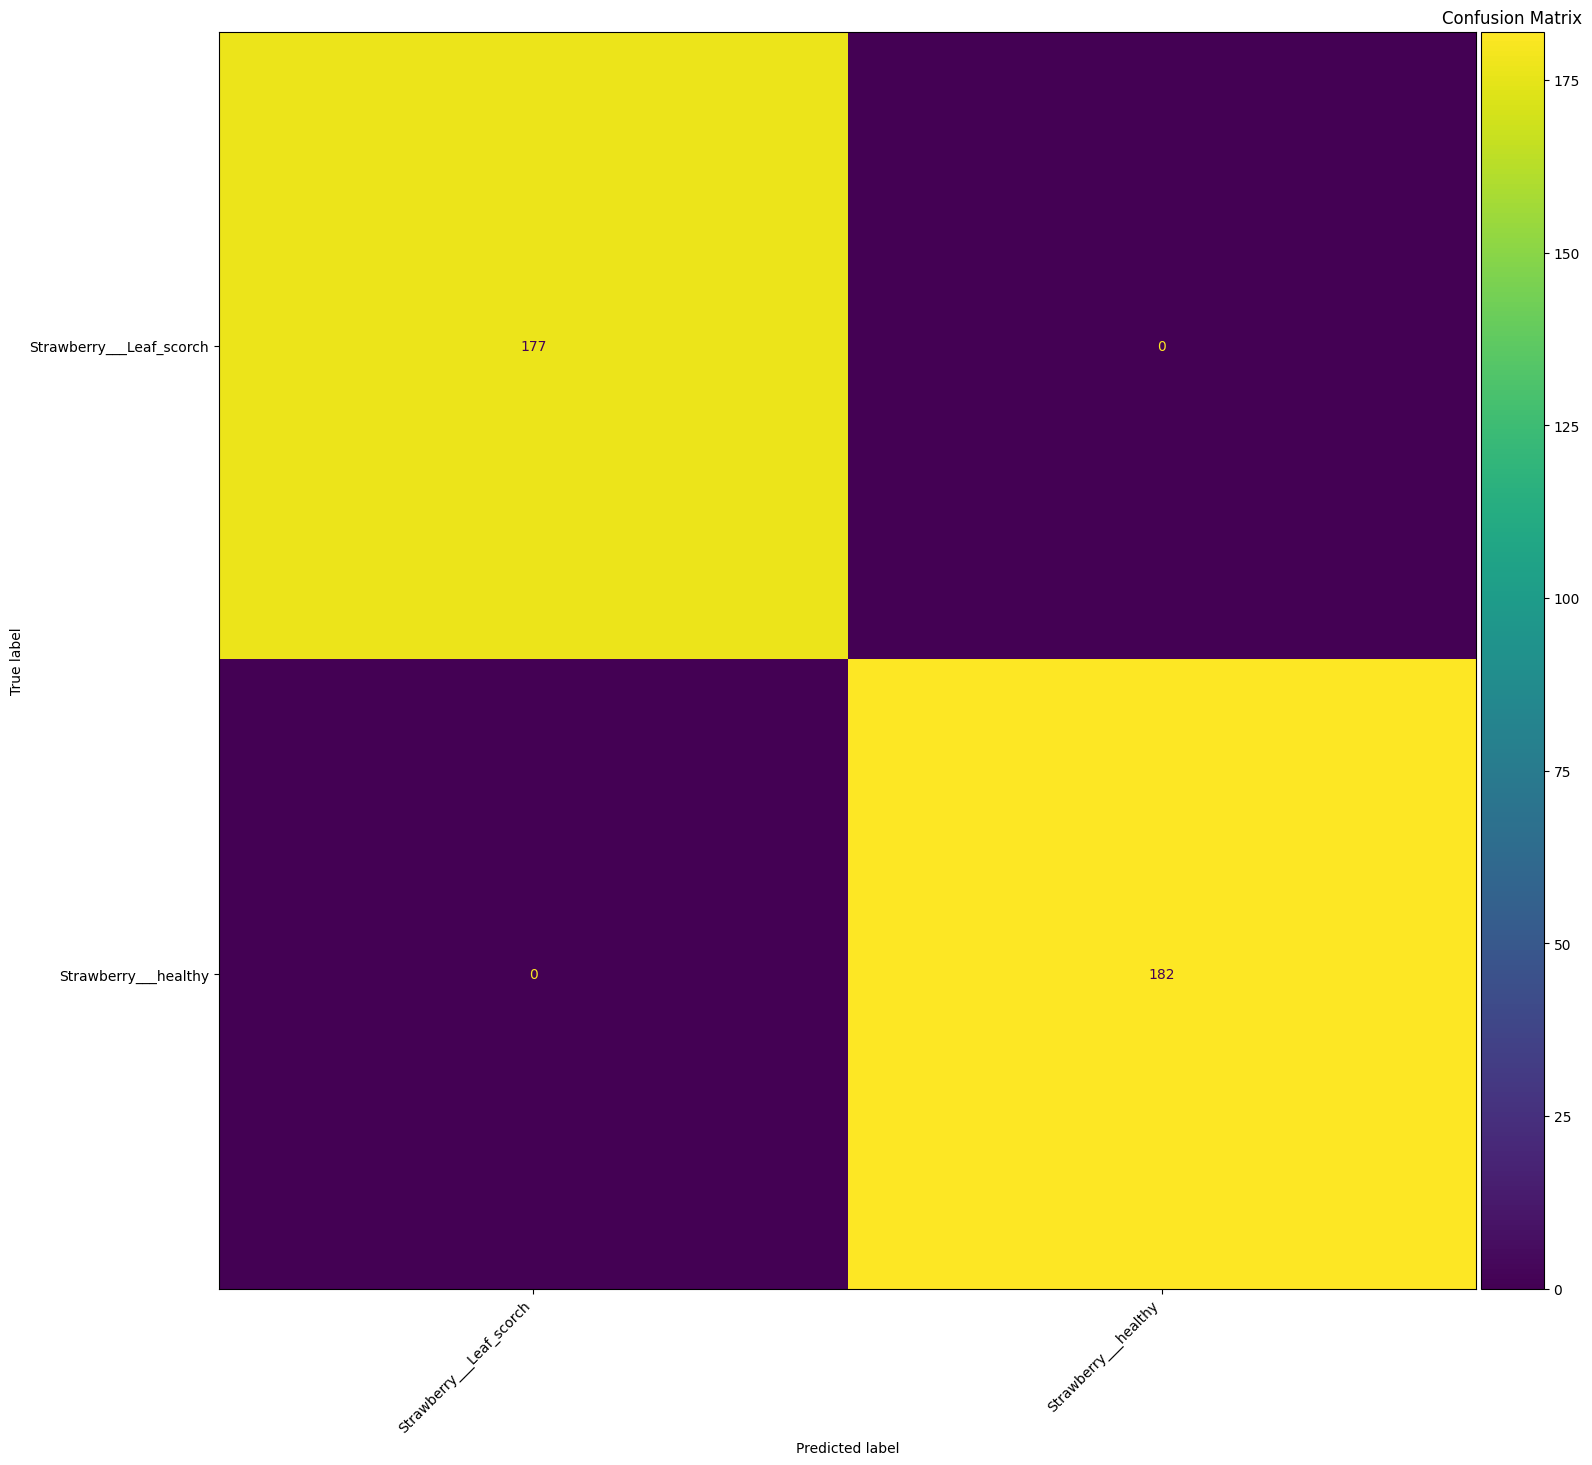

                      Class   TP  FP   TN  FN  Precision  Recall  F1-score  \
0  Strawberry___Leaf_scorch  177   0  182   0        1.0     1.0       1.0   
1      Strawberry___healthy  182   0  177   0        1.0     1.0       1.0   

   Accuracy  
0       1.0  
1       1.0  


ValueError: Found input variables with inconsistent numbers of samples: [359, 718]

In [23]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Strawberry___Leaf_scorch", f"{sub_test_path}/Strawberry___Leaf_scorch")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Strawberry___healthy", f"{sub_test_path}/Strawberry___healthy")

sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


Number of test samples: 1832
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Indices: [35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
Classification Report:

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      1.00      0.99       170
                        Tomato___Early_blight       0.99      1.00      1.00       192
                       

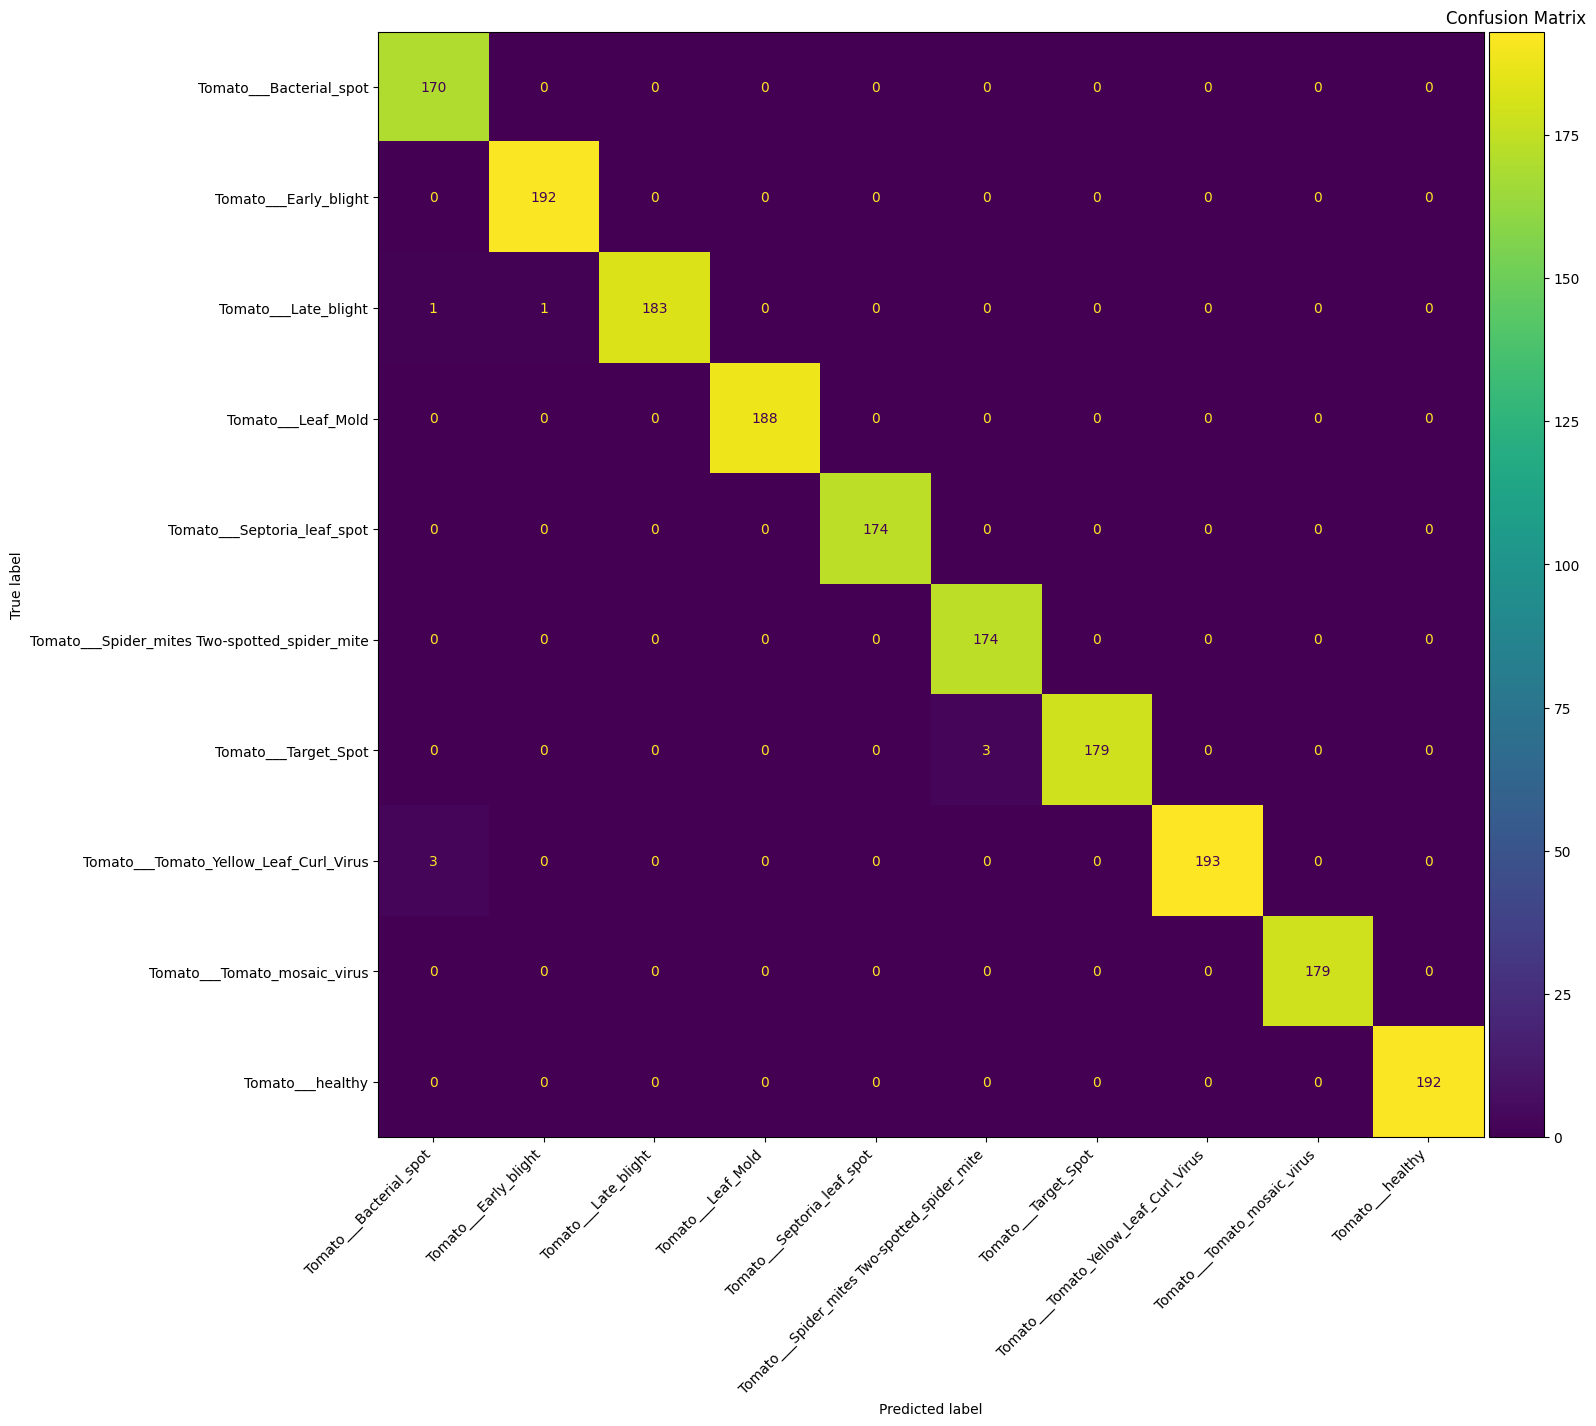

                                           Class   TP  FP    TN  FN  \
0                        Tomato___Bacterial_spot  170   4  1658   0   
1                          Tomato___Early_blight  192   1  1639   0   
2                           Tomato___Late_blight  183   0  1647   2   
3                             Tomato___Leaf_Mold  188   0  1644   0   
4                    Tomato___Septoria_leaf_spot  174   0  1658   0   
5  Tomato___Spider_mites Two-spotted_spider_mite  174   3  1655   0   
6                           Tomato___Target_Spot  179   0  1650   3   
7         Tomato___Tomato_Yellow_Leaf_Curl_Virus  193   0  1636   3   
8                   Tomato___Tomato_mosaic_virus  179   0  1653   0   
9                               Tomato___healthy  192   0  1640   0   

   Precision    Recall  F1-score  Accuracy  
0   0.977011  1.000000  0.988372  0.997817  
1   0.994819  1.000000  0.997403  0.999454  
2   1.000000  0.989189  0.994565  0.998908  
3   1.000000  1.000000  1.000000  1.00

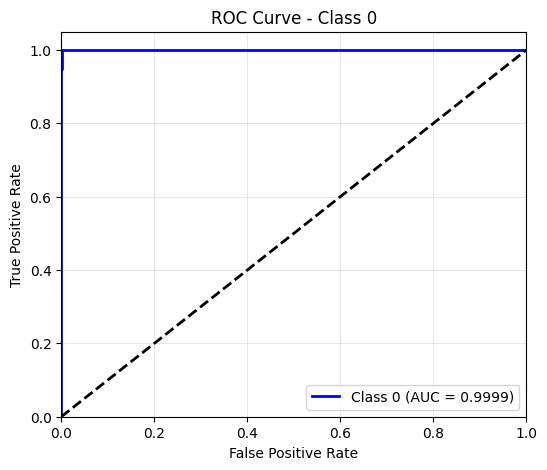

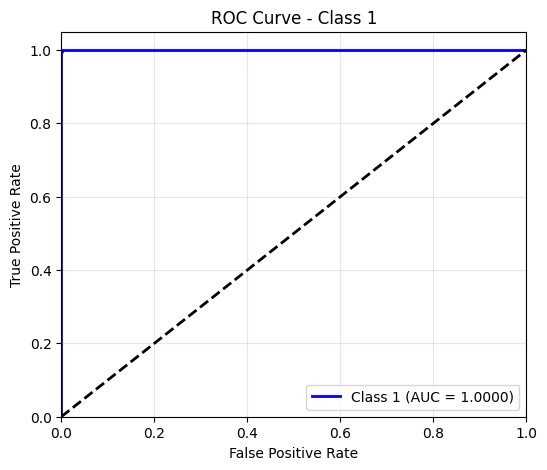

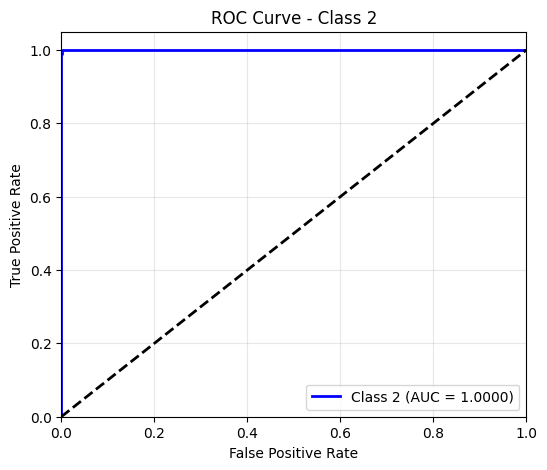

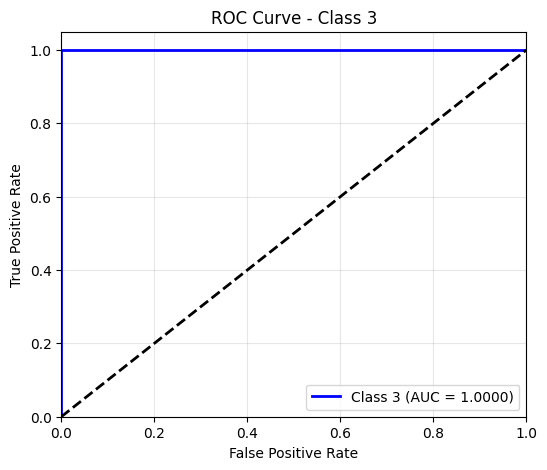

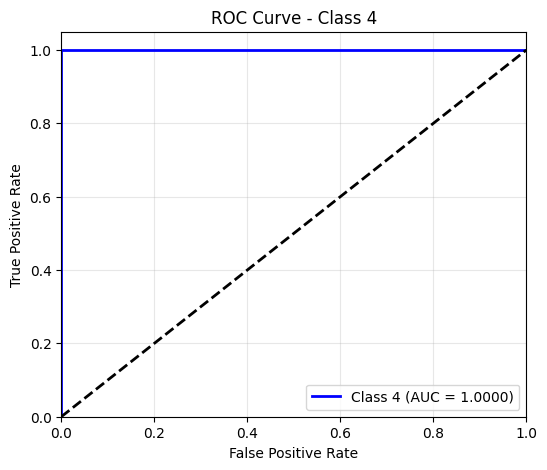

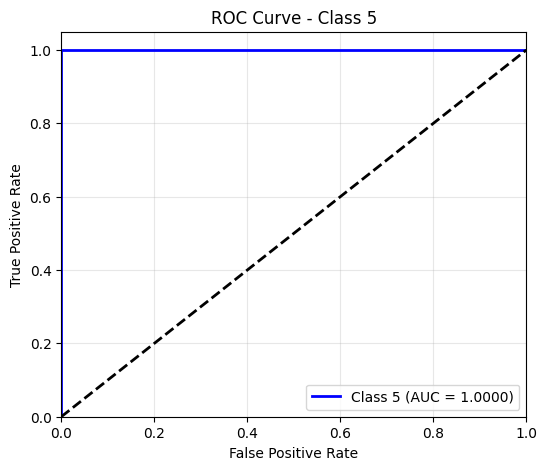

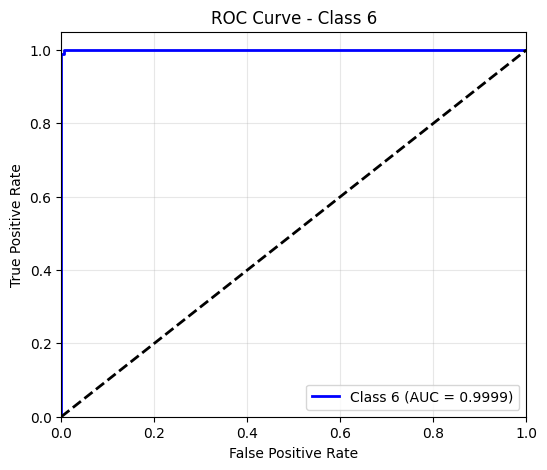

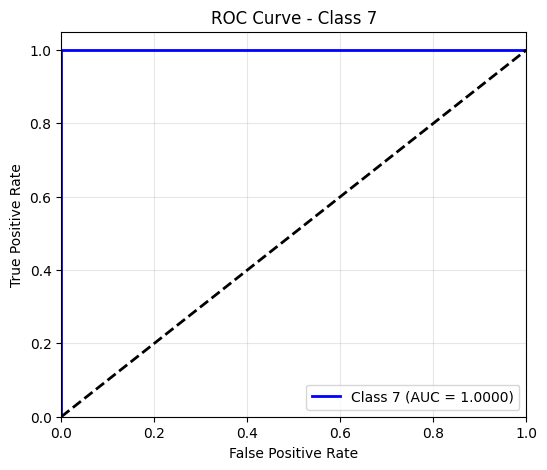

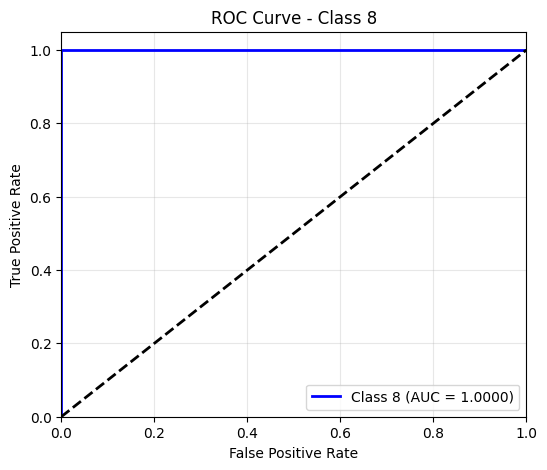

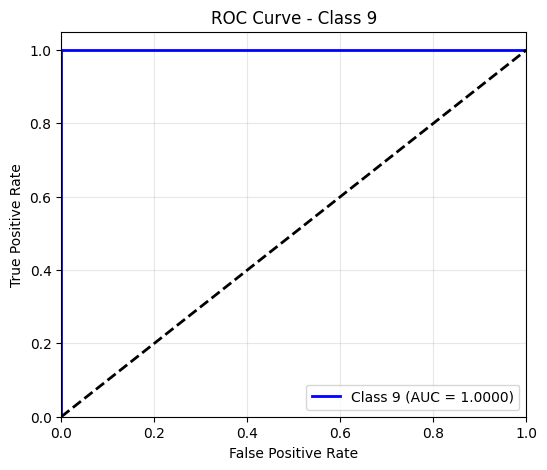

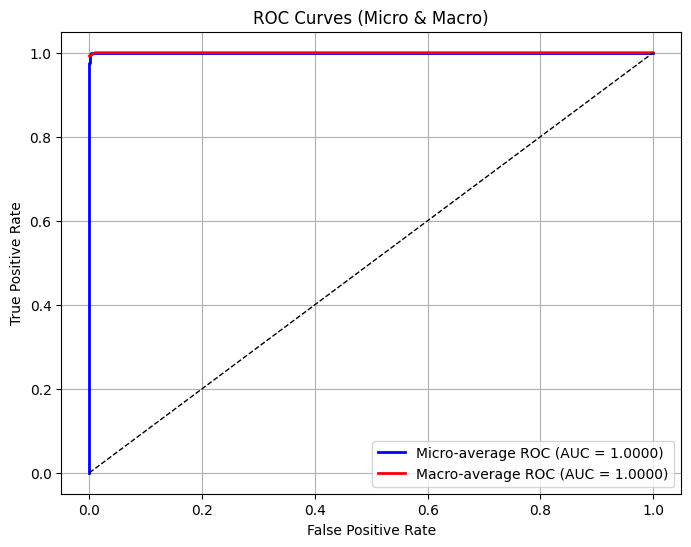

AUC Micro: 0.9999874859365764
AUC Macro: 0.9999596215496951


In [24]:
sub_test_path  = "/kaggle/working/sub_test_data"
if os.path.exists(sub_test_path):
    shutil.rmtree(sub_test_path) 
if not os.path.exists(sub_test_path): 
        os.makedirs(sub_test_path)
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Bacterial_spot", f"{sub_test_path}/Tomato___Bacterial_spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Early_blight", f"{sub_test_path}/Tomato___Early_blight")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Late_blight", f"{sub_test_path}/Tomato___Late_blight")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Leaf_Mold", f"{sub_test_path}/Tomato___Leaf_Mold")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Septoria_leaf_spot", f"{sub_test_path}/Tomato___Septoria_leaf_spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Spider_mites Two-spotted_spider_mite", f"{sub_test_path}/Tomato___Spider_mites Two-spotted_spider_mite")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Target_Spot", f"{sub_test_path}/Tomato___Target_Spot")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Tomato_Yellow_Leaf_Curl_Virus", f"{sub_test_path}/Tomato___Tomato_Yellow_Leaf_Curl_Virus")
        shutil.copytree("/kaggle/working/plant_fusion/test_data/Tomato___Tomato_mosaic_virus", f"{sub_test_path}/Tomato___Tomato_mosaic_virus")
        shutil.copytree("//kaggle/working/plant_fusion/test_data/Tomato___healthy", f"{sub_test_path}/Tomato___healthy")
    
sub_test_dataset = ImageFolder(f"{sub_test_path}", transform=val_transform)
print("Number of test samples:", len(sub_test_dataset))
print("Classes:", sub_test_dataset.classes)
test_loader = DataLoader(sub_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_model_plant(model, test_loader, test_classes, DEVICE)


In [1]:
!cp -r /kaggle/input/agrivitnet_2/pytorch/default/1/best_model_agrivitnet_on_new_plant_and_banana.pth /kaggle/working/